# Donor Behavioral Clustering — production refactor

This notebook fits the behavioral archetypes, scores lower-history repeat donors against the **frozen** fit, and then deliberately uses different populations for different questions.

### Population contract

| Purpose | Population |
|---|---|
| **Define cluster geometry** | Donors with `MIN_GIFTS_FIELD >= MIN_GIFTS` (currently 4+) |
| **Estimate persona prevalence / audience size** | Persona-eligible repeat donors: 4+ fit donors plus 2–3 gift donors who pass the repeat-evidence gate |
| **Describe personas / calculate JTBD profiles** | Donors whose `persona_status == "assigned"` |
| **Persona-level activation** | `persona_status == "assigned"`; tentative donors retain a best-fit cluster but are not treated as established persona members |
| **Aggregate business sizing** | All persona-eligible donors; assigned + tentative. Insufficient-repeat-evidence donors remain outside cluster-level sizing |

### Current persona-status policy

- **Insufficient repeat evidence:** 2–3 Green gifts, all current project gifts on one calendar day, and no observed evidence of earlier project giving → do not score.
- **4+ gifts:** assigned to the nearest cluster.
- **3 gifts:** assigned when `margin_ratio >= cluster fit P10` and `distance <= cluster fit P95`; otherwise tentative.
- **2 gifts:** assigned when `margin_ratio >= cluster fit P25` and `distance <= cluster fit P90`; otherwise tentative.

`insufficient_repeat_evidence` is an evidence-sufficiency state, not a confidence band. These donors have not been compared with persona centroids. `ASSIGNMENT_CONFIDENCE` therefore contains only donors who were actually scored.

`ASSIGNMENT_CONFIDENCE` contains only assignment geometry / measurement diagnostics. `persona_status` is a transparent arithmetic rule derived from those fields plus gift count; there is no separate qualitative confidence label.

The clustering geometry itself remains intentionally simple: standardize raw components, orient signs, average components equally within each behavioral unit, standardize units, apply explicit unit weights in squared-distance geometry, and run plain K-means.


## 1 — Imports


In [1]:
from __future__ import annotations

from html import escape
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 190)

print(f"pandas={pd.__version__} | numpy={np.__version__}")


pandas=2.3.2 | numpy=1.26.4


## 2 — Run parameters

These are the settings most likely to change between runs. Cluster names live here so downstream cells cannot silently drift to a different mapping.

**Important:** the semantic names are manual aliases for the current selected solution. If you materially change the fit population, features, unit weights, or K, inspect the resulting profiles before reusing the names.


In [2]:
# -----------------------------------------------------------------------------
# Data / population
# -----------------------------------------------------------------------------
DATA_DIR = Path("/Users/matt.fritz/Desktop/Behavioral Personas/Constructed Data2")
FEATURES_PATH = DATA_DIR / "clustering_features_20260801_w24m.csv"
DEMO_IF_FEATURE_FILE_MISSING = True

MIN_GIFTS = 4
MIN_GIFTS_FIELD = "n_gifts_green_24m"   # swap to n_gifts_24m for all project gifts
TOTAL_GIFTS_FIELD = "n_gifts_24m"
SCORE_MIN_GIFTS = 2
EXCLUDE_TEACHERS = False
SCORE_ALL_REPEAT = True

# Repeat-evidence eligibility
# If every observed project gift occurred on one calendar day and there is no
# evidence of earlier project giving, we do not yet have demonstrated repeat
# behavior to support persona typing.
# These donors are NOT centroid-scored. They remain a separate lifecycle state.
INSUFFICIENT_REPEAT_EVIDENCE_GIFT_COUNTS = {2, 3}

REPEAT_EVIDENCE_FIELDS = [
    "n_project_gift_days_24m",                  # distinct calendar days with project gifts
    "project_gift_span_days_24m",               # diagnostic only; not used by same-day rule
    "n_observed_project_gifts_before_window",   # project gifts observed before current 24m window
    "entry_donation_n",                         # catches older gifts truncated from the extract
]

# -----------------------------------------------------------------------------
# K-means
# -----------------------------------------------------------------------------
K_VALUES = [8]
SELECTED_K = 8
RANDOM_STATE = 20260825
N_INIT = 20
SILHOUETTE_SAMPLE_N = 5_000
STABILITY_RUNS = 10
STABILITY_SAMPLE_FRAC = 0.80

# Active optional units and their relative influence in squared-distance space.
ACTIVE_OPTIONAL_UNITS = ["trigger", "jtbd_local_stewardship", "platform_support", "choice_breadth"]
UNIT_WEIGHTS = {
    "jtbd_local_stewardship": 0.50,
    "platform_support": 0.25,
    "choice_breadth": 0.50,
}

# Manual names for the current canonical C1-C6 solution.
CLUSTER_LABELS = {
    1: "Steady Explorers",
    2: "Loyal Local Regulars",
    3: "Loyal Local Campaign Responders",
    4: "Sustained Project Finishers",
    5: "Focused Occasion Givers",
    6: "Distant Relationship Loyalists",
    7: "Episodic Project Finishers",
    8: "Campaign-Activated Explorers",
}

# -----------------------------------------------------------------------------
# Assignment / persona-status policy
# -----------------------------------------------------------------------------
# Thresholds are learned separately within each fit cluster.
# 4+ donors are always assigned because they define the fit population.
PERSONA_STATUS_RULES = {
    3: {"min_margin_quantile": 0.10, "max_distance_quantile": 0.95},
    2: {"min_margin_quantile": 0.25, "max_distance_quantile": 0.90},
}

# -----------------------------------------------------------------------------
# Coverage / profile display
# -----------------------------------------------------------------------------
PROJECT_COST_COVERAGE_FIELD = "coverage_project_cost_24m"
PROJECT_COST_COVERAGE_FLOOR = 0.50
PROFILE_TOP_N = 8
PROFILE_MIN_COVERAGE = 0.50

# -----------------------------------------------------------------------------
# JTBD interpretation
# -----------------------------------------------------------------------------
JTBD_TOP_N = 2
JTBD_MIN_JOB_COVERAGE = 0.55
JTBD_STANDOUT_MIN_INDEX = 1.25
JTBD_STANDOUT_MIN_EVIDENCE_Z = 0.20
JTBD_SHOW_TOP_PER_CLUSTER = 5

# -----------------------------------------------------------------------------
# Executive reporting
# -----------------------------------------------------------------------------
EXEC_INDEX_OVER = 1.20
EXEC_INDEX_UNDER = 0.80
EXEC_CATEGORY_MIN_OVERALL_SHARE = 0.02
EXEC_CATEGORY_MIN_COVERAGE = 0.75
EXEC_JOB_PAIR_MIN_OVERALL_SHARE = 0.015
EXEC_TOP_CATEGORY_N = 4
EXEC_BOTTOM_CATEGORY_N = 2
EXEC_TOP_JOB_PAIR_N = 3

# -----------------------------------------------------------------------------
# Business context
# -----------------------------------------------------------------------------
LARGE_DONOR_THRESHOLD = 10_000
TARGET_OPTIONAL_RATE = 0.15

if MIN_GIFTS != 4:
    raise ValueError(
        "The current persona-status policy is explicitly designed for a 4+ fit gate. "
        "Update PERSONA_STATUS_RULES before changing MIN_GIFTS."
    )
if SELECTED_K not in K_VALUES:
    raise ValueError("SELECTED_K must be present in K_VALUES.")
if set(CLUSTER_LABELS) != set(range(1, SELECTED_K + 1)):
    raise ValueError("CLUSTER_LABELS must define exactly one name for every selected cluster.")


## 3 — Analytical definitions

This section contains feature specifications rather than run-time tuning. Within a clustering unit, component weights are intentionally equal; the `+1/-1` values below only orient direction.


In [3]:
CORE_UNITS = {
    "relationship_loyalty": {
        "share_gifts_repeat_teacher_24m": +1,
        "entropy_school_norm_24m": -1,
    },
    "giving_rhythm": {
        "entropy_gift_month_norm_24m": +1,
        "gifts_per_active_month_24m": -1,
    },
    "giving_approach": {
        "modal_amount_share_24m": +1,
        "share_gifts_round_amount_24m": +1,
        "median_gift_to_project_cost_ratio_24m": -1,
        "share_gifts_closed_project_24m": -1,
        "share_gifts_first_money_in_24m": +1,
    },
}

OPTIONAL_UNIT_LIBRARY = {
    "campaign_responsiveness": {
        "share_gifts_with_match_24m": +1,
        "share_gifts_big_event_24m": +1,
    },
    "choice_breadth": {
        "top_category_share_count_24m": -1,
    },
    "seasonality": {
        "top_month_share_24m": +1,
        "share_gifts_q4_24m": +1,
    },
    "trigger": {
        "share_gifts_with_match_24m": +1,
        "share_gifts_big_event_24m": +1,
    },
    "funding_depth": {
        "share_gifts_over_half_project_cost_24m": +1,
        "share_gifts_full_project_cost_24m": +1,
    },
    "jtbd_decision_deliberation": {
        "share_gifts_with_prior_search_24m": +1,
        "project_page_pre_gift_mean_24m": +1,
    },
    "jtbd_giving_leverage": {
        "share_gifts_with_match_24m": +1,
        "mean_match_excess_24m": +1,
    },
    "jtbd_sustained_monthly": {
        "is_monthly_donor_current": +1,
        "monthly_longest_streak_months": +1,
    },
    "jtbd_tax_efficiency": {"share_gifts_daf_24m": +1},
    "jtbd_active_participation": {
        "sharing_events_24m": +1,
        "sharing_active_months_24m": +1,
    },
    "jtbd_local_stewardship": {
        "share_gifts_within_15mi_24m": +1,
        #"median_distance_mi_24m": -1,
    },
    "jtbd_recognition_avoidance": {"share_gifts_anonymous_24m": +1},
    "jtbd_values_equity": {
        "share_gifts_to_low_income_schools_24m": +1,
        "share_gifts_to_historically_underrepresented_race_schools_24m": +1,
    },
    "site_engagement": {
        "days_with_site_activity_24m": +1,
        "search_visits_day_total_24m": +1,
    },
    "platform_support": {
        "avg_optional_donation_rate_24m": +1,
        "share_gifts_with_optional_donation_24m": +1,
    },
}

LOG1P_FIELDS = {
    "gifts_per_active_month_24m",
    "median_gift_to_project_cost_ratio_24m",
    "project_page_pre_gift_mean_24m",
    "mean_match_excess_24m",
    "sharing_events_24m",
    "monthly_longest_streak_months",
    "days_with_site_activity_24m",
    "search_visits_day_total_24m",
}

PROJECT_COST_FIELDS = {
    "median_gift_to_project_cost_ratio_24m",
    "share_gifts_over_half_project_cost_24m",
    "share_gifts_full_project_cost_24m",
}

PROFILE_FIELDS = [
    "n_gifts_24m", "n_gifts_green_24m", "gift_amount_24m", "median_gift_amount_24m",
    "lifetime_amount", "lifetime_gift_count", "is_major_gift_donor",
    "n_active_months_24m", "days_since_last_gift", "tenure_days",
    "is_new_donor_24m", "is_reactivated_24m", "is_continuing_donor_24m",
    "is_monthly_donor_current", "monthly_active_months_24m",
    "monthly_longest_streak_months", "share_amount_monthly_24m",
    "share_gifts_year_end_final_week_24m", "share_gifts_giving_tuesday_window_24m",
    "share_gifts_back_to_school_24m", "share_gifts_summer_24m", "share_gifts_q4_24m",
    "top_month_share_24m", "share_gifts_with_match_24m", "mean_match_excess_24m",
    "share_gifts_big_event_24m", "share_gifts_classroom_essentials_24m",
    "entropy_category_norm_24m", "n_unique_categories_24m", "top_category_share_count_24m",
    "n_unique_schools_24m", "share_gifts_repeat_school_24m",
    "median_project_total_cost_24m", "share_gifts_over_half_project_cost_24m",
    "share_gifts_full_project_cost_24m", "median_distance_mi_24m",
    "share_gifts_within_15mi_24m", "share_gifts_to_low_income_schools_24m",
    "share_gifts_to_historically_underrepresented_race_schools_24m",
    "share_gifts_to_underserved_rural_schools_24m", "is_teacher", "is_teacher_referred",
    "is_marketing_subscribed", "email_open_rate_24m", "email_click_rate_24m",
    "days_with_site_activity_24m", "n_site_visits_24m", "search_visits_day_total_24m",
    "sharing_events_24m", "sharing_active_months_24m", "share_gifts_daf_24m",
    "share_gifts_anonymous_24m", "share_gifts_green_24m",
    "avg_optional_donation_rate_24m", "share_gifts_with_optional_donation_24m",
]

# Eight stable signals used to check whether the confidence-gated profile base
# changes the persona fingerprint relative to fit-only and all-repeat bases.
PROFILE_COMPARISON_SPECS = [
    ("Repeat-teacher gift share", "share_gifts_repeat_teacher_24m", "mean"),
    ("Giving-month entropy", "entropy_gift_month_norm_24m", "mean"),
    ("Gifts per active month", "gifts_per_active_month_24m", "median"),
    ("Modal-amount gift share", "modal_amount_share_24m", "mean"),
    ("Median gift / project-cost ratio", "median_gift_to_project_cost_ratio_24m", "median"),
    ("Gifts within 15 miles", "share_gifts_within_15mi_24m", "mean"),
    ("Top-category gift share", "top_category_share_count_24m", "mean"),
    ("Matched-gift share", "share_gifts_with_match_24m", "mean"),
]


In [4]:
JTBD_JOB_SPECS = {

    # ------------------------------------------------------------------------
    # FUNCTIONAL
    # ------------------------------------------------------------------------

    "Concrete impact": {
        "definition": "Produce a tangible, understandable result",
        "rankable": True,
        "min_components": 2,
        "features": {
            # Keep only one direct funding-depth measure so this does not
            # simply become "large giver."
            "median_gift_to_project_cost_ratio_24m": +0.75,

            # Different manifestation: finishing a concrete project need.
            "share_gifts_closed_project_24m": +1.00,

            # Tangible item/list giving; useful but product-opportunity dependent.
            "share_gifts_classroom_essentials_24m": +0.50,
        },
    },

    "Directed choice": {
        "definition": "Understand the specific project or destination my gift will support",
        "rankable": True,
        "min_components": 2,
        "features": {
            "share_gifts_with_prior_search_24m": +1.00,
            "project_page_pre_gift_mean_24m": +1.00,
        },
    },

    "Giving leverage": {
        "definition": "Make my contribution accomplish more by unlocking additional funds",
        "rankable": True,
        "min_components": 2,
        "features": {
            "share_gifts_with_match_24m": +1.00,
            "mean_match_excess_24m": +1.00,
        },
    },

    "Tax efficiency": {
        "definition": "Leverage charitable tax deductions for my financial benefit",

        # Useful directional evidence, but not strong enough to compete
        # against better-observed Jobs for a donor's Top-2 slots.
        "rankable": False,
        "min_components": 2,
        "features": {
            "share_gifts_daf_24m": +2.00,
            "share_gifts_year_end_final_week_24m": +1.00,
            "share_gifts_q4_24m": +0.50,
        },
    },

    "Sustained giving": {
        "definition": "Make generosity a dependable practice",
        "rankable": True,
        "min_components": 3,
        "features": {
            # Recent consistency.
            "n_active_months_24m": +1.00,
            "entropy_gift_month_norm_24m": +1.00,

            # Persistence across windows.
            "is_continuing_donor_24m": +1.00,

            # Length of overall giving relationship.
            "tenure_days_any_giving": +0.75,

            # Only one explicitly monthly-specific measure.
            "monthly_longest_streak_months": +0.50,
        },
    },

    "Confidence and risk reduction": {
        "definition": "Avoid an unsafe, ineffective, or regrettable giving decision",
        "rankable": True,
        "min_components": 2,
        "features": {
            # Repeated school support as an observed trust/persistence signal.
            "share_gifts_repeat_school_24m": +1.00,

            # Research / deliberation.
            "share_gifts_with_prior_search_24m": +0.75,
            "teacher_page_pre_gift_mean_24m": +0.50,
        },
    },

    # ------------------------------------------------------------------------
    # SOCIAL
    # ------------------------------------------------------------------------

    "Relational support": {
        "definition": "Show up for someone I care about",
        "rankable": True,
        "min_components": 2,
        "features": {
            "share_gifts_repeat_teacher_24m": +1.00,
            "top_teacher_share_count_24m": +1.00,
            "gifts_per_teacher_24m": +0.75,

            # Relationship-origin context, weaker than observed repeated support.
            "is_teacher_referred": +0.50,
        },
    },

    "Local stewardship": {
        "definition": "Strengthen the community where I live",
        "rankable": True,
        "min_components": 2,
        "features": {
            "share_gifts_within_15mi_24m": +1.00,
            "median_distance_mi_24m": -1.00,
        },
    },

    "Collective participation": {
        "definition": "Join others I trust in supporting something together",

        # We can see some relevant behavior, but sharing/referral evidence is
        # currently too sparse/contextual to compete for Top-2 slots.
        "rankable": False,
        "min_components": 2,
        "features": {
            "sharing_active_months_24m": +1.00,
            "share_gifts_channel_sharetray_24m": +1.00,
            "share_gifts_channel_facebook_24m": +0.50,
            "share_gifts_channel_nextdoor_24m": +0.50,
        },
    },

    # ------------------------------------------------------------------------
    # EMOTIONAL / CROSS-CUTTING
    # ------------------------------------------------------------------------

    "Urgent action": {
        "definition": "Act when a need becomes urgent and emotionally real",
        "rankable": True,
        "min_components": 2,
        "features": {
            # Direct project urgency.
            "days_gift_to_expiration_median_24m": -1.00,
            "share_gifts_expiring_soon_24m": +1.00,

            # Supporting late-cycle evidence.
            "share_gifts_late_cycle_24m": +0.50,

            # Separate manifestation: speed of action after encountering need.
            "share_gifts_same_day_first_session_24m": +0.50,
            "days_first_session_to_gift_median_24m": -0.50,
        },
    },

    "Values obligation": {
        "definition": "Feel true to my personal values by giving",
        "rankable": True,
        "min_components": 2,
        "features": {
            # Specifically equity-oriented behavioral expressions of Values.
            "share_gifts_to_low_income_schools_24m": +1.00,
            "share_gifts_to_historically_underrepresented_race_schools_24m": +1.00,
            "share_gifts_to_underserved_rural_schools_24m": +1.00,
        },
    },
}

JTBD_NOT_RANKED = {

    "Impact witness":
        "No clean post-gift sequence showing that the donor actually follows "
        "the work or consumes evidence of progress.",

    "Active participation":
        "Current first-party data do not directly observe taking part in the "
        "work beyond giving money. Sharing is treated as Collective "
        "Participation instead.",

    "Acknowledged contribution":
        "Anonymous giving is a narrow inverse proxy, but is not enough to "
        "support a multi-signal behavioral score for desire for recognition.",

    "Faith obligation":
        "No defensible behavioral signal in the current first-party feature build.",
}

EXEC_REQUESTED_FIELDS = {
    # Value / economics
    "gift_amount_24m", "gift_amount_12m", "gift_amount_prev24m", "gift_amount_prev12m",
    "grand_amount_24m", "grand_amount_12m", "monthly_amount_24m", "monthly_amount_12m",
    "mean_gift_amount_24m", "mean_gift_amount_12m",
    "median_gift_amount_24m", "median_gift_amount_12m",
    "max_gift_amount_24m", "max_gift_amount_12m",
    "lifetime_amount", "lifetime_gift_count", "lifetime_max_gift_amount",
    "is_major_gift_donor",

    # Lifecycle / cadence
    "n_gifts_24m", "n_gifts_12m", "n_gifts_prev24m", "n_gifts_prev12m",
    "n_active_months_24m", "n_active_months_12m",
    "days_since_last_gift", "tenure_days", "tenure_days_any_giving",
    "is_new_donor_24m", "is_new_donor_12m",
    "is_reactivated_24m", "is_reactivated_12m",
    "is_continuing_donor_24m", "is_continuing_donor_12m",
    "is_monthly_donor_current",
    "monthly_active_months_24m", "monthly_active_months_12m",
    "monthly_longest_streak_months",
    "monthly_median_payment_amount_24m", "monthly_median_payment_amount_12m",
    "share_amount_monthly_24m", "share_amount_monthly_12m",
    "n_recurring_donation_ids", "months_since_first_monthly_join",

    # Site / product / decision journey
    "has_site_data_24m", "has_site_data_12m", "site_unit_is_session",
    "days_with_site_activity_24m", "days_with_site_activity_12m",
    "n_site_visits_24m", "n_site_visits_12m",
    "site_rows_24m", "site_rows_12m",
    "site_visits_per_active_day_24m", "site_visits_per_active_day_12m",
    "share_project_page_visits_24m", "share_project_page_visits_12m",
    "project_page_visits_day_total_24m", "project_page_visits_day_total_12m",
    "share_teacher_page_visits_24m", "share_teacher_page_visits_12m",
    "teacher_page_visits_day_total_24m", "teacher_page_visits_day_total_12m",
    "share_search_visits_24m", "share_search_visits_12m",
    "search_visits_day_total_24m", "search_visits_day_total_12m",
    "page_visits_per_active_day_24m", "page_visits_per_active_day_12m",
    "cart_visits_24m", "cart_visits_12m",
    "campaign_visit_share_24m", "campaign_visit_share_12m",
    "days_since_last_cart_visit",
    "project_page_pre_gift_mean_24m", "project_page_pre_gift_mean_12m",
    "teacher_page_pre_gift_mean_24m", "teacher_page_pre_gift_mean_12m",
    "search_pre_gift_mean_24m", "search_pre_gift_mean_12m",
    "cart_pre_gift_mean_24m", "cart_pre_gift_mean_12m",
    "site_days_pre_gift_mean_24m", "site_days_pre_gift_mean_12m",
    "share_gifts_with_prior_search_24m", "share_gifts_with_prior_search_12m",
    "share_gifts_same_day_first_session_24m", "share_gifts_same_day_first_session_12m",
    "days_first_session_to_gift_median_24m", "days_first_session_to_gift_median_12m",
    "decision_speed_measurable_24m", "decision_speed_measurable_12m",

    # Optional tip / platform support
    "avg_optional_donation_rate_24m", "avg_optional_donation_rate_12m",
    "share_gifts_with_optional_donation_24m", "share_gifts_with_optional_donation_12m",

    # Choice / need / category / geography
    "n_unique_categories_24m", "n_unique_categories_12m",
    "entropy_category_norm_24m", "entropy_category_norm_12m",
    "top_category_share_count_24m", "top_category_share_count_12m",
    "share_gifts_classroom_essentials_24m", "share_gifts_classroom_essentials_12m",
    "share_amount_classroom_essentials_24m", "share_amount_classroom_essentials_12m",
    "share_gifts_to_low_income_schools_24m", "share_gifts_to_low_income_schools_12m",
    "share_gifts_to_historically_underrepresented_race_schools_24m",
    "share_gifts_to_historically_underrepresented_race_schools_12m",
    "share_gifts_to_underserved_rural_schools_24m", "share_gifts_to_underserved_rural_schools_12m",
    "share_gifts_with_match_24m", "share_gifts_with_match_12m",
    "mean_match_excess_24m", "mean_match_excess_12m",
    "share_amount_with_match_24m", "share_amount_with_match_12m",
    "share_gifts_over_half_project_cost_24m", "share_gifts_over_half_project_cost_12m",
    "share_gifts_full_project_cost_24m", "share_gifts_full_project_cost_12m",
    "median_gift_to_project_cost_ratio_24m", "median_gift_to_project_cost_ratio_12m",
    "median_distance_mi_24m", "median_distance_mi_12m",
    "share_gifts_within_15mi_24m", "share_gifts_within_15mi_12m",
    "share_gifts_same_state_24m", "share_gifts_same_state_12m",

    # Context useful to CMO / CTO
    "is_teacher", "is_teacher_referred", "is_marketing_subscribed",
    "email_open_rate_24m", "email_open_rate_12m",
    "email_click_rate_24m", "email_click_rate_12m",
}

BUSINESS_REQUEST_FIELDS = {
    "grand_amount_24m", "grand_amount_12m", "gift_amount_24m", "gift_amount_12m",
    "share_gifts_daf_24m", "share_gifts_daf_12m",
    "avg_optional_donation_rate_24m", "avg_optional_donation_rate_12m",
    "green_revenue_24m", "green_revenue_12m", "gift_amount_green_24m", "gift_amount_green_12m",
    "green_amount_24m", "green_amount_12m", "share_amount_green_optin_24m",
    "share_amount_green_optin_12m", "share_amount_green_24m", "share_amount_green_12m",
}


## 4 — Shared helpers

The fit and scoring paths intentionally call the **same transformation functions**. This removes the largest regression risk in the earlier notebook: parallel preprocessing logic that could drift over time.


In [5]:
def flatten_unit_features(units):
    return [feature for spec in units.values() for feature in spec]


def active_units(optional_units=None):
    optional_units = ACTIVE_OPTIONAL_UNITS if optional_units is None else list(optional_units)
    units = {name: dict(spec) for name, spec in CORE_UNITS.items()}

    for name in optional_units:
        if name not in OPTIONAL_UNIT_LIBRARY:
            raise ValueError(f"Unknown optional unit: {name}")
        units[name] = dict(OPTIONAL_UNIT_LIBRARY[name])

    feature_owner = {}
    duplicates = {}
    for unit, spec in units.items():
        for feature in spec:
            if feature in feature_owner:
                duplicates.setdefault(feature, [feature_owner[feature]]).append(unit)
            else:
                feature_owner[feature] = unit

    if duplicates:
        detail = "; ".join(f"{f}: {owners}" for f, owners in duplicates.items())
        raise ValueError(f"Active units reuse a raw feature: {detail}")
    return units


def all_library_features():
    fields = set(flatten_unit_features(CORE_UNITS))
    for spec in OPTIONAL_UNIT_LIBRARY.values():
        fields.update(spec)
    return sorted(fields)


def all_jtbd_features():
    return sorted({f for spec in JTBD_JOB_SPECS.values() for f in spec["features"]})


def dynamic_feature_requested(column):
    c = column.lower()
    return (
        column.startswith("share_count_category_")
        or column.startswith("share_amount_category_")
        or "session_duration" in c
        or ("duration" in c and ("session" in c or "visit" in c))
        or ("unique" in c and "project" in c and ("session" in c or "visit" in c))
        or "ltv" in c
        or "retention" in c
        or "retained" in c
        or "next_gift" in c
        or ("optional" in c and ("amount" in c or "dollar" in c))
    )


def requested_static_fields(units):
    controls = {
        "donor_id", "cluster_eligible", MIN_GIFTS_FIELD, TOTAL_GIFTS_FIELD,
        "is_teacher", PROJECT_COST_COVERAGE_FIELD,
        *REPEAT_EVIDENCE_FIELDS,
    }
    return sorted(
        controls
        | set(flatten_unit_features(units))
        | set(all_library_features())
        | set(PROFILE_FIELDS)
        | set(all_jtbd_features())
        | set(EXEC_REQUESTED_FIELDS)
        | set(BUSINESS_REQUEST_FIELDS)
    )

def insufficient_repeat_evidence_mask(df):
    """
    Identify lower-history donors who have multiple transactions but only one
    observed giving occasion.

    A donor is held out from persona scoring when:
      1. they have exactly 2 or 3 Green gifts in the current window;
      2. every current-window project gift occurred on one calendar day;
      3. no project gifts are observed before the current window; and
      4. entry_donation_n gives no evidence of older gifts outside the extract.

    This is an eligibility rule, not a clustering feature or confidence score.
    """

    required = {
        MIN_GIFTS_FIELD,
        "n_project_gift_days_24m",
        "n_observed_project_gifts_before_window",
        "entry_donation_n",
    }

    missing = sorted(required - set(df.columns))
    if missing:
        raise KeyError(
            "Repeat-evidence gate cannot run; missing fields:\n  - "
            + "\n  - ".join(missing)
        )

    green_gifts = pd.to_numeric(
        df[MIN_GIFTS_FIELD],
        errors="coerce",
    )

    project_gift_days = pd.to_numeric(
        df["n_project_gift_days_24m"],
        errors="coerce",
    )

    prior_project_gifts = pd.to_numeric(
        df["n_observed_project_gifts_before_window"],
        errors="coerce",
    )

    entry_donation_n = pd.to_numeric(
        df["entry_donation_n"],
        errors="coerce",
    )

    low_history = green_gifts.isin(
        INSUFFICIENT_REPEAT_EVIDENCE_GIFT_COUNTS
    )

    # One distinct project-gift date means that multiple transactions still
    # represent only one observed giving occasion.
    single_giving_day = project_gift_days.eq(1)

    # No project gifts are visible before the current analysis window.
    no_observed_prior_history = prior_project_gifts.fillna(0).eq(0)

    # entry_donation_n > 1 proves that older project gifts existed even if the
    # extract cannot see them. Missing values provide no contradictory evidence,
    # matching the rule used in the validated sensitivity analysis.
    no_known_preextract_history = (
        entry_donation_n.isna()
        | entry_donation_n.le(1)
    )

    return (
        low_history
        & single_giving_day
        & no_observed_prior_history
        & no_known_preextract_history
    )

def first_available(df, *names):
    return next((name for name in names if name in df.columns), None)


def aggregate_numeric(series, method):
    x = pd.to_numeric(series, errors="coerce").dropna()
    if x.empty:
        return np.nan
    if method == "mean":
        return float(x.mean())
    if method == "median":
        return float(x.median())
    if method == "sum":
        return float(x.sum())
    raise ValueError(f"Unknown aggregation: {method}")


def safe_ratio_index(value, overall):
    if pd.isna(value) or pd.isna(overall) or overall <= 0 or value < 0:
        return np.nan
    return float(value / overall)


def is_rate_like(field, series):
    name = field.lower()
    observed = pd.to_numeric(series, errors="coerce").dropna()
    bounded = len(observed) and observed.min() >= -1e-9 and observed.max() <= 1.000001
    return name.startswith(("share_", "is_", "has_")) or "_rate" in name or bounded


def raw_summary(field, series):
    x = pd.to_numeric(series, errors="coerce").dropna()
    if x.empty:
        return np.nan, "mean"
    if is_rate_like(field, x):
        return float(x.mean()), "mean"
    return float(x.median()), "median"


def format_raw(field, value, reference_series):
    if pd.isna(value):
        return "-"
    name = field.lower()
    if is_rate_like(field, reference_series):
        return f"{value:.0%}"
    if "amount" in name and "share_" not in name and "rate" not in name and "ratio" not in name:
        return f"${value:,.0f}"
    if "ratio" in name:
        return f"{value:.2f}x"
    if any(t in name for t in ["days", "months", "count", "n_unique", "n_gifts", "visits", "events"]):
        return f"{value:,.1f}"
    return f"{value:,.2f}"


In [6]:
def make_demo_data(fields, n=4_000, seed=RANDOM_STATE):
    """Synthetic smoke-test data only. Never interpret these outputs as donor results."""
    rng = np.random.default_rng(seed)
    latent = rng.integers(0, SELECTED_K, size=n)

    green_count = rng.choice(
        [2, 3, 4, 5, 6, 8, 10, 12],
        size=n,
        p=[0.24, 0.16, 0.16, 0.12, 0.10, 0.09, 0.07, 0.06],
    )
    total_count = green_count + rng.integers(0, 4, size=n)

    data = {
        "donor_id": [f"demo_{i:06d}" for i in range(n)],
        "cluster_eligible": np.ones(n, dtype=int),
        MIN_GIFTS_FIELD: green_count,
        TOTAL_GIFTS_FIELD: total_count,
        "is_teacher": (rng.random(n) < 0.12).astype(float),
        PROJECT_COST_COVERAGE_FIELD: np.clip(rng.normal(0.90, 0.10, n), 0, 1),
    }

    z = (latent - latent.mean()) / max(latent.std(), 1e-9)
    data.update({
        "share_gifts_repeat_teacher_24m": np.clip(0.55 + 0.14*z + rng.normal(0, 0.12, n), 0, 1),
        "entropy_school_norm_24m": np.clip(0.55 - 0.14*z + rng.normal(0, 0.12, n), 0, 1),
    })
    rhythm = rng.normal(size=n) + 0.30 * ((latent % 3) - 1)
    data.update({
        "entropy_gift_month_norm_24m": np.clip(0.55 + 0.18*rhythm + rng.normal(0, 0.10, n), 0, 1),
        "gifts_per_active_month_24m": np.clip(2.7 - 0.70*rhythm + rng.normal(0, 0.35, n), 1, 8),
    })
    approach = rng.normal(size=n) + 0.30 * ((latent // 2) - 1)
    data.update({
        "modal_amount_share_24m": np.clip(0.55 + 0.18*approach + rng.normal(0, 0.10, n), 0, 1),
        "share_gifts_round_amount_24m": np.clip(0.55 + 0.16*approach + rng.normal(0, 0.10, n), 0, 1),
        "median_gift_to_project_cost_ratio_24m": np.exp(-2.0 - 0.50*approach + rng.normal(0, 0.35, n)),
        "share_gifts_closed_project_24m": np.clip(0.30 - 0.15*approach + rng.normal(0, 0.12, n), 0, 1),
        "share_gifts_first_money_in_24m": np.clip(0.45 + 0.14*approach + rng.normal(0, 0.12, n), 0, 1),
        "share_gifts_with_match_24m": np.clip(0.25 + 0.08*(latent == 4) + rng.normal(0, 0.10, n), 0, 1),
        "share_gifts_big_event_24m": np.clip(0.20 + 0.10*(latent == 4) + rng.normal(0, 0.08, n), 0, 1),
        "share_gifts_within_15mi_24m": np.clip(0.45 + 0.25*(latent == 1) + rng.normal(0, 0.15, n), 0, 1),
        "median_distance_mi_24m": np.exp(3.2 - 1.0*(latent == 1) + rng.normal(0, 0.8, n)),
        "top_category_share_count_24m": np.clip(0.45 + 0.12*(latent == 2) + rng.normal(0, 0.12, n), 0, 1),
    })

    for field in fields:
        if field in data or field == "donor_id":
            continue
        name = field.lower()
        if field == "site_unit_is_session":
            data[field] = np.ones(n)
        elif name.startswith(("is_", "has_")) or name.startswith("next_gift_"):
            data[field] = (rng.random(n) < 0.35).astype(float)
        elif name.startswith(("share_", "entropy_")) or "_rate" in name or "coverage_" in name:
            data[field] = rng.beta(2, 4, n)
        elif any(token in name for token in ["amount", "revenue", "ltv"]) and not name.startswith("share_"):
            data[field] = np.exp(rng.normal(6.0, 1.4, n))
        elif "ratio" in name or "match_excess" in name:
            data[field] = np.exp(rng.normal(-1.2, 0.7, n))
        elif any(token in name for token in ["days", "months", "count", "n_unique", "visits", "events", "rows", "streak"]):
            data[field] = np.maximum(0, np.rint(np.exp(rng.normal(1.6, 0.7, n))))
        else:
            data[field] = rng.normal(0, 1, n)

    # A few coherent business fields so every optional business cell can smoke-test.
    project_revenue = np.exp(rng.normal(6.2, 1.4, n))
    data["gift_amount_24m"] = project_revenue
    data["grand_amount_24m"] = project_revenue + np.exp(rng.normal(3.5, 1.0, n))
    data["share_amount_green_optin_24m"] = rng.beta(5, 2, n)
    data["green_revenue_24m"] = project_revenue * data["share_amount_green_optin_24m"]
    data["avg_optional_donation_rate_24m"] = np.clip(rng.beta(2, 8, n) * 0.35, 0, 0.30)
    data["share_gifts_daf_24m"] = np.where(rng.random(n) < 0.08, rng.beta(2, 5, n), 0)

    # Dynamic category fields exercise category-index code in demo mode.
    category = rng.dirichlet([2, 2, 2, 4], size=n)
    data["share_count_category_stem_24m"] = category[:, 0]
    data["share_count_category_literacy_24m"] = category[:, 1]
    data["share_count_category_arts_24m"] = category[:, 2]

    return pd.DataFrame(data)


def load_feature_matrix(units):
    static_fields = requested_static_fields(units)
    # Repeat-evidence fields are part of the scoring-population contract, not
    # clustering features. Fail early if the feature build stops producing them.
    required = {
        "donor_id",
        "cluster_eligible",
        MIN_GIFTS_FIELD,
        *flatten_unit_features(units),
        *REPEAT_EVIDENCE_FIELDS,
    }
    if EXCLUDE_TEACHERS:
        required.add("is_teacher")

    if FEATURES_PATH.exists():
        header = pd.read_csv(FEATURES_PATH, nrows=0).columns.tolist()
        header_set = set(header)
        missing_required = sorted(required - header_set)
        if missing_required:
            raise ValueError("Required active fields missing from feature CSV:\n  - " + "\n  - ".join(missing_required))

        requested = set(static_fields) | {c for c in header if dynamic_feature_requested(c)}
        usecols = [c for c in header if c in requested]
        features = pd.read_csv(FEATURES_PATH, usecols=usecols)
        source = str(FEATURES_PATH)
    else:
        if not DEMO_IF_FEATURE_FILE_MISSING:
            raise FileNotFoundError(FEATURES_PATH)
        features = make_demo_data(static_fields)
        source = "SYNTHETIC SMOKE TEST — real feature CSV not found"

    if features["donor_id"].duplicated().any():
        raise ValueError("donor_id must be unique.")
    return features, source


## 5 — Load data and define the fit population

The CSV is read **once**. Downstream JTBD, executive, and business cells use the already-loaded frame rather than repeatedly reopening the source file.


In [7]:
UNITS_NOW = active_units()
FIT_FIELDS_NOW = flatten_unit_features(UNITS_NOW)
FEATURES, DATA_SOURCE = load_feature_matrix(UNITS_NOW)

fit_count = pd.to_numeric(FEATURES[MIN_GIFTS_FIELD], errors="coerce")
fit_mask = pd.to_numeric(FEATURES["cluster_eligible"], errors="coerce").eq(1) & fit_count.ge(MIN_GIFTS)
if EXCLUDE_TEACHERS:
    fit_mask &= ~pd.to_numeric(FEATURES["is_teacher"], errors="coerce").eq(1)

DONORS = FEATURES.loc[fit_mask].copy().set_index("donor_id")
FIT_DONORS = DONORS  # explicit alias; DONORS retained for backwards compatibility

if len(DONORS) <= SELECTED_K:
    raise ValueError(f"Only {len(DONORS)} eligible donors; not enough for K={SELECTED_K}.")

print(f"Data source: {DATA_SOURCE}")
print(f"Fit population: {len(DONORS):,} donors | {MIN_GIFTS_FIELD} >= {MIN_GIFTS} | exclude teachers={EXCLUDE_TEACHERS}")
print(f"Active units ({len(UNITS_NOW)}): {list(UNITS_NOW)}")
print("Unit weights:", {u: UNIT_WEIGHTS.get(u, 1.0) for u in UNITS_NOW})


Data source: /Users/matt.fritz/Desktop/Behavioral Personas/Constructed Data2/clustering_features_20260801_w24m.csv
Fit population: 54,631 donors | n_gifts_green_24m >= 4 | exclude teachers=False
Active units (7): ['relationship_loyalty', 'giving_rhythm', 'giving_approach', 'trigger', 'jtbd_local_stewardship', 'platform_support', 'choice_breadth']
Unit weights: {'relationship_loyalty': 1.0, 'giving_rhythm': 1.0, 'giving_approach': 1.0, 'trigger': 1.0, 'jtbd_local_stewardship': 0.5, 'platform_support': 0.25, 'choice_breadth': 0.5}


## 6 — Raw-feature QA


In [8]:
def feature_sanity_table(df, units):
    feature_to_unit = {f: unit for unit, spec in units.items() for f in spec}
    direction = {f: sign for spec in units.values() for f, sign in spec.items()}
    rows = []

    for field in flatten_unit_features(units):
        x = pd.to_numeric(df[field], errors="coerce")
        observed = x.dropna()
        rows.append({
            "unit": feature_to_unit[field],
            "feature": field,
            "direction": "+" if direction[field] > 0 else "-",
            "missing": x.isna().mean(),
            "n_unique": observed.nunique(),
            "std": observed.std(ddof=0),
            "p10": observed.quantile(0.10) if len(observed) else np.nan,
            "p50": observed.quantile(0.50) if len(observed) else np.nan,
            "p90": observed.quantile(0.90) if len(observed) else np.nan,
            "% zero": (observed == 0).mean() if len(observed) else np.nan,
            "% one": (observed == 1).mean() if len(observed) else np.nan,
            "transform": "log1p" if field in LOG1P_FIELDS else "none",
        })
    return pd.DataFrame(rows)


SANITY = feature_sanity_table(DONORS, UNITS_NOW)
bad = SANITY.loc[(SANITY["n_unique"] <= 1) | (SANITY["std"].fillna(0) <= 1e-12), "feature"].tolist()
if bad:
    raise ValueError(f"Degenerate active fit features: {bad}")

display(
    SANITY.style.format({
        "missing": "{:.1%}", "std": "{:.3f}", "p10": "{:.3f}", "p50": "{:.3f}",
        "p90": "{:.3f}", "% zero": "{:.1%}", "% one": "{:.1%}",
    }).hide(axis="index").set_caption("Active raw-component sanity check")
)


unit,feature,direction,missing,n_unique,std,p10,p50,p90,% zero,% one,transform
relationship_loyalty,share_gifts_repeat_teacher_24m,+,0.1%,2427,0.327,0.000,0.467,1.000,12.6%,12.3%,none
relationship_loyalty,entropy_school_norm_24m,-,0.7%,6973,0.378,0.000,0.418,1.000,30.6%,6.9%,none
giving_rhythm,entropy_gift_month_norm_24m,+,0.0%,11682,0.245,0.278,0.656,0.896,4.8%,3.3%,none
giving_rhythm,gifts_per_active_month_24m,-,0.0%,1747,4.025,1.167,2.000,5.000,0.0%,8.5%,log1p
giving_approach,modal_amount_share_24m,+,0.0%,2248,0.237,0.125,0.333,0.750,0.0%,3.2%,none
giving_approach,share_gifts_round_amount_24m,+,0.0%,2493,0.325,0.083,0.560,1.000,7.1%,16.2%,none
giving_approach,median_gift_to_project_cost_ratio_24m,-,0.2%,51958,0.198,0.031,0.111,0.479,0.0%,0.6%,log1p
giving_approach,share_gifts_closed_project_24m,-,0.0%,2168,0.199,0.000,0.107,0.433,35.8%,0.5%,none
giving_approach,share_gifts_first_money_in_24m,+,0.0%,1668,0.167,0.000,0.125,0.400,34.7%,0.1%,none
trigger,share_gifts_with_match_24m,+,0.0%,2409,0.276,0.000,0.286,0.750,16.7%,3.3%,none


## 7 — Build the clustering geometry

One implementation serves both fit and scoring:

1. numeric coercion + coverage guardrails + declared transforms;
2. fit-only median imputation;
3. fit-only raw-feature standardization;
4. signed equal averaging inside each unit;
5. fit-only unit standardization;
6. `sqrt(unit_weight)` scaling before K-means so the configured weight is the intended contribution to squared distance.


In [9]:
def prepare_raw_components(df, fields):
    x = df[fields].apply(pd.to_numeric, errors="coerce").copy()

    if PROJECT_COST_COVERAGE_FIELD in df.columns:
        coverage = pd.to_numeric(df[PROJECT_COST_COVERAGE_FIELD], errors="coerce")
        low_coverage = coverage < PROJECT_COST_COVERAGE_FLOOR
        for field in PROJECT_COST_FIELDS.intersection(fields):
            x.loc[low_coverage, field] = np.nan

    for field in fields:
        if field in LOG1P_FIELDS:
            if (x[field].dropna() < 0).any():
                raise ValueError(f"{field} has negative values but is declared log1p.")
            x[field] = np.log1p(x[field])
    return x


def build_unit_raw(feature_z, units):
    unit_raw = pd.DataFrame(index=feature_z.index)
    for unit, spec in units.items():
        signed = pd.DataFrame({f: feature_z[f] * sign for f, sign in spec.items()}, index=feature_z.index)
        unit_raw[unit] = signed.mean(axis=1)
    return unit_raw


def fit_unit_preprocessor(df, units):
    fields = flatten_unit_features(units)
    raw = prepare_raw_components(df, fields)
    missing_before = raw.isna().mean()
    medians = raw.median(numeric_only=True)
    all_missing = medians[medians.isna()].index.tolist()
    if all_missing:
        raise ValueError(f"Active fit fields are entirely missing after coverage rules: {all_missing}")

    imputed = raw.fillna(medians)
    feature_scaler = StandardScaler()
    feature_z = pd.DataFrame(feature_scaler.fit_transform(imputed), index=imputed.index, columns=fields)
    unit_raw = build_unit_raw(feature_z, units)
    unit_scaler = StandardScaler()
    unit_z = pd.DataFrame(unit_scaler.fit_transform(unit_raw), index=unit_raw.index, columns=unit_raw.columns)

    prep = {
        "fields": fields,
        "units": units,
        "medians": medians,
        "missing_before": missing_before,
        "feature_scaler": feature_scaler,
        "unit_scaler": unit_scaler,
        "feature_z": feature_z,
        "unit_raw": unit_raw,
    }
    return unit_z, prep


def transform_unit_scores(df, prep):
    """Apply the frozen fit preprocessing to any donor rows."""
    fields = list(prep["fields"])
    missing = [f for f in fields if f not in df.columns]
    if missing:
        raise ValueError(f"Scoring population is missing active fit fields: {missing}")

    raw = prepare_raw_components(df, fields)
    observed = raw.notna()
    imputed = raw.fillna(prep["medians"])
    if imputed.isna().any().any():
        bad = imputed.columns[imputed.isna().any()].tolist()
        raise ValueError(f"Missing active fields remain after fitted-median imputation: {bad}")

    feature_z = pd.DataFrame(
        prep["feature_scaler"].transform(imputed[fields]), index=imputed.index, columns=fields
    )
    unit_raw = build_unit_raw(feature_z, prep["units"])
    unit_cols = list(prep["units"])
    unit_z = pd.DataFrame(
        prep["unit_scaler"].transform(unit_raw[unit_cols]), index=unit_raw.index, columns=unit_cols
    )
    quality = pd.DataFrame({
        "score_observed_fit_features": observed.sum(axis=1).astype(int),
        "score_imputed_fit_features": (~observed).sum(axis=1).astype(int),
        "score_fit_feature_coverage": observed.mean(axis=1),
    }, index=df.index)
    return unit_z, quality


def apply_unit_weights(unit_scores):
    weighted = unit_scores.copy()
    for unit in weighted.columns:
        weight = float(UNIT_WEIGHTS.get(unit, 1.0))
        if weight <= 0:
            raise ValueError(f"Unit weight must be > 0: {unit}={weight}")
        weighted[unit] *= np.sqrt(weight)
    return weighted


Z_UNWEIGHTED, PREP = fit_unit_preprocessor(DONORS, UNITS_NOW)
Z = apply_unit_weights(Z_UNWEIGHTED)

quality = pd.DataFrame({
    "feature": PREP["fields"],
    "missing_before_impute": [PREP["missing_before"][f] for f in PREP["fields"]],
})
display(quality.style.format({"missing_before_impute": "{:.1%}"}).hide(axis="index").set_caption("Fit matrix ready"))
display(Z.corr().style.format("{:+.2f}").set_caption("Correlation among weighted unit scores"))
print(f"K-means matrix: {Z.shape[0]:,} donors x {Z.shape[1]} units")


feature,missing_before_impute
share_gifts_repeat_teacher_24m,0.1%
entropy_school_norm_24m,0.7%
entropy_gift_month_norm_24m,0.0%
gifts_per_active_month_24m,0.0%
modal_amount_share_24m,0.0%
share_gifts_round_amount_24m,0.0%
median_gift_to_project_cost_ratio_24m,8.2%
share_gifts_closed_project_24m,0.0%
share_gifts_first_money_in_24m,0.0%
share_gifts_with_match_24m,0.0%


,relationship_loyalty,giving_rhythm,giving_approach,trigger,jtbd_local_stewardship,platform_support,choice_breadth
relationship_loyalty,+1.00,+0.22,+0.33,+0.26,+0.22,-0.07,-0.20
giving_rhythm,+0.22,+1.00,+0.32,+0.10,+0.08,+0.27,+0.19
giving_approach,+0.33,+0.32,+1.00,+0.09,+0.18,+0.12,-0.04
trigger,+0.26,+0.10,+0.09,+1.00,+0.04,+0.12,+0.09
jtbd_local_stewardship,+0.22,+0.08,+0.18,+0.04,+1.00,-0.03,-0.04
platform_support,-0.07,+0.27,+0.12,+0.12,-0.03,+1.00,+0.23
choice_breadth,-0.20,+0.19,-0.04,+0.09,-0.04,+0.23,+1.00


K-means matrix: 54,631 donors x 7 units


## 8 — K diagnostics


In [10]:
def canonical_label_map(raw_labels):
    counts = pd.Series(raw_labels).value_counts().sort_values(ascending=False)
    return {int(old): int(new) for new, old in enumerate(counts.index, start=1)}


def canonicalize_labels(raw_labels):
    mapping = canonical_label_map(raw_labels)
    return np.array([mapping[int(x)] for x in raw_labels], dtype=int)


def subsample_stability_ari(matrix, k, runs=STABILITY_RUNS, sample_frac=STABILITY_SAMPLE_FRAC):
    x = matrix.to_numpy()
    n = len(x)
    sample_n = max(k + 1, int(n * sample_frac))
    rng = np.random.default_rng(RANDOM_STATE + 1_000 * k)
    predictions = []

    for run in range(runs):
        idx = rng.choice(n, size=sample_n, replace=False)
        model = KMeans(n_clusters=k, n_init=N_INIT, random_state=RANDOM_STATE + 1_000*k + run)
        model.fit(x[idx])
        predictions.append(model.predict(x))

    aris = [
        adjusted_rand_score(predictions[i], predictions[j])
        for i in range(len(predictions))
        for j in range(i + 1, len(predictions))
    ]
    aris = np.asarray(aris)
    return {"stability_ARI_mean": aris.mean(), "stability_ARI_p10": np.quantile(aris, 0.10)}


def k_diagnostics(matrix, k_values=K_VALUES):
    rows = []
    x = matrix.to_numpy()
    for k in k_values:
        if k >= len(x):
            continue
        model = KMeans(n_clusters=k, n_init=N_INIT, random_state=RANDOM_STATE)
        labels = canonicalize_labels(model.fit_predict(x))
        shares = pd.Series(labels).value_counts(normalize=True)
        if len(x) > SILHOUETTE_SAMPLE_N:
            sil = silhouette_score(x, labels, sample_size=SILHOUETTE_SAMPLE_N, random_state=RANDOM_STATE)
            sil_n = SILHOUETTE_SAMPLE_N
        else:
            sil = silhouette_score(x, labels)
            sil_n = len(x)
        stability = subsample_stability_ari(matrix, k)
        rows.append({
            "K": k,
            "silhouette": sil,
            "stability_ARI_mean": stability["stability_ARI_mean"],
            "stability_ARI_p10": stability["stability_ARI_p10"],
            "smallest_cluster": shares.min(),
            "largest_cluster": shares.max(),
            "inertia_per_donor": model.inertia_ / len(x),
            "silhouette_n": sil_n,
        })
    return pd.DataFrame(rows)


K_DIAGNOSTICS = k_diagnostics(Z)
display(
    K_DIAGNOSTICS.style.format({
        "silhouette": "{:.3f}", "stability_ARI_mean": "{:.3f}", "stability_ARI_p10": "{:.3f}",
        "smallest_cluster": "{:.1%}", "largest_cluster": "{:.1%}",
        "inertia_per_donor": "{:.3f}", "silhouette_n": "{:,.0f}",
    }).hide(axis="index").set_caption(
        "K diagnostics — silhouette = separation; stability ARI = reproducibility across donor subsamples"
    )
)


K,silhouette,stability_ARI_mean,stability_ARI_p10,smallest_cluster,largest_cluster,inertia_per_donor,silhouette_n
8,0.166,0.974,0.955,5.1%,20.1%,2.499,"5,000"


## 9 — Fit the selected K

Numeric cluster IDs are canonicalized largest-to-smallest **only for stable reporting within this run**. The semantic names above are manual business labels for the current solution.


In [11]:
def assignment_geometry(model, weighted_scores, raw_labels):
    distances = model.transform(weighted_scores.to_numpy())
    row = np.arange(len(distances))
    nearest = distances[row, raw_labels]
    second = np.partition(distances, kth=1, axis=1)[:, 1]
    margin = second - nearest
    margin_ratio = np.divide(
        margin, second, out=np.full(len(margin), np.nan, dtype=float), where=second > 0
    )
    return pd.DataFrame({
        "assignment_distance": nearest,
        "second_distance": second,
        "assignment_margin": margin,
        "assignment_margin_ratio": margin_ratio,
    }, index=weighted_scores.index)


MODEL = KMeans(n_clusters=SELECTED_K, n_init=N_INIT, random_state=RANDOM_STATE)
FIT_RAW_LABELS = MODEL.fit_predict(Z.to_numpy())
RAW_TO_CLUSTER = canonical_label_map(FIT_RAW_LABELS)
FIT_CANONICAL_LABELS = np.array([RAW_TO_CLUSTER[int(x)] for x in FIT_RAW_LABELS], dtype=int)

ASSIGNMENTS = pd.DataFrame({"cluster": FIT_CANONICAL_LABELS}, index=Z.index)
FIT_ASSIGNMENTS = ASSIGNMENTS
FIT_DONORS_WITH_CLUSTER = DONORS.join(ASSIGNMENTS)
FIT_UNIT_SCORES_WITH_CLUSTER = Z_UNWEIGHTED.join(ASSIGNMENTS)

fit_geometry = assignment_geometry(MODEL, Z, FIT_RAW_LABELS)
fit_quality = transform_unit_scores(DONORS, PREP)[1]
FIT_ASSIGNMENT_DIAGNOSTICS = ASSIGNMENTS.join(fit_geometry).join(fit_quality)
FIT_ASSIGNMENT_DIAGNOSTICS["gift_count"] = pd.to_numeric(DONORS[MIN_GIFTS_FIELD], errors="coerce")
FIT_ASSIGNMENT_DIAGNOSTICS["assignment_source"] = "fit_4plus"

cluster_sizes = (
    ASSIGNMENTS["cluster"].value_counts().sort_index().rename("n").to_frame()
    .assign(share=lambda d: d["n"] / d["n"].sum())
)
cluster_sizes["cluster_name"] = cluster_sizes.index.map(CLUSTER_LABELS)
display(cluster_sizes.style.format({"n": "{:,.0f}", "share": "{:.1%}"}).set_caption(f"Selected solution: K={SELECTED_K}"))


,n,share,cluster_name
cluster,,,
1,"10,990",20.1%,Steady Explorers
2,"10,185",18.6%,Loyal Local Regulars
3,"7,783",14.2%,Loyal Local Campaign Responders
4,"7,403",13.6%,Sustained Finishers
5,"6,982",12.8%,Focused Occasion Givers
6,"4,453",8.2%,Distant Relationship Loyalists
7,"4,069",7.4%,Episodic Finishers
8,"2,766",5.1%,Campaign Responding Explorers


## 10 — Gate repeat evidence and score persona-eligible donors

No lower-history donor can change preprocessing, centroids, K diagnostics, or fit labels. The cell also regression-checks that the frozen transform reproduces the fit unit scores before it scores anyone new.


In [12]:
# Regression guard: the scoring transform must reproduce the fitted unit matrix.
check_idx = DONORS.index[: min(64, len(DONORS))]
check_scores, _ = transform_unit_scores(DONORS.loc[check_idx], PREP)
if not np.allclose(check_scores.to_numpy(), Z_UNWEIGHTED.loc[check_idx].to_numpy(), rtol=1e-10, atol=1e-10):
    raise RuntimeError("Frozen scoring preprocessing does not reproduce fitted unit scores.")

empty_index = pd.Index([], name="donor_id")

SCORED_REPEAT_DONORS = (
    FEATURES.iloc[0:0]
    .copy()
    .set_index("donor_id")
)

SCORED_REPEAT_UNIT_SCORES = pd.DataFrame(
    columns=Z_UNWEIGHTED.columns,
    index=empty_index,
    dtype=float,
)

SCORED_REPEAT_ASSIGNMENTS = pd.DataFrame(
    index=empty_index
)

# Donors who have repeat transactions but not yet demonstrated repeat
# behavioral evidence are deliberately held outside persona scoring.
INSUFFICIENT_REPEAT_EVIDENCE_DONORS = (
    FEATURES.iloc[0:0]
    .copy()
    .set_index("donor_id")
)

INSUFFICIENT_REPEAT_EVIDENCE_MASK = pd.Series(
    False,
    index=FEATURES.index,
    dtype=bool,
)

if SCORE_ALL_REPEAT:

    gift_count = pd.to_numeric(
        FEATURES[MIN_GIFTS_FIELD],
        errors="coerce",
    )

    # Start with all lower-history donors who would otherwise be eligible
    # for frozen-centroid scoring.
    score_candidate_mask = (
        pd.to_numeric(
            FEATURES["cluster_eligible"],
            errors="coerce",
        ).eq(1)
        & gift_count.ge(SCORE_MIN_GIFTS)
        & gift_count.lt(MIN_GIFTS)
    )

    if EXCLUDE_TEACHERS:
        score_candidate_mask &= ~pd.to_numeric(
            FEATURES["is_teacher"],
            errors="coerce",
        ).eq(1)

    # Evidence sufficiency is evaluated BEFORE centroid scoring.
    # Same-day 2-3 gift donors with no known prior project-giving history
    # have not yet demonstrated multiple behavioral giving occasions.
    repeat_evidence_mask = insufficient_repeat_evidence_mask(
        FEATURES
    )

    INSUFFICIENT_REPEAT_EVIDENCE_MASK = (
        score_candidate_mask
        & repeat_evidence_mask
    )

    score_mask = (
        score_candidate_mask
        & ~INSUFFICIENT_REPEAT_EVIDENCE_MASK
    )

    INSUFFICIENT_REPEAT_EVIDENCE_DONORS = (
        FEATURES.loc[
            INSUFFICIENT_REPEAT_EVIDENCE_MASK
        ]
        .copy()
        .set_index("donor_id")
    )

    SCORED_REPEAT_DONORS = (
        FEATURES.loc[score_mask]
        .copy()
        .set_index("donor_id")
    )

    overlap = SCORED_REPEAT_DONORS.index.intersection(
        DONORS.index
    )

    if len(overlap):
        raise RuntimeError(
            f"Fit/scoring gates overlap for {len(overlap):,} donors."
        )

    evidence_overlap = (
        SCORED_REPEAT_DONORS.index.intersection(
            INSUFFICIENT_REPEAT_EVIDENCE_DONORS.index
        )
    )

    if len(evidence_overlap):
        raise RuntimeError(
            "Persona-eligible and insufficient-repeat-evidence "
            f"populations overlap for {len(evidence_overlap):,} donors."
        )

    if len(SCORED_REPEAT_DONORS):

        SCORED_REPEAT_UNIT_SCORES, score_quality = (
            transform_unit_scores(
                SCORED_REPEAT_DONORS,
                PREP,
            )
        )

        scored_weighted = apply_unit_weights(
            SCORED_REPEAT_UNIT_SCORES
        ).loc[:, Z.columns]

        raw_pred = MODEL.predict(
            scored_weighted.to_numpy()
        )

        canonical_pred = np.array(
            [
                RAW_TO_CLUSTER[int(x)]
                for x in raw_pred
            ],
            dtype=int,
        )

        score_geometry = assignment_geometry(
            MODEL,
            scored_weighted,
            raw_pred,
        )

        SCORED_REPEAT_ASSIGNMENTS = pd.DataFrame(
            {
                "cluster": canonical_pred,
                "gift_count":
                    gift_count.loc[score_mask].to_numpy(),

                "score_count_field":
                    MIN_GIFTS_FIELD,

                "score_count":
                    gift_count.loc[score_mask].to_numpy(),

                "assignment_source":
                    "scored_2to3",
            },
            index=SCORED_REPEAT_DONORS.index,
        ).join(
            score_geometry
        ).join(
            score_quality
        )

# Fit + scored assignment diagnostics. No categorical confidence band is stored here.
fit_conf = FIT_ASSIGNMENT_DIAGNOSTICS[[
    "cluster", "gift_count", "assignment_source", "assignment_distance", "second_distance",
    "assignment_margin", "assignment_margin_ratio", "score_observed_fit_features",
    "score_imputed_fit_features", "score_fit_feature_coverage",
]].copy()
score_conf = SCORED_REPEAT_ASSIGNMENTS.reindex(columns=fit_conf.columns).copy()
ASSIGNMENT_CONFIDENCE = pd.concat([fit_conf, score_conf], axis=0).sort_index()
ASSIGNMENT_CONFIDENCE.index.name = "donor_id"

# Only persona-eligible donors receive a cluster. The 4+ fit population is
# always eligible; lower-history donors enter only after passing the repeat-
# evidence gate above.
persona_eligible_ids = ASSIGNMENT_CONFIDENCE.index
feature_by_id = FEATURES.set_index("donor_id")

PERSONA_ELIGIBLE_DONORS_WITH_CLUSTER = (
    feature_by_id.loc[persona_eligible_ids]
    .join(ASSIGNMENT_CONFIDENCE)
    .sort_index()
)

PERSONA_ELIGIBLE_UNIT_SCORES = pd.concat(
    [
        Z_UNWEIGHTED.join(ASSIGNMENTS),
        SCORED_REPEAT_UNIT_SCORES.join(
            SCORED_REPEAT_ASSIGNMENTS[["cluster"]]
        ),
    ],
    axis=0,
).sort_index()

# Backwards-compatible aliases keep downstream cells working while giving the
# population a more accurate semantic name above.
ALL_REPEAT_DONORS_WITH_CLUSTER = (
    PERSONA_ELIGIBLE_DONORS_WITH_CLUSTER
)
ALL_REPEAT_UNIT_SCORES = (
    PERSONA_ELIGIBLE_UNIT_SCORES
)

DONORS_WITH_CLUSTER = (
    PERSONA_ELIGIBLE_DONORS_WITH_CLUSTER
)
UNIT_SCORES_WITH_CLUSTER = (
    PERSONA_ELIGIBLE_UNIT_SCORES
)

if PERSONA_ELIGIBLE_DONORS_WITH_CLUSTER.index.duplicated().any():
    raise RuntimeError(
        "Duplicate donor_id in persona-eligible population."
    )

if not PERSONA_ELIGIBLE_DONORS_WITH_CLUSTER.index.equals(
    ASSIGNMENT_CONFIDENCE.index
):
    raise RuntimeError(
        "Persona-eligible feature rows and assignment "
        "diagnostics are misaligned."
    )

print(f"Fit donors: {len(DONORS):,}")

print(
    "Lower-history persona-eligible donors scored: "
    f"{len(SCORED_REPEAT_DONORS):,}"
)

print(
    "Insufficient repeat evidence — not scored: "
    f"{len(INSUFFICIENT_REPEAT_EVIDENCE_DONORS):,}"
)

print(
    "Persona-eligible repeat donors: "
    f"{len(PERSONA_ELIGIBLE_DONORS_WITH_CLUSTER):,}"
)

# Backwards-compatible population summary from the earlier scoring cell.
PROFILE_CLUSTER_SIZES = (
    ALL_REPEAT_DONORS_WITH_CLUSTER["cluster"].value_counts().sort_index().rename("profile_n").to_frame()
    .assign(profile_share=lambda d: d["profile_n"] / d["profile_n"].sum())
)
PROFILE_CLUSTER_SIZES = PROFILE_CLUSTER_SIZES.join(
    ASSIGNMENTS["cluster"].value_counts().sort_index().rename("fit_n"), how="left"
).join(
    SCORED_REPEAT_ASSIGNMENTS["cluster"].value_counts().sort_index().rename("scored_repeat_n")
    if len(SCORED_REPEAT_ASSIGNMENTS) else pd.Series(dtype=int, name="scored_repeat_n"),
    how="left",
).fillna({"fit_n": 0, "scored_repeat_n": 0})
PROFILE_CLUSTER_SIZES[["fit_n", "scored_repeat_n", "profile_n"]] = (
    PROFILE_CLUSTER_SIZES[["fit_n", "scored_repeat_n", "profile_n"]].astype(int)
)


Fit donors: 54,631
Lower-history persona-eligible donors scored: 117,809
Insufficient repeat evidence — not scored: 15,356
Persona-eligible repeat donors: 172,440


## 11 — Derive `persona_status` and the three explicit population bases

The threshold table is learned **only from the 4+ fit donors, separately by cluster**. `persona_status` then evaluates the configured arithmetic against each donor's raw assignment diagnostics.


In [13]:
def quantile_name(prefix, q):
    return f"{prefix}_q{int(round(q * 100)):02d}"


def build_fit_assignment_thresholds(fit_diagnostics):
    margin_qs = sorted({rule["min_margin_quantile"] for rule in PERSONA_STATUS_RULES.values()})
    distance_qs = sorted({rule["max_distance_quantile"] for rule in PERSONA_STATUS_RULES.values()})
    rows = []
    for cluster, group in fit_diagnostics.groupby("cluster"):
        row = {"cluster": int(cluster), "fit_n": len(group)}
        for q in margin_qs:
            row[quantile_name("margin_ratio", q)] = group["assignment_margin_ratio"].quantile(q)
        for q in distance_qs:
            row[quantile_name("distance", q)] = group["assignment_distance"].quantile(q)
        rows.append(row)
    return pd.DataFrame(rows).set_index("cluster").sort_index()


FIT_ASSIGNMENT_THRESHOLDS = build_fit_assignment_thresholds(FIT_ASSIGNMENT_DIAGNOSTICS)
rule_frame = ASSIGNMENT_CONFIDENCE.join(FIT_ASSIGNMENT_THRESHOLDS, on="cluster")

PERSONA_ASSIGNMENTS = ASSIGNMENT_CONFIDENCE.copy()
PERSONA_ASSIGNMENTS["required_margin_ratio"] = np.nan
PERSONA_ASSIGNMENTS["max_assignment_distance"] = np.nan
PERSONA_ASSIGNMENTS["passes_margin_rule"] = False
PERSONA_ASSIGNMENTS["passes_distance_rule"] = False
PERSONA_ASSIGNMENTS["persona_status"] = "tentative"
PERSONA_ASSIGNMENTS["persona_rule"] = "outside configured rule"

# 4+ donors define the solution: nearest cluster is the working persona.
fit_history = PERSONA_ASSIGNMENTS["gift_count"].ge(MIN_GIFTS)
PERSONA_ASSIGNMENTS.loc[fit_history, ["passes_margin_rule", "passes_distance_rule"]] = True
PERSONA_ASSIGNMENTS.loc[fit_history, "persona_status"] = "assigned"
PERSONA_ASSIGNMENTS.loc[fit_history, "persona_rule"] = f"{MIN_GIFTS}+ gifts: nearest cluster"

for gift_count, rule in PERSONA_STATUS_RULES.items():
    margin_col = quantile_name("margin_ratio", rule["min_margin_quantile"])
    distance_col = quantile_name("distance", rule["max_distance_quantile"])
    mask = PERSONA_ASSIGNMENTS["gift_count"].eq(gift_count)
    required_margin = rule_frame.loc[mask, margin_col]
    max_distance = rule_frame.loc[mask, distance_col]

    PERSONA_ASSIGNMENTS.loc[mask, "required_margin_ratio"] = required_margin.to_numpy()
    PERSONA_ASSIGNMENTS.loc[mask, "max_assignment_distance"] = max_distance.to_numpy()
    PERSONA_ASSIGNMENTS.loc[mask, "passes_margin_rule"] = (
        PERSONA_ASSIGNMENTS.loc[mask, "assignment_margin_ratio"].to_numpy() >= required_margin.to_numpy()
    )
    PERSONA_ASSIGNMENTS.loc[mask, "passes_distance_rule"] = (
        PERSONA_ASSIGNMENTS.loc[mask, "assignment_distance"].to_numpy() <= max_distance.to_numpy()
    )
    passed = mask & PERSONA_ASSIGNMENTS["passes_margin_rule"] & PERSONA_ASSIGNMENTS["passes_distance_rule"]
    PERSONA_ASSIGNMENTS.loc[passed, "persona_status"] = "assigned"
    PERSONA_ASSIGNMENTS.loc[mask, "persona_rule"] = (
        f"{gift_count} gifts: margin >= fit P{int(rule['min_margin_quantile']*100)} "
        f"and distance <= fit P{int(rule['max_distance_quantile']*100)}"
    )

PERSONA_ASSIGNMENTS["cluster_name"] = (
    PERSONA_ASSIGNMENTS["cluster"]
    .map(CLUSTER_LABELS)
)

PROFILE_ASSIGNMENTS = (
    PERSONA_ASSIGNMENTS
)  # backwards-compatible object name


# -----------------------------------------------------------------------------
# Explicit, purpose-specific persona bases
# -----------------------------------------------------------------------------
# Only donors who passed the repeat-evidence gate reach this point.
# "Assigned" vs "tentative" therefore answers a different question from
# "insufficient_repeat_evidence":
#
#   insufficient -> not enough behavioral occasions to type
#   tentative    -> enough evidence to type, but nearest persona is ambiguous
#   assigned     -> enough evidence and acceptable assignment geometry
# -----------------------------------------------------------------------------

status_columns = [
    "persona_status",
    "required_margin_ratio",
    "max_assignment_distance",
    "passes_margin_rule",
    "passes_distance_rule",
    "persona_rule",
]

ALL_REPEAT_DONORS_WITH_STATUS = (
    PERSONA_ELIGIBLE_DONORS_WITH_CLUSTER
    .join(
        PERSONA_ASSIGNMENTS[status_columns]
    )
)

PERSONA_PROFILE_BASE = (
    ALL_REPEAT_DONORS_WITH_STATUS.loc[
        ALL_REPEAT_DONORS_WITH_STATUS[
            "persona_status"
        ].eq("assigned")
    ]
    .copy()
)

TENTATIVE_PERSONA_BASE = (
    ALL_REPEAT_DONORS_WITH_STATUS.loc[
        ALL_REPEAT_DONORS_WITH_STATUS[
            "persona_status"
        ].eq("tentative")
    ]
    .copy()
)

# Cluster-level business sizing uses the full persona-eligible population:
# assigned + tentative. Donors with insufficient repeat evidence have no
# cluster and therefore remain outside cluster-level economics.
BUSINESS_DONORS = (
    ALL_REPEAT_DONORS_WITH_STATUS.copy()
)

PROFILE_UNIT_SCORES = (
    PERSONA_ELIGIBLE_UNIT_SCORES.loc[
        PERSONA_PROFILE_BASE.index
    ]
    .copy()
)

# Compatibility alias from the policy-development cell.
PROPOSED_PROFILE_BASE = PERSONA_PROFILE_BASE


# -----------------------------------------------------------------------------
# Persona prevalence
# -----------------------------------------------------------------------------

CLUSTER_PREVALENCE = (
    BUSINESS_DONORS["cluster"]
    .value_counts()
    .sort_index()
    .rename("donors")
    .to_frame()
    .assign(
        share=lambda d:
            d["donors"] / d["donors"].sum()
    )
)

CLUSTER_PREVALENCE["cluster_name"] = (
    CLUSTER_PREVALENCE.index.map(
        CLUSTER_LABELS
    )
)


# -----------------------------------------------------------------------------
# Database-facing assignment contract
# -----------------------------------------------------------------------------
# Persona-eligible donors preserve their scored geometry and assigned/tentative
# status. Insufficient-evidence donors are deliberately exported with no
# cluster and no assignment geometry: they were never persona-scored.
# -----------------------------------------------------------------------------

db_columns = [
    "cluster",
    "cluster_name",
    "gift_count",
    "assignment_source",
    "assignment_distance",
    "second_distance",
    "assignment_margin",
    "assignment_margin_ratio",
    "required_margin_ratio",
    "max_assignment_distance",
    "passes_margin_rule",
    "passes_distance_rule",
    "persona_status",
    "persona_rule",
    "score_fit_feature_coverage",
]

eligible_db = (
    PERSONA_ASSIGNMENTS[
        db_columns
    ]
    .copy()
)

insufficient_db = pd.DataFrame(
    index=INSUFFICIENT_REPEAT_EVIDENCE_DONORS.index,
    columns=db_columns,
)

insufficient_db.index.name = "donor_id"

# These donors have intentionally not been compared with centroids.
insufficient_db["cluster"] = pd.NA
insufficient_db["cluster_name"] = pd.NA

insufficient_db["gift_count"] = pd.to_numeric(
    INSUFFICIENT_REPEAT_EVIDENCE_DONORS[
        MIN_GIFTS_FIELD
    ],
    errors="coerce",
)

insufficient_db[
    "assignment_source"
] = "not_scored_insufficient_repeat_evidence"

insufficient_db[
    "persona_status"
] = "insufficient_repeat_evidence"

insufficient_db[
    "persona_rule"
] = (
    "2-3 Green gifts; all current project gifts on one "
    "calendar day; no observed prior project-gift history"
)

# Geometry and confidence-rule fields intentionally remain NaN because no
# persona assignment was attempted.
for column in [
    "assignment_distance",
    "second_distance",
    "assignment_margin",
    "assignment_margin_ratio",
    "required_margin_ratio",
    "max_assignment_distance",
    "score_fit_feature_coverage",
]:
    insufficient_db[column] = np.nan

for column in [
    "passes_margin_rule",
    "passes_distance_rule",
]:
    insufficient_db[column] = False


PERSONA_DB_ASSIGNMENTS = (
    pd.concat(
        [
            eligible_db,
            insufficient_db,
        ],
        axis=0,
    )
    .sort_index()
)

# Nullable integer keeps true persona IDs as integers while allowing the
# insufficient-evidence state to have no cluster.
PERSONA_DB_ASSIGNMENTS["cluster"] = (
    pd.to_numeric(
        PERSONA_DB_ASSIGNMENTS["cluster"],
        errors="coerce",
    )
    .astype("Int64")
)


# -----------------------------------------------------------------------------
# Population invariants
# -----------------------------------------------------------------------------

if not set(
    PERSONA_PROFILE_BASE.index
).isdisjoint(
    TENTATIVE_PERSONA_BASE.index
):
    raise RuntimeError(
        "Assigned and tentative populations overlap."
    )

if (
    len(PERSONA_PROFILE_BASE)
    + len(TENTATIVE_PERSONA_BASE)
    != len(BUSINESS_DONORS)
):
    raise RuntimeError(
        "Assigned and tentative populations do not partition "
        "the persona-eligible population."
    )

if not set(
    BUSINESS_DONORS.index
).isdisjoint(
    INSUFFICIENT_REPEAT_EVIDENCE_DONORS.index
):
    raise RuntimeError(
        "Persona-eligible and insufficient-repeat-evidence "
        "populations overlap."
    )

if len(PERSONA_DB_ASSIGNMENTS) != (
    len(BUSINESS_DONORS)
    + len(INSUFFICIENT_REPEAT_EVIDENCE_DONORS)
):
    raise RuntimeError(
        "Database assignment table does not contain exactly "
        "persona-eligible + insufficient-evidence donors."
    )


In [14]:
def gift_group(series):
    return np.select(
        [series.eq(2), series.eq(3), series.ge(4)],
        ["2 gifts", "3 gifts", "4+ gifts"],
        default="other",
    )


PERSONA_STATUS_BY_GIFT_COUNT = (
    PERSONA_ASSIGNMENTS.assign(gift_group=gift_group(PERSONA_ASSIGNMENTS["gift_count"]))
    .groupby(["gift_group", "persona_status"], observed=True).size().unstack(fill_value=0)
    .reindex(["2 gifts", "3 gifts", "4+ gifts"])
)
for col in ["assigned", "tentative"]:
    if col not in PERSONA_STATUS_BY_GIFT_COUNT:
        PERSONA_STATUS_BY_GIFT_COUNT[col] = 0
PERSONA_STATUS_BY_GIFT_COUNT["total"] = PERSONA_STATUS_BY_GIFT_COUNT[["assigned", "tentative"]].sum(axis=1)
PERSONA_STATUS_BY_GIFT_COUNT["assigned_share"] = PERSONA_STATUS_BY_GIFT_COUNT["assigned"] / PERSONA_STATUS_BY_GIFT_COUNT["total"]
PERSONA_STATUS_BY_GIFT_COUNT["tentative_share"] = PERSONA_STATUS_BY_GIFT_COUNT["tentative"] / PERSONA_STATUS_BY_GIFT_COUNT["total"]

display(
    PERSONA_STATUS_BY_GIFT_COUNT[["assigned", "tentative", "total", "assigned_share", "tentative_share"]]
    .style.format({
        "assigned": "{:,.0f}", "tentative": "{:,.0f}", "total": "{:,.0f}",
        "assigned_share": "{:.1%}", "tentative_share": "{:.1%}",
    }).set_caption("Persona status by observed gift history")
)
display(CLUSTER_PREVALENCE.style.format({"donors": "{:,.0f}", "share": "{:.1%}"}).set_caption("Persona prevalence — persona-eligible repeat donors"))


persona_status,assigned,tentative,total,assigned_share,tentative_share
gift_group,,,,,
2 gifts,"40,174","46,719","86,893",46.2%,53.8%
3 gifts,"24,645","6,271","30,916",79.7%,20.3%
4+ gifts,"54,631",0,"54,631",100.0%,0.0%


,donors,share,cluster_name
cluster,,,
1,"39,099",22.7%,Steady Explorers
2,"36,733",21.3%,Loyal Local Regulars
3,"27,616",16.0%,Loyal Local Campaign Responders
4,"12,025",7.0%,Sustained Finishers
5,"25,014",14.5%,Focused Occasion Givers
6,"17,732",10.3%,Distant Relationship Loyalists
7,"6,661",3.9%,Episodic Finishers
8,"7,560",4.4%,Campaign Responding Explorers


## 12 — Policy QA: fit-only vs assigned-profile vs all-repeat

The confidence gate is **not** used to estimate audience prevalence. This comparison exists to verify that the assigned-only profile base keeps the underlying archetype fingerprints recognizable while the all-repeat base is free to correct audience-size intuition.


In [15]:
PROFILE_BASES = {
    "fit_only_4plus": FIT_DONORS_WITH_CLUSTER,
    "proposed_assigned": PERSONA_PROFILE_BASE,
    "all_2plus": BUSINESS_DONORS,
}

size_rows = []
for base_name, base in PROFILE_BASES.items():
    for cluster, group in base.groupby("cluster"):
        size_rows.append({
            "profile_base": base_name,
            "cluster": int(cluster),
            "cluster_label": CLUSTER_LABELS[int(cluster)],
            "donors": len(group),
            "donor_share": len(group) / len(base),
        })
PROFILE_BASE_CLUSTER_SIZES = pd.DataFrame(size_rows)
PROFILE_BASE_CLUSTER_SHARE_COMPARISON = (
    PROFILE_BASE_CLUSTER_SIZES.pivot(
        index=["cluster", "cluster_label"], columns="profile_base", values="donor_share"
    ).reset_index()
)
PROFILE_BASE_CLUSTER_SHARE_COMPARISON["proposed_minus_fit"] = (
    PROFILE_BASE_CLUSTER_SHARE_COMPARISON["proposed_assigned"] - PROFILE_BASE_CLUSTER_SHARE_COMPARISON["fit_only_4plus"]
)
PROFILE_BASE_CLUSTER_SHARE_COMPARISON["all2plus_minus_fit"] = (
    PROFILE_BASE_CLUSTER_SHARE_COMPARISON["all_2plus"] - PROFILE_BASE_CLUSTER_SHARE_COMPARISON["fit_only_4plus"]
)

def build_behavior_base_comparison(bases, specs):
    rows = []
    for base_name, base in bases.items():
        for label, field, agg in specs:
            if field not in base.columns:
                continue
            overall = aggregate_numeric(base[field], agg)
            for cluster, group in base.groupby("cluster"):
                value = aggregate_numeric(group[field], agg)
                rows.append({
                    "profile_base": base_name,
                    "cluster": int(cluster),
                    "cluster_label": CLUSTER_LABELS[int(cluster)],
                    "signal": label,
                    "field": field,
                    "aggregation": agg,
                    "cluster_value": value,
                    "overall_value": overall,
                    "index_vs_overall": safe_ratio_index(value, overall),
                })
    return pd.DataFrame(rows)

PROFILE_BASE_BEHAVIOR_COMPARISON = build_behavior_base_comparison(PROFILE_BASES, PROFILE_COMPARISON_SPECS)
PROFILE_BASE_BEHAVIOR_INDEX_WIDE = (
    PROFILE_BASE_BEHAVIOR_COMPARISON.pivot(
        index=["cluster", "cluster_label", "signal"], columns="profile_base", values="index_vs_overall"
    ).reset_index()
)
PROFILE_BASE_BEHAVIOR_INDEX_WIDE["proposed_minus_fit"] = (
    PROFILE_BASE_BEHAVIOR_INDEX_WIDE["proposed_assigned"] - PROFILE_BASE_BEHAVIOR_INDEX_WIDE["fit_only_4plus"]
)
PROFILE_BASE_BEHAVIOR_INDEX_WIDE["all2plus_minus_fit"] = (
    PROFILE_BASE_BEHAVIOR_INDEX_WIDE["all_2plus"] - PROFILE_BASE_BEHAVIOR_INDEX_WIDE["fit_only_4plus"]
)

display(
    PROFILE_BASE_CLUSTER_SHARE_COMPARISON.style.format({
        "fit_only_4plus": "{:.1%}", "proposed_assigned": "{:.1%}", "all_2plus": "{:.1%}",
        "proposed_minus_fit": "{:+.1%}", "all2plus_minus_fit": "{:+.1%}",
    }).hide(axis="index").set_caption("Cluster share: fit-only → assigned-profile → all repeat")
)
display(
    PROFILE_BASE_BEHAVIOR_INDEX_WIDE.style.format({
        "fit_only_4plus": "{:.2f}x", "proposed_assigned": "{:.2f}x", "all_2plus": "{:.2f}x",
        "proposed_minus_fit": "{:+.2f}", "all2plus_minus_fit": "{:+.2f}",
    }).hide(axis="index").set_caption("Behavioral fingerprint index vs overall within each base")
)


cluster,cluster_label,all_2plus,fit_only_4plus,proposed_assigned,proposed_minus_fit,all2plus_minus_fit
1,Steady Explorers,22.7%,20.1%,20.6%,+0.5%,+2.6%
2,Loyal Local Regulars,21.3%,18.6%,20.9%,+2.2%,+2.7%
3,Loyal Local Campaign Responders,16.0%,14.2%,14.6%,+0.4%,+1.8%
4,Sustained Finishers,7.0%,13.6%,8.1%,-5.5%,-6.6%
5,Focused Occasion Givers,14.5%,12.8%,15.9%,+3.2%,+1.7%
6,Distant Relationship Loyalists,10.3%,8.2%,10.0%,+1.8%,+2.1%
7,Episodic Finishers,3.9%,7.4%,5.0%,-2.4%,-3.6%
8,Campaign Responding Explorers,4.4%,5.1%,5.0%,-0.1%,-0.7%


cluster,cluster_label,signal,all_2plus,fit_only_4plus,proposed_assigned,proposed_minus_fit,all2plus_minus_fit
1,Steady Explorers,Gifts per active month,0.70x,0.80x,0.89x,+0.09,-0.10
1,Steady Explorers,Gifts within 15 miles,1.07x,1.07x,1.09x,+0.02,+0.01
1,Steady Explorers,Giving-month entropy,1.23x,1.18x,1.23x,+0.05,+0.05
1,Steady Explorers,Matched-gift share,0.65x,0.70x,0.65x,-0.05,-0.05
1,Steady Explorers,Median gift / project-cost ratio,0.77x,0.70x,0.76x,+0.06,+0.07
1,Steady Explorers,Modal-amount gift share,1.15x,1.28x,1.17x,-0.11,-0.13
1,Steady Explorers,Repeat-teacher gift share,0.34x,0.48x,0.41x,-0.07,-0.15
1,Steady Explorers,Top-category gift share,0.82x,0.79x,0.79x,+0.00,+0.03
2,Loyal Local Regulars,Gifts per active month,0.70x,0.80x,0.86x,+0.06,-0.10
2,Loyal Local Regulars,Gifts within 15 miles,1.53x,1.51x,1.51x,-0.01,+0.02


## 13 — Behavioral persona profiles

All profile statistics below use **assigned donors only**. Card headers separately show the cluster's prevalence among **all 2+ scored repeat donors** so profiling quality and audience sizing do not get conflated.


In [16]:
def build_feature_profile_long(df_with_cluster, units, profile_fields=PROFILE_FIELDS):
    fit_fields = flatten_unit_features(units)
    field_to_unit = {f: unit for unit, spec in units.items() for f in spec}
    available_profile = [f for f in profile_fields if f in df_with_cluster.columns and f not in fit_fields]
    fields = list(dict.fromkeys(fit_fields + available_profile))

    numeric = df_with_cluster[fields].apply(pd.to_numeric, errors="coerce")
    overall_mean = numeric.mean()
    overall_std = numeric.std(ddof=0).replace(0, np.nan)
    coverage = numeric.notna().mean()
    overall_raw = {f: raw_summary(f, numeric[f])[0] for f in fields}
    methods = {f: raw_summary(f, numeric[f])[1] for f in fields}

    rows = []
    for cluster, idx in df_with_cluster.groupby("cluster").groups.items():
        sub = numeric.loc[idx]
        effect = (sub.mean() - overall_mean) / overall_std
        for field in fields:
            cluster_value, _ = raw_summary(field, sub[field])
            rows.append({
                "cluster": int(cluster),
                "cluster_label": CLUSTER_LABELS[int(cluster)],
                "feature": field,
                "source": "COMPONENT" if field in fit_fields else "PROFILE",
                "unit": field_to_unit.get(field, "profile-only"),
                "cluster_value": cluster_value,
                "overall_value": overall_raw[field],
                "raw_method": methods[field],
                "effect_z": float(effect[field]) if pd.notna(effect[field]) else np.nan,
                "abs_effect_z": float(abs(effect[field])) if pd.notna(effect[field]) else np.nan,
                "coverage": float(coverage[field]),
            })
    return pd.DataFrame(rows)


def build_unit_profile_long(unit_scores_with_cluster):
    rows = []
    unit_cols = [c for c in unit_scores_with_cluster.columns if c != "cluster"]
    for cluster, sub in unit_scores_with_cluster.groupby("cluster"):
        for unit in unit_cols:
            value = float(sub[unit].mean())
            rows.append({"cluster": int(cluster), "unit": unit, "score": value, "abs_score": abs(value)})
    return pd.DataFrame(rows)


FEATURE_PROFILE_LONG = build_feature_profile_long(PERSONA_PROFILE_BASE, UNITS_NOW)
UNIT_PROFILE_LONG = build_unit_profile_long(PROFILE_UNIT_SCORES)


In [17]:
def effect_bar(z):
    if pd.isna(z):
        return '<span style="color:#777">-</span>'
    width = min(abs(float(z)) / 2.0, 1.0) * 100
    fill = "#dbeafe" if z > 0 else "#fee2e2"
    return (
        '<div style="min-width:145px"><div style="height:18px;background:#f3f4f6;border-radius:3px;position:relative;overflow:hidden">'
        f'<div style="height:100%;width:{width:.1f}%;background:{fill}"></div>'
        f'<span style="position:absolute;left:6px;top:1px;font-size:12px;font-weight:600">{z:+.2f} SD</span>'
        '</div></div>'
    )


def unit_table_html(rows):
    body = "".join(
        "<tr>"
        f"<td style='font-size:13px;font-weight:600'>{escape(str(r.unit).replace('_', ' '))}</td>"
        f"<td style='text-align:right;font-weight:600'>{r.score:+.2f}</td><td>{effect_bar(r.score)}</td></tr>"
        for r in rows.itertuples(index=False)
    )
    return (
        "<table style='border-collapse:collapse;width:100%;font-size:13px'><thead><tr style='background:#f8fafc'>"
        "<th style='text-align:left;padding:6px;border-bottom:1px solid #ddd'>Behavioral dimension</th>"
        "<th style='text-align:right;padding:6px;border-bottom:1px solid #ddd'>Mean score</th>"
        "<th style='text-align:left;padding:6px;border-bottom:1px solid #ddd'>Distinctiveness</th>"
        f"</tr></thead><tbody>{body}</tbody></table>"
    )


def feature_table_html(rows, reference):
    body = []
    for r in rows.itertuples(index=False):
        cluster_value = format_raw(r.feature, r.cluster_value, reference[r.feature])
        overall_value = format_raw(r.feature, r.overall_value, reference[r.feature])
        body.append(
            "<tr>"
            f"<td style='font-family:ui-monospace,monospace;font-size:12px'>{escape(r.feature)}</td>"
            f"<td style='font-size:12px;color:#555'>{escape(str(r.unit))}</td>"
            f"<td style='text-align:right;font-weight:600'>{cluster_value}</td>"
            f"<td style='text-align:right;color:#666'>{overall_value}</td><td>{effect_bar(r.effect_z)}</td></tr>"
        )
    return (
        "<table style='border-collapse:collapse;width:100%;font-size:13px'><thead><tr style='background:#f8fafc'>"
        "<th style='text-align:left;padding:6px;border-bottom:1px solid #ddd'>Feature</th>"
        "<th style='text-align:left;padding:6px;border-bottom:1px solid #ddd'>Unit</th>"
        "<th style='text-align:right;padding:6px;border-bottom:1px solid #ddd'>Cluster</th>"
        "<th style='text-align:right;padding:6px;border-bottom:1px solid #ddd'>Overall</th>"
        "<th style='text-align:left;padding:6px;border-bottom:1px solid #ddd'>Distinctiveness</th>"
        f"</tr></thead><tbody>{''.join(body)}</tbody></table>"
    )


def show_cluster_profiles():
    for cluster in sorted(FEATURE_PROFILE_LONG["cluster"].unique()):
        profile_n = int(PERSONA_PROFILE_BASE["cluster"].eq(cluster).sum())
        prevalence_n = int(CLUSTER_PREVALENCE.loc[cluster, "donors"])
        prevalence_share = float(CLUSTER_PREVALENCE.loc[cluster, "share"])
        unit_rows = UNIT_PROFILE_LONG.loc[UNIT_PROFILE_LONG["cluster"].eq(cluster)].sort_values("abs_score", ascending=False)
        component_rows = FEATURE_PROFILE_LONG.loc[
            FEATURE_PROFILE_LONG["cluster"].eq(cluster) & FEATURE_PROFILE_LONG["source"].eq("COMPONENT")
        ].sort_values(["unit", "abs_effect_z"], ascending=[True, False])
        profile_rows = FEATURE_PROFILE_LONG.loc[
            FEATURE_PROFILE_LONG["cluster"].eq(cluster)
            & FEATURE_PROFILE_LONG["source"].eq("PROFILE")
            & FEATURE_PROFILE_LONG["coverage"].ge(PROFILE_MIN_COVERAGE)
        ].sort_values("abs_effect_z", ascending=False).head(PROFILE_TOP_N)

        display(HTML(f"""
        <div style='border:1px solid #d1d5db;border-radius:8px;padding:14px 16px;margin:14px 0 22px;background:white'>
          <div style='font-size:21px;font-weight:700'>C{cluster} {escape(CLUSTER_LABELS[cluster])}</div>
          <div style='color:#555;margin-bottom:14px'>{prevalence_n:,} repeat donors — {prevalence_share:.1%} prevalence | {profile_n:,} assigned donors used for profile</div>
          <div style='font-size:15px;font-weight:700;margin:8px 0'>Behavioral dimensions used by K-means</div>
          {unit_table_html(unit_rows)}
          <div style='font-size:15px;font-weight:700;margin:16px 0 8px'>Raw components behind those dimensions</div>
          {feature_table_html(component_rows, PERSONA_PROFILE_BASE)}
          <div style='font-size:15px;font-weight:700;margin:16px 0 8px'>Strongest profile-only differences</div>
          {feature_table_html(profile_rows, PERSONA_PROFILE_BASE)}
        </div>"""))


show_cluster_profiles()


## 14 — JTBD behavioral profiling

JTBD scoring now uses the **assigned persona profile base**, not every nearest-centroid assignment. The scoring interpretation is unchanged: these are behavioral signals consistent with a Job, not proof of conscious motivation.


In [18]:
JTBD_BASE = PERSONA_PROFILE_BASE.copy()

# Apply the same project-cost coverage guardrail before any JTBD score uses those fields.
if PROJECT_COST_COVERAGE_FIELD in JTBD_BASE.columns:
    low_cov = pd.to_numeric(JTBD_BASE[PROJECT_COST_COVERAGE_FIELD], errors="coerce").lt(PROJECT_COST_COVERAGE_FLOOR)
    for field in PROJECT_COST_FIELDS.intersection(JTBD_BASE.columns):
        JTBD_BASE.loc[low_cov, field] = np.nan


def score_jtbd_jobs(base, specs):
    raw_scores = pd.DataFrame(index=base.index)
    audit_rows = []

    for job, spec in specs.items():
        components = pd.DataFrame(index=base.index)
        weights = {}
        for field, signed_weight in spec["features"].items():
            if field not in base.columns:
                continue
            x = pd.to_numeric(base[field], errors="coerce")
            if x.notna().sum() < 2 or x.dropna().nunique() <= 1 or abs(float(signed_weight)) <= 0:
                continue
            pct = x.rank(method="average", pct=True)
            if signed_weight < 0:
                pct = 1.0 - pct
            components[field] = pct
            weights[field] = abs(float(signed_weight))

        usable = list(components.columns)
        min_components = int(spec["min_components"])
        if len(usable) >= min_components:
            observed_n = components.notna().sum(axis=1)
            weighted_values = pd.DataFrame({f: components[f] * weights[f] for f in usable}, index=base.index)
            observed_weights = pd.DataFrame({
                f: components[f].notna().astype(float) * weights[f] for f in usable
            }, index=base.index)
            score = weighted_values.sum(axis=1, skipna=True) / observed_weights.sum(axis=1).replace(0, np.nan)
            score = score.where(observed_n >= min_components)
        else:
            score = pd.Series(np.nan, index=base.index)

        raw_scores[job] = score
        audit_rows.append({
            "Job": job,
            "intended status": "RANKABLE" if spec.get("rankable", True) else "EVIDENCE ONLY",
            "defined features": len(spec["features"]),
            "usable features": len(usable),
            "features used": " | ".join(f"{f} ({spec['features'][f]:+.2f})" for f in usable) or "—",
            "donor coverage": float(score.notna().mean()),
            "definition": spec["definition"],
        })

    z_scores = raw_scores.copy()
    for job in z_scores:
        s = z_scores[job]
        sd = s.std(ddof=0)
        z_scores[job] = (s - s.mean()) / sd if pd.notna(sd) and sd > 0 else np.nan
    return raw_scores, z_scores, pd.DataFrame(audit_rows)


JTBD_JOB_SCORES_RAW, JTBD_JOB_SCORES_Z, JTBD_JOB_AUDIT = score_jtbd_jobs(JTBD_BASE, JTBD_JOB_SPECS)

RANKABLE_JOBS = [
    job for job, spec in JTBD_JOB_SPECS.items()
    if spec.get("rankable", True)
    and JTBD_JOB_SCORES_Z[job].notna().mean() >= JTBD_MIN_JOB_COVERAGE
    and JTBD_JOB_SCORES_Z[job].notna().sum() > 1
]
if len(RANKABLE_JOBS) < JTBD_TOP_N:
    raise ValueError(f"Only {len(RANKABLE_JOBS)} Jobs meet ranking rules; cannot assign Top {JTBD_TOP_N}.")

EVIDENCE_ONLY_JOBS = [
    job for job in JTBD_JOB_SCORES_Z
    if job not in RANKABLE_JOBS and JTBD_JOB_SCORES_Z[job].notna().sum() > 1
]
JTBD_JOB_AUDIT["Top-N status"] = JTBD_JOB_AUDIT.apply(
    lambda r: "EVIDENCE ONLY" if r["intended status"] == "EVIDENCE ONLY"
    else ("RANKED" if r["Job"] in RANKABLE_JOBS else "EVIDENCE ONLY / LOW COVERAGE"),
    axis=1,
)

MEASURED_JOB_N = JTBD_JOB_SCORES_Z[RANKABLE_JOBS].notna().sum(axis=1)
JTBD_RANKING_ELIGIBLE = MEASURED_JOB_N.eq(len(RANKABLE_JOBS))
_ranking_eligible = JTBD_RANKING_ELIGIBLE  # compatibility for later comparison cell
JTBD_JOB_RANKS = JTBD_JOB_SCORES_Z[RANKABLE_JOBS].rank(axis=1, method="first", ascending=False)
JTBD_TOPN_FLAGS = JTBD_JOB_RANKS.le(JTBD_TOP_N).where(JTBD_RANKING_ELIGIBLE, False).astype(bool)
JTBD_TOP1_FLAGS = JTBD_JOB_RANKS.eq(1).where(JTBD_RANKING_ELIGIBLE, False).astype(bool)

if JTBD_RANKING_ELIGIBLE.any() and not JTBD_TOPN_FLAGS.loc[JTBD_RANKING_ELIGIBLE].sum(axis=1).eq(JTBD_TOP_N).all():
    raise RuntimeError("Eligible donors do not receive exactly JTBD_TOP_N Job slots.")

JTBD_DONOR_ASSIGNMENTS = pd.DataFrame({
    "cluster": JTBD_BASE["cluster"],
    "jtbd_ranking_eligible": JTBD_RANKING_ELIGIBLE,
    "jtbd_jobs_measured": MEASURED_JOB_N,
}, index=JTBD_BASE.index)
for rank in range(1, JTBD_TOP_N + 1):
    JTBD_DONOR_ASSIGNMENTS[f"jtbd_top_{rank}"] = JTBD_JOB_RANKS.apply(
        lambda row, r=rank: row.index[row.eq(r)][0] if JTBD_RANKING_ELIGIBLE.loc[row.name] and row.eq(r).any() else np.nan,
        axis=1,
    )
JTBD_DONOR_ASSIGNMENTS["jtbd_top_n"] = JTBD_DONOR_ASSIGNMENTS[
    [f"jtbd_top_{r}" for r in range(1, JTBD_TOP_N + 1)]
].apply(lambda r: " | ".join(r.dropna().astype(str)), axis=1)


In [19]:
def summarize_jtbd_by_cluster():
    overall_topn = JTBD_TOPN_FLAGS.loc[JTBD_RANKING_ELIGIBLE].mean(axis=0)
    rows = []
    for cluster in sorted(JTBD_BASE["cluster"].dropna().unique()):
        cluster_mask = JTBD_BASE["cluster"].eq(cluster)
        eligible_mask = cluster_mask & JTBD_RANKING_ELIGIBLE
        cluster_n = int(cluster_mask.sum())
        eligible_n = int(eligible_mask.sum())
        for job in RANKABLE_JOBS:
            top_share = float(JTBD_TOPN_FLAGS.loc[eligible_mask, job].mean()) if eligible_n else np.nan
            overall = float(overall_topn[job])
            evidence = float(JTBD_JOB_SCORES_Z.loc[eligible_mask, job].mean()) if eligible_n else np.nan
            index = top_share / overall if pd.notna(top_share) and overall > 0 else np.nan
            rows.append({
                "cluster": int(cluster),
                "cluster_n": cluster_n,
                "ranking_eligible_n": eligible_n,
                "ranking_eligible_share": eligible_n / cluster_n if cluster_n else np.nan,
                "Job": job,
                f"top_{JTBD_TOP_N}_n": int(JTBD_TOPN_FLAGS.loc[eligible_mask, job].sum()) if eligible_n else 0,
                f"top_{JTBD_TOP_N}_share": top_share,
                "overall_top_n_share": overall,
                "index_vs_overall": index,
                "top_1_share": float(JTBD_TOP1_FLAGS.loc[eligible_mask, job].mean()) if eligible_n else np.nan,
                "mean_behavioral_evidence_z": evidence,
                "standout": bool(
                    pd.notna(index) and pd.notna(evidence)
                    and index >= JTBD_STANDOUT_MIN_INDEX
                    and evidence >= JTBD_STANDOUT_MIN_EVIDENCE_Z
                ),
                "job_measured_share_in_cluster": float(JTBD_JOB_SCORES_Z.loc[cluster_mask, job].notna().mean()),
            })
    return pd.DataFrame(rows)


JTBD_CLUSTER_SUMMARY = summarize_jtbd_by_cluster()
JTBD_STANDOUT_SUMMARY = JTBD_CLUSTER_SUMMARY.loc[JTBD_CLUSTER_SUMMARY["standout"]].sort_values(
    ["cluster", "index_vs_overall"], ascending=[True, False]
).reset_index(drop=True)

JTBD_EVIDENCE_ONLY_SUMMARY = pd.DataFrame([
    {
        "cluster": int(cluster),
        "Job": job,
        "mean_behavioral_evidence_z": float(JTBD_JOB_SCORES_Z.loc[JTBD_BASE["cluster"].eq(cluster), job].mean()),
        "measured_share": float(JTBD_JOB_SCORES_Z.loc[JTBD_BASE["cluster"].eq(cluster), job].notna().mean()),
    }
    for cluster in sorted(JTBD_BASE["cluster"].dropna().unique())
    for job in EVIDENCE_ONLY_JOBS
])

JTBD_TOPN_MATRIX = JTBD_CLUSTER_SUMMARY.pivot(
    index="Job", columns="cluster", values=f"top_{JTBD_TOP_N}_share"
).reindex(RANKABLE_JOBS)
JTBD_TOPN_MATRIX.columns = [f"C{int(c)} {CLUSTER_LABELS[int(c)]}" for c in JTBD_TOPN_MATRIX.columns]

n_eligible = int(JTBD_RANKING_ELIGIBLE.sum())
n_total = len(JTBD_RANKING_ELIGIBLE)
display(Markdown(
    f"### JTBD scoring\n\n"
    f"**{len(RANKABLE_JOBS)} Jobs** enter the Top-{JTBD_TOP_N} ranking. "
    f"**{n_eligible:,} of {n_total:,} assigned-profile donors ({n_eligible/n_total:.0%})** have every rankable Job measured. "
    "Each eligible donor contributes exactly the configured number of slots."
))
display(JTBD_JOB_AUDIT[["Job", "Top-N status", "donor coverage", "usable features", "features used"]]
        .style.format({"donor coverage": "{:.0%}"}).hide(axis="index").set_caption("JTBD scoring audit"))
display(JTBD_TOPN_MATRIX.style.format("{:.0%}").background_gradient(axis=None, cmap="Blues")
        .set_caption(f"Share of complete-case assigned donors with each Job in behavioral Top {JTBD_TOP_N}"))

for cluster in sorted(JTBD_CLUSTER_SUMMARY["cluster"].unique()):
    all_cluster = JTBD_CLUSTER_SUMMARY.loc[JTBD_CLUSTER_SUMMARY["cluster"].eq(cluster)]
    standouts = all_cluster.loc[all_cluster["standout"]].sort_values(
        ["index_vs_overall", "mean_behavioral_evidence_z"], ascending=[False, False]
    ).head(JTBD_SHOW_TOP_PER_CLUSTER)
    if standouts.empty:
        body = "<div style='color:#666'>No Job clears both standout thresholds.</div>"
    else:
        rows = "".join(
            "<tr>"
            f"<td style='padding:5px 7px;font-weight:600'>{escape(r.Job)}</td>"
            f"<td style='padding:5px 7px;text-align:right'>{getattr(r, f'top_{JTBD_TOP_N}_share'):.0%}</td>"
            f"<td style='padding:5px 7px;text-align:right'>{r.index_vs_overall:.2f}x</td>"
            f"<td style='padding:5px 7px;text-align:right'>{r.mean_behavioral_evidence_z:+.2f} SD</td></tr>"
            for r in standouts.itertuples(index=False)
        )
        body = f"<table style='width:100%;font-size:12px;border-collapse:collapse'>{rows}</table>"
    eligible_n = int(all_cluster["ranking_eligible_n"].iloc[0])
    cluster_n = int(all_cluster["cluster_n"].iloc[0])
    display(HTML(
        f"<div style='border:1px solid #d1d5db;border-radius:8px;padding:12px 14px;margin:10px 0'>"
        f"<div style='font-size:18px;font-weight:700'>C{cluster} {escape(CLUSTER_LABELS[cluster])}</div>"
        f"<div style='font-size:12px;color:#666;margin-bottom:8px'>{eligible_n:,} of {cluster_n:,} profile donors in complete-case ranking</div>"
        f"{body}</div>"
    ))

if len(JTBD_EVIDENCE_ONLY_SUMMARY):
    JTBD_EVIDENCE_ONLY_MATRIX = JTBD_EVIDENCE_ONLY_SUMMARY.pivot(
        index="Job", columns="cluster", values="mean_behavioral_evidence_z"
    )
    JTBD_EVIDENCE_ONLY_MATRIX.columns = [f"C{int(c)} {CLUSTER_LABELS[int(c)]}" for c in JTBD_EVIDENCE_ONLY_MATRIX.columns]
    display(Markdown("### Evidence-only Job signals\n\nThese do not consume donor Top-N slots."))
    display(
        JTBD_EVIDENCE_ONLY_MATRIX.style.format("{:+.2f} SD").background_gradient(axis=None, cmap="Blues")
        .set_caption("Evidence-only Jobs — directional behavioral signals, not Job assignments")
    )

_skipped_text = "<br>".join(f"<b>{escape(job)}</b>: {escape(reason)}" for job, reason in JTBD_NOT_RANKED.items())
display(HTML(
    "<div style='font-size:12px;color:#555;margin-top:12px'>"
    "<b>Jobs without a defensible current behavioral score:</b><br>" + _skipped_text +
    "<br><br><i>Guardrail:</i> these scores describe observed behaviors consistent with Jobs, not directly observed motivations.</div>"
))


### JTBD scoring

**9 Jobs** enter the Top-2 ranking. **79,799 of 119,450 assigned-profile donors (67%)** have every rankable Job measured. Each eligible donor contributes exactly the configured number of slots.

Job,Top-N status,donor coverage,usable features,features used
Concrete impact,RANKED,100%,3,median_gift_to_project_cost_ratio_24m (+0.75) | share_gifts_closed_project_24m (+1.00) | share_gifts_classroom_essentials_24m (+0.50)
Directed choice,RANKED,91%,2,share_gifts_with_prior_search_24m (+1.00) | project_page_pre_gift_mean_24m (+1.00)
Giving leverage,RANKED,100%,2,share_gifts_with_match_24m (+1.00) | mean_match_excess_24m (+1.00)
Tax efficiency,EVIDENCE ONLY,100%,3,share_gifts_daf_24m (+2.00) | share_gifts_year_end_final_week_24m (+1.00) | share_gifts_q4_24m (+0.50)
Sustained giving,RANKED,100%,5,n_active_months_24m (+1.00) | entropy_gift_month_norm_24m (+1.00) | is_continuing_donor_24m (+1.00) | tenure_days_any_giving (+0.75) | monthly_longest_streak_months (+0.50)
Confidence and risk reduction,RANKED,95%,3,share_gifts_repeat_school_24m (+1.00) | share_gifts_with_prior_search_24m (+0.75) | teacher_page_pre_gift_mean_24m (+0.50)
Relational support,RANKED,100%,4,share_gifts_repeat_teacher_24m (+1.00) | top_teacher_share_count_24m (+1.00) | gifts_per_teacher_24m (+0.75) | is_teacher_referred (+0.50)
Local stewardship,RANKED,73%,2,share_gifts_within_15mi_24m (+1.00) | median_distance_mi_24m (-1.00)
Collective participation,EVIDENCE ONLY,100%,4,sharing_active_months_24m (+1.00) | share_gifts_channel_sharetray_24m (+1.00) | share_gifts_channel_facebook_24m (+0.50) | share_gifts_channel_nextdoor_24m (+0.50)
Urgent action,RANKED,100%,5,days_gift_to_expiration_median_24m (-1.00) | share_gifts_expiring_soon_24m (+1.00) | share_gifts_late_cycle_24m (+0.50) | share_gifts_same_day_first_session_24m (+0.50) | days_first_session_to_gift_median_24m (-0.50)


,C1 Steady Explorers,C2 Loyal Local Regulars,C3 Loyal Local Campaign Responders,C4 Sustained Finishers,C5 Focused Occasion Givers,C6 Distant Relationship Loyalists,C7 Episodic Finishers,C8 Campaign Responding Explorers
Job,,,,,,,,
Concrete impact,18%,7%,6%,83%,44%,13%,77%,33%
Directed choice,16%,19%,23%,18%,24%,14%,26%,23%
Giving leverage,15%,9%,51%,12%,5%,23%,14%,63%
Sustained giving,47%,24%,13%,36%,13%,25%,11%,8%
Confidence and risk reduction,7%,32%,29%,6%,18%,22%,4%,9%
Relational support,3%,39%,31%,3%,30%,56%,5%,4%
Local stewardship,32%,37%,21%,7%,40%,0%,6%,16%
Urgent action,40%,11%,8%,26%,12%,16%,38%,23%
Values obligation,21%,21%,17%,10%,14%,30%,19%,21%


Urgent action,40%,1.95x,+0.40 SD
Sustained giving,47%,1.86x,+0.44 SD


Confidence and risk reduction,32%,1.72x,+0.67 SD
Local stewardship,37%,1.57x,+0.77 SD
Relational support,39%,1.56x,+0.67 SD


...

Relational support,56%,2.24x,+0.84 SD
Values obligation,30%,1.53x,+0.22 SD


Concrete impact,77%,2.89x,+1.14 SD
Urgent action,38%,1.83x,+0.44 SD


Giving leverage,63%,3.04x,+1.04 SD


### Evidence-only Job signals

These do not consume donor Top-N slots.

,C1 Steady Explorers,C2 Loyal Local Regulars,C3 Loyal Local Campaign Responders,C4 Sustained Finishers,C5 Focused Occasion Givers,C6 Distant Relationship Loyalists,C7 Episodic Finishers,C8 Campaign Responding Explorers
Job,,,,,,,,
Collective participation,+0.02 SD,+0.13 SD,+0.16 SD,-0.27 SD,-0.14 SD,+0.09 SD,-0.27 SD,-0.14 SD
Tax efficiency,+0.12 SD,-0.10 SD,-0.15 SD,+0.54 SD,-0.18 SD,-0.12 SD,+0.37 SD,-0.09 SD


## 15 — Executive analytical layers

**Basis matters:** raw persona descriptors, JTBD, lifecycle, product behavior, and affinities use the **assigned profile base**. Revenue concentration uses the **all-repeat business base** so tentative donors' dollars are not discarded from opportunity sizing.


In [20]:
EXEC_BASE = PERSONA_PROFILE_BASE.copy()
EXEC_BUSINESS_BASE = BUSINESS_DONORS.copy()
_header_set = set(FEATURES.columns)


def _first_available(*names):
    return first_available(EXEC_BASE, *names)


def _all_matching(predicate):
    return [c for c in EXEC_BASE.columns if predicate(c)]


In [21]:
# -----------------------------------------------------------------------------
# 2. Resolve canonical fields + derive a few clean executive metrics
# -----------------------------------------------------------------------------

F = {}

def _r(key, *names):
    F[key] = _first_available(*names)
    return F[key]

# Economic value
_r("recent_project_revenue", "gift_amount_24m", "gift_amount_12m")
_r("prior_project_revenue", "gift_amount_prev24m", "gift_amount_prev12m")
_r("recent_all_giving_revenue", "grand_amount_24m", "grand_amount_12m")
_r("recent_monthly_revenue", "monthly_amount_24m", "monthly_amount_12m")
_r("median_gift", "median_gift_amount_24m", "median_gift_amount_12m")
_r("mean_gift", "mean_gift_amount_24m", "mean_gift_amount_12m")
_r("max_gift", "max_gift_amount_24m", "max_gift_amount_12m")
_r("lifetime_revenue", "lifetime_amount")
_r("lifetime_gift_count", "lifetime_gift_count")
_r("major_gift", "is_major_gift_donor")

# Lifecycle
_r("tenure_any", "tenure_days_any_giving", "tenure_days")
_r("recency", "days_since_last_gift")
_r("active_months", "n_active_months_24m", "n_active_months_12m")
_r("new", "is_new_donor_24m", "is_new_donor_12m")
_r("reactivated", "is_reactivated_24m", "is_reactivated_12m")
_r("continuing", "is_continuing_donor_24m", "is_continuing_donor_12m")
_r("monthly_current", "is_monthly_donor_current")
_r("monthly_active_months", "monthly_active_months_24m", "monthly_active_months_12m")
_r("monthly_streak", "monthly_longest_streak_months")
_r("monthly_share", "share_amount_monthly_24m", "share_amount_monthly_12m")
_r("monthly_median_payment", "monthly_median_payment_amount_24m", "monthly_median_payment_amount_12m")

# Product / site
_r("has_site", "has_site_data_24m", "has_site_data_12m")
_r("site_days", "days_with_site_activity_24m", "days_with_site_activity_12m")
_r("site_visits", "n_site_visits_24m", "n_site_visits_12m")
_r("project_page_share", "share_project_page_visits_24m", "share_project_page_visits_12m")
_r("project_page_count", "project_page_visits_day_total_24m", "project_page_visits_day_total_12m")
_r("search_share", "share_search_visits_24m", "share_search_visits_12m")
_r("search_count", "search_visits_day_total_24m", "search_visits_day_total_12m")
_r("cart_count", "cart_visits_24m", "cart_visits_12m")
_r("page_visits_per_day", "page_visits_per_active_day_24m", "page_visits_per_active_day_12m")
_r("prior_search", "share_gifts_with_prior_search_24m", "share_gifts_with_prior_search_12m")
_r("same_day_decision", "share_gifts_same_day_first_session_24m", "share_gifts_same_day_first_session_12m")
_r("days_to_gift", "days_first_session_to_gift_median_24m", "days_first_session_to_gift_median_12m")
_r("decision_coverage", "decision_speed_measurable_24m", "decision_speed_measurable_12m")

# Tip
_r("tip_rate", "avg_optional_donation_rate_24m", "avg_optional_donation_rate_12m")
_r("tip_gift_share", "share_gifts_with_optional_donation_24m", "share_gifts_with_optional_donation_12m")

# Choice / need
_r("category_count", "n_unique_categories_24m", "n_unique_categories_12m")
_r("category_entropy", "entropy_category_norm_24m", "entropy_category_norm_12m")
_r("top_category_share", "top_category_share_count_24m", "top_category_share_count_12m")
_r("classroom_essentials", "share_gifts_classroom_essentials_24m", "share_gifts_classroom_essentials_12m")
_r("low_income", "share_gifts_to_low_income_schools_24m", "share_gifts_to_low_income_schools_12m")
_r("underrep_race", "share_gifts_to_historically_underrepresented_race_schools_24m", "share_gifts_to_historically_underrepresented_race_schools_12m")
_r("rural", "share_gifts_to_underserved_rural_schools_24m", "share_gifts_to_underserved_rural_schools_12m")
_r("match_share", "share_gifts_with_match_24m", "share_gifts_with_match_12m")
_r("match_excess", "mean_match_excess_24m", "mean_match_excess_12m")
_r("over_half", "share_gifts_over_half_project_cost_24m", "share_gifts_over_half_project_cost_12m")
_r("full_project", "share_gifts_full_project_cost_24m", "share_gifts_full_project_cost_12m")
_r("gift_project_ratio", "median_gift_to_project_cost_ratio_24m", "median_gift_to_project_cost_ratio_12m")
_r("local_share", "share_gifts_within_15mi_24m", "share_gifts_within_15mi_12m")
_r("distance", "median_distance_mi_24m", "median_distance_mi_12m")

# Fit components for a raw-value/index description of the actual geometry.
for _key, _names in {
    "repeat_teacher": ("share_gifts_repeat_teacher_24m", "share_gifts_repeat_teacher_12m"),
    "school_entropy": ("entropy_school_norm_24m", "entropy_school_norm_12m"),
    "month_entropy": ("entropy_gift_month_norm_24m", "entropy_gift_month_norm_12m"),
    "gifts_per_active_month": ("gifts_per_active_month_24m", "gifts_per_active_month_12m"),
    "modal_amount_share": ("modal_amount_share_24m", "modal_amount_share_12m"),
    "round_amount_share": ("share_gifts_round_amount_24m", "share_gifts_round_amount_12m"),
    "first_money": ("share_gifts_first_money_in_24m", "share_gifts_first_money_in_12m"),
    "closed_project": ("share_gifts_closed_project_24m", "share_gifts_closed_project_12m"),
    "big_event": ("share_gifts_big_event_24m", "share_gifts_big_event_12m"),
}.items():
    _r(_key, *_names)

# Derived donor-level platform-support states.
if F["tip_gift_share"]:
    _x = pd.to_numeric(EXEC_BASE[F["tip_gift_share"]], errors="coerce")
    EXEC_BASE["exec_always_opt_out"] = _x.le(1e-12).astype(float).where(_x.notna())
    EXEC_BASE["exec_always_tip"] = _x.ge(1 - 1e-12).astype(float).where(_x.notna())
    F["always_opt_out"] = "exec_always_opt_out"
    F["always_tip"] = "exec_always_tip"
else:
    F["always_opt_out"] = None
    F["always_tip"] = None

if F["site_days"]:
    _x = pd.to_numeric(EXEC_BASE[F["site_days"]], errors="coerce")
    EXEC_BASE["exec_any_site_activity"] = _x.gt(0).astype(float).where(_x.notna())
    F["any_site_activity"] = "exec_any_site_activity"
else:
    F["any_site_activity"] = None

# Dynamic fields that may not exist in the current feature build.
_ltv_fields = _all_matching(lambda c: "ltv" in c.lower())
_retention_outcome_fields = _all_matching(
    lambda c: any(t in c.lower() for t in ["retention", "retained", "next_gift"])
)
_session_duration_fields = _all_matching(
    lambda c: "duration" in c.lower() and ("session" in c.lower() or "visit" in c.lower())
)
_unique_project_session_fields = _all_matching(
    lambda c: "unique" in c.lower() and "project" in c.lower() and ("session" in c.lower() or "visit" in c.lower())
)
_tip_dollar_fields = _all_matching(
    lambda c: "optional" in c.lower() and ("amount" in c.lower() or "dollar" in c.lower()) and "rate" not in c.lower()
)

# -----------------------------------------------------------------------------
# 3. Metric registry: what we want to tell an executive
# -----------------------------------------------------------------------------

_METRICS = []

def add_metric(layer, label, key_or_field, agg="mean", fmt="number", note=""):
    field = F.get(key_or_field, key_or_field)
    if field and field in EXEC_BASE.columns:
        _METRICS.append({
            "layer": layer,
            "metric": label,
            "field": field,
            "agg": agg,
            "fmt": fmt,
            "note": note,
        })

# Core behaviors: the raw evidence underneath the active fit dimensions.
add_metric("Core behavior", "Repeat-teacher gift share", "repeat_teacher", "mean", "percent", "Higher = more relationship-loyal")
add_metric("Core behavior", "School breadth / entropy", "school_entropy", "mean", "percent", "Lower = more relationship-loyal")
add_metric("Core behavior", "Giving-month entropy", "month_entropy", "mean", "percent", "Higher = more distributed through time")
add_metric("Core behavior", "Gifts per active month", "gifts_per_active_month", "median", "number", "Higher = more concentrated / bursty")
add_metric("Core behavior", "Modal-amount gift share", "modal_amount_share", "mean", "percent", "Higher = more standardized amount pattern")
add_metric("Core behavior", "Round-amount gift share", "round_amount_share", "mean", "percent", "Higher = more standardized amount pattern")
add_metric("Core behavior", "Median gift / project-cost ratio", "gift_project_ratio", "median", "ratio", "Higher = more of the project need funded")
add_metric("Core behavior", "First-money-in gift share", "first_money", "mean", "percent", "Higher = more contributor / initiator behavior")
add_metric("Core behavior", "Closed-project gift share", "closed_project", "mean", "percent", "Fit input; final temporal semantics still require QA")
add_metric("Core behavior", "Gifts within 15 miles", "local_share", "mean", "percent", "Geography has 0.50 fit weight")
add_metric("Core behavior", "Matched-gift share", "match_share", "mean", "percent", "Trigger/campaign response")
add_metric("Core behavior", "Big-event gift share", "big_event", "mean", "percent", "Trigger/campaign response")

# Economic value
add_metric("Economic value", "24m project revenue per donor", "recent_project_revenue", "median", "dollar")
add_metric("Economic value", "Previous equal-length-window project revenue per donor", "prior_project_revenue", "median", "dollar", "Prior window matches the configured current-window length")
add_metric("Economic value", "24m all-giving revenue per donor", "recent_all_giving_revenue", "median", "dollar", "Project + monthly if available")
add_metric("Economic value", "Lifetime project revenue per donor", "lifetime_revenue", "median", "dollar", "Observed lifetime revenue, not predictive LTV")
add_metric("Economic value", "Lifetime project gifts", "lifetime_gift_count", "median", "number")
add_metric("Economic value", "Median project gift", "median_gift", "median", "dollar")
add_metric("Economic value", "Major-gift donor share", "major_gift", "mean", "percent")

# If a true predictive/model-derived LTV field exists in a newer feature build, include it.
if _ltv_fields:
    add_metric("Economic value", "Predictive LTV", _ltv_fields[0], "median", "dollar", "Model-derived only if source semantics are confirmed")

# Lifecycle + monthly
add_metric("Lifecycle + retention", "Giving tenure", "tenure_any", "median", "days")
add_metric("Lifecycle + retention", "Days since last project gift", "recency", "median", "days", "Lower = more recent")
add_metric("Lifecycle + retention", "Active giving months", "active_months", "median", "number")
add_metric("Lifecycle + retention", "New-donor share", "new", "mean", "percent")
add_metric("Lifecycle + retention", "Reactivated-donor share", "reactivated", "mean", "percent")
add_metric("Lifecycle + retention", "Continuing-donor share", "continuing", "mean", "percent")
add_metric("Lifecycle + retention", "Current monthly-donor share", "monthly_current", "mean", "percent")
add_metric("Lifecycle + retention", "Monthly active months", "monthly_active_months", "median", "number")
add_metric("Lifecycle + retention", "Longest monthly streak", "monthly_streak", "median", "number")
add_metric("Lifecycle + retention", "Share of giving from monthly", "monthly_share", "mean", "percent")
add_metric("Lifecycle + retention", "Median monthly payment", "monthly_median_payment", "median", "dollar")

# Product intensity
add_metric("Digital product intensity", "Site-source coverage", "has_site", "mean", "percent", "Measurement coverage; not product affinity")
add_metric("Digital product intensity", "Donors with any site activity", "any_site_activity", "mean", "percent")
add_metric("Digital product intensity", "Site-active days", "site_days", "median", "number")
add_metric("Digital product intensity", "Site visits", "site_visits", "median", "number")
add_metric("Digital product intensity", "Project-page visit share", "project_page_share", "mean", "percent")
add_metric("Digital product intensity", "Project-page visits", "project_page_count", "median", "number")
add_metric("Digital product intensity", "Search visit share", "search_share", "mean", "percent")
add_metric("Digital product intensity", "Search visits", "search_count", "mean", "number")
add_metric("Digital product intensity", "Cart visits", "cart_count", "median", "number")
add_metric("Digital product intensity", "Page visits / active day", "page_visits_per_day", "median", "number")
add_metric("Digital product intensity", "Gifts preceded by search", "prior_search", "mean", "percent", "Among measurable pre-gift site journeys")
add_metric("Digital product intensity", "Same-day first-session-to-gift share", "same_day_decision", "mean", "percent")
add_metric("Digital product intensity", "Days first session to gift", "days_to_gift", "median", "days", "Lower = faster observed decision path")

# Optional tip economics
add_metric("Optional tip economics", "Average optional-tip rate", "tip_rate", "mean", "percent")
add_metric("Optional tip economics", "Share of gifts with optional tip", "tip_gift_share", "mean", "percent")
add_metric("Optional tip economics", "Donors who always opt out", "always_opt_out", "mean", "percent")
add_metric("Optional tip economics", "Donors who tip on every observed gift", "always_tip", "mean", "percent")

# Choice + need affinity
add_metric("Choice + need affinity", "Unique categories supported", "category_count", "median", "number")
add_metric("Choice + need affinity", "Category breadth / entropy", "category_entropy", "mean", "percent")
add_metric("Choice + need affinity", "Top-category gift share", "top_category_share", "mean", "percent", "Higher = more category-focused")
add_metric("Choice + need affinity", "Classroom Essentials gift share", "classroom_essentials", "mean", "percent")
add_metric("Choice + need affinity", "Low-income-school gift share", "low_income", "mean", "percent")
add_metric("Choice + need affinity", "Historically underrepresented-race school share", "underrep_race", "mean", "percent")
add_metric("Choice + need affinity", "Underserved-rural school share", "rural", "mean", "percent")
add_metric("Choice + need affinity", "Matched-gift share", "match_share", "mean", "percent")
add_metric("Choice + need affinity", "Mean match excess", "match_excess", "mean", "ratio")
add_metric("Choice + need affinity", "Gifts >= half of project cost", "over_half", "mean", "percent")
add_metric("Choice + need affinity", "Gifts >= full project cost", "full_project", "mean", "percent")
add_metric("Choice + need affinity", "Median gift / project-cost ratio", "gift_project_ratio", "median", "ratio")

# Context that is often useful for interpreting actionability.
add_metric("Audience context", "Teachers", "is_teacher", "mean", "percent")
add_metric("Audience context", "Teacher-referred donors", "is_teacher_referred", "mean", "percent")
add_metric("Audience context", "Marketing subscribed", "is_marketing_subscribed", "mean", "percent")
add_metric("Audience context", "Median donor-to-school distance", "distance", "median", "miles")

# -----------------------------------------------------------------------------
# 4. Build the long cluster-vs-overall metric table
# -----------------------------------------------------------------------------

def _agg_value(s, agg):
    x = pd.to_numeric(s, errors="coerce").dropna()
    if not len(x):
        return np.nan
    if agg == "mean":
        return float(x.mean())
    if agg == "median":
        return float(x.median())
    if agg == "sum":
        return float(x.sum())
    raise ValueError(f"Unknown agg: {agg}")


def _safe_index(cluster_value, overall_value):
    if pd.isna(cluster_value) or pd.isna(overall_value) or abs(overall_value) < 1e-12:
        return np.nan
    # Ratio indexes are intended for non-negative descriptive measures.
    if cluster_value < 0 or overall_value < 0:
        return np.nan
    return float(cluster_value / overall_value)


_exec_rows = []
for spec in _METRICS:
    field = spec["field"]
    s_all = pd.to_numeric(EXEC_BASE[field], errors="coerce")
    overall_value = _agg_value(s_all, spec["agg"])
    overall_coverage = float(s_all.notna().mean())

    for cluster, sub in EXEC_BASE.groupby("cluster"):
        s = pd.to_numeric(sub[field], errors="coerce")
        cluster_value = _agg_value(s, spec["agg"])
        _exec_rows.append({
            "cluster": int(cluster),
            "cluster_label": CLUSTER_LABELS.get(int(cluster), f"Cluster {int(cluster)}"),
            "layer": spec["layer"],
            "metric": spec["metric"],
            "field": field,
            "aggregation": spec["agg"],
            "format": spec["fmt"],
            "note": spec["note"],
            "cluster_value": cluster_value,
            "overall_value": overall_value,
            "index_vs_overall": _safe_index(cluster_value, overall_value),
            "cluster_coverage": float(s.notna().mean()),
            "overall_coverage": overall_coverage,
        })

EXEC_PROFILE_LONG = pd.DataFrame(_exec_rows)

# -----------------------------------------------------------------------------


In [22]:
# 5. Revenue concentration: share of dollars vs share of donors
# -----------------------------------------------------------------------------

_cluster_sizes = EXEC_BUSINESS_BASE["cluster"].value_counts().sort_index()
_donor_share = _cluster_sizes / len(EXEC_BUSINESS_BASE)

_rev_candidates = [
    ("24m project revenue", F.get("recent_project_revenue")),
    ("24m all-giving revenue", F.get("recent_all_giving_revenue")),
    ("24m monthly revenue", F.get("recent_monthly_revenue")),
    ("Lifetime project revenue", F.get("lifetime_revenue")),
]

_rev_rows = []
for label, field in _rev_candidates:
    if not field or field not in EXEC_BUSINESS_BASE.columns:
        continue
    x = pd.to_numeric(EXEC_BUSINESS_BASE[field], errors="coerce")
    total = float(x.fillna(0).sum())
    if total <= 0:
        continue

    for cluster in sorted(_cluster_sizes.index):
        mask = EXEC_BUSINESS_BASE["cluster"].eq(cluster)
        dollars = float(x.loc[mask].fillna(0).sum())
        revenue_share = dollars / total
        ds = float(_donor_share.loc[cluster])
        _rev_rows.append({
            "revenue_measure": label,
            "field": field,
            "cluster": int(cluster),
            "cluster_label": CLUSTER_LABELS.get(int(cluster), f"Cluster {int(cluster)}"),
            "donor_share": ds,
            "revenue_dollars": dollars,
            "revenue_share": revenue_share,
            "revenue_index_vs_donor_share": revenue_share / ds if ds > 0 else np.nan,
        })

EXEC_REVENUE_CONCENTRATION = pd.DataFrame(_rev_rows)

# -----------------------------------------------------------------------------
# 6. Gift-size distribution: robust quartiles by cluster
# -----------------------------------------------------------------------------

_dist_fields = [
    ("24m project revenue per donor", F.get("recent_project_revenue"), "dollar"),
    ("Lifetime project revenue per donor", F.get("lifetime_revenue"), "dollar"),
    ("Median project gift", F.get("median_gift"), "dollar"),
    ("Giving tenure", F.get("tenure_any"), "days"),
]

_dist_rows = []
for label, field, fmt in _dist_fields:
    if not field or field not in EXEC_BASE.columns:
        continue
    for cluster, sub in EXEC_BASE.groupby("cluster"):
        x = pd.to_numeric(sub[field], errors="coerce").dropna()
        if not len(x):
            continue
        _dist_rows.append({
            "cluster": int(cluster),
            "cluster_label": CLUSTER_LABELS.get(int(cluster), f"Cluster {int(cluster)}"),
            "metric": label,
            "field": field,
            "format": fmt,
            "p25": float(x.quantile(.25)),
            "p50": float(x.quantile(.50)),
            "p75": float(x.quantile(.75)),
        })
EXEC_DISTRIBUTIONS = pd.DataFrame(_dist_rows)

# -----------------------------------------------------------------------------
# 7. Category affinity: dynamic category-level over/under indexes
# -----------------------------------------------------------------------------

_category_fields = [
    c for c in EXEC_BASE.columns
    if c.startswith("share_count_category_")
    and not any(x in c.lower() for x in ["_other_", "_unknown_"])
]


def _category_label(field):
    x = re.sub(r"^share_count_category_", "", field)
    x = re.sub(r"_(24m|12m)$", "", x)
    return x.replace("_", " ").title()

_cat_rows = []
for field in _category_fields:
    x_all = pd.to_numeric(EXEC_BASE[field], errors="coerce")
    overall = float(x_all.mean()) if x_all.notna().any() else np.nan
    coverage = float(x_all.notna().mean())

    if pd.isna(overall) or overall < EXEC_CATEGORY_MIN_OVERALL_SHARE or coverage < EXEC_CATEGORY_MIN_COVERAGE:
        continue

    for cluster, sub in EXEC_BASE.groupby("cluster"):
        x = pd.to_numeric(sub[field], errors="coerce")
        value = float(x.mean()) if x.notna().any() else np.nan
        _cat_rows.append({
            "cluster": int(cluster),
            "cluster_label": CLUSTER_LABELS.get(int(cluster), f"Cluster {int(cluster)}"),
            "category": _category_label(field),
            "field": field,
            "cluster_share": value,
            "overall_share": overall,
            "index_vs_overall": _safe_index(value, overall),
            "coverage": coverage,
        })

EXEC_CATEGORY_INDEX_LONG = pd.DataFrame(_cat_rows)

# -----------------------------------------------------------------------------
# 8. Jobs: Top-2 prevalence indexes, portfolio view, evidence-only indexes,
#    and Job-pair combinations
# -----------------------------------------------------------------------------

if "JTBD_CLUSTER_SUMMARY" in globals() and len(JTBD_CLUSTER_SUMMARY):
    _top_col = f"top_{globals().get('JTBD_TOP_N', 2)}_share"
    EXEC_JOB_INDEX_LONG = JTBD_CLUSTER_SUMMARY.copy()
    EXEC_JOB_INDEX_LONG["cluster_label"] = EXEC_JOB_INDEX_LONG["cluster"].map(
        lambda c: CLUSTER_LABELS.get(int(c), f"Cluster {int(c)}")
    )

    _portfolio = []
    for job, sub in EXEC_JOB_INDEX_LONG.groupby("Job"):
        s = sub.dropna(subset=["index_vs_overall"]).sort_values("index_vs_overall")
        if not len(s):
            continue
        low = s.iloc[0]
        high = s.iloc[-1]
        _portfolio.append({
            "Job": job,
            "overall_top2_share": float(sub["overall_top_n_share"].dropna().iloc[0]) if sub["overall_top_n_share"].notna().any() else np.nan,
            "highest_cluster": CLUSTER_LABELS.get(int(high["cluster"]), f"Cluster {int(high['cluster'])}"),
            "highest_index": float(high["index_vs_overall"]),
            "highest_cluster_top2_share": float(high[_top_col]),
            "lowest_cluster": CLUSTER_LABELS.get(int(low["cluster"]), f"Cluster {int(low['cluster'])}"),
            "lowest_index": float(low["index_vs_overall"]),
            "spread_high_minus_low": float(high["index_vs_overall"] - low["index_vs_overall"]),
        })
    EXEC_JOB_PORTFOLIO = pd.DataFrame(_portfolio).sort_values("spread_high_minus_low", ascending=False)
else:
    EXEC_JOB_INDEX_LONG = pd.DataFrame()
    EXEC_JOB_PORTFOLIO = pd.DataFrame()

if not EXEC_JOB_INDEX_LONG.empty and "ranking_eligible_share" in EXEC_JOB_INDEX_LONG.columns:
    EXEC_JOB_COVERAGE = (
        EXEC_JOB_INDEX_LONG[["cluster", "cluster_label", "cluster_n", "ranking_eligible_n", "ranking_eligible_share"]]
        .drop_duplicates("cluster")
        .sort_values("cluster")
        .reset_index(drop=True)
    )
else:
    EXEC_JOB_COVERAGE = pd.DataFrame()

# Evidence-only Jobs: use the raw 0-1 behavioral evidence score, expressed as
# cluster mean / overall mean rather than +/- SD.
_evidence_job_names = []
if "JTBD_JOB_AUDIT" in globals() and len(JTBD_JOB_AUDIT):
    _evidence_job_names = JTBD_JOB_AUDIT.loc[
        JTBD_JOB_AUDIT["Top-N status"].astype(str).str.startswith("EVIDENCE ONLY"), "Job"
    ].tolist()

_evidence_rows = []
if "JTBD_JOB_SCORES_RAW" in globals() and len(JTBD_JOB_SCORES_RAW):
    for job in _evidence_job_names:
        if job not in JTBD_JOB_SCORES_RAW.columns:
            continue
        x = pd.to_numeric(JTBD_JOB_SCORES_RAW[job], errors="coerce")
        overall = float(x.mean()) if x.notna().any() else np.nan
        for cluster in sorted(EXEC_BASE["cluster"].unique()):
            ids = EXEC_BASE.index[EXEC_BASE["cluster"].eq(cluster)]
            value = float(x.reindex(ids).mean())
            _evidence_rows.append({
                "Job": job,
                "cluster": int(cluster),
                "cluster_label": CLUSTER_LABELS.get(int(cluster), f"Cluster {int(cluster)}"),
                "cluster_raw_score": value,
                "overall_raw_score": overall,
                "index_vs_overall": _safe_index(value, overall),
                "measured_share": float(x.reindex(ids).notna().mean()),
            })
EXEC_EVIDENCE_ONLY_JOB_INDEX = pd.DataFrame(_evidence_rows)

# Job pairs: useful for sequencing / combined propositions.
_pair_rows = []
if "JTBD_DONOR_ASSIGNMENTS" in globals() and len(JTBD_DONOR_ASSIGNMENTS):
    _jd = JTBD_DONOR_ASSIGNMENTS.copy()
    if "jtbd_ranking_eligible" in _jd.columns:
        _jd = _jd.loc[_jd["jtbd_ranking_eligible"]].copy()

    c1, c2 = "jtbd_top_1", "jtbd_top_2"
    if c1 in _jd.columns and c2 in _jd.columns:
        _jd = _jd.dropna(subset=[c1, c2]).copy()
        _jd["Job pair"] = _jd[[c1, c2]].apply(lambda r: " + ".join(sorted([str(r[c1]), str(r[c2])])), axis=1)

        _overall_pair = _jd["Job pair"].value_counts(normalize=True)
        for cluster, sub in _jd.groupby("cluster"):
            _cluster_pair = sub["Job pair"].value_counts(normalize=True)
            for pair, overall_share in _overall_pair.items():
                if overall_share < EXEC_JOB_PAIR_MIN_OVERALL_SHARE:
                    continue
                cluster_share = float(_cluster_pair.get(pair, 0.0))
                _pair_rows.append({
                    "cluster": int(cluster),
                    "cluster_label": CLUSTER_LABELS.get(int(cluster), f"Cluster {int(cluster)}"),
                    "Job pair": pair,
                    "cluster_share": cluster_share,
                    "overall_share": float(overall_share),
                    "index_vs_overall": cluster_share / overall_share if overall_share > 0 else np.nan,
                })
EXEC_JOB_PAIR_INDEX_LONG = pd.DataFrame(_pair_rows)

# -----------------------------------------------------------------------------
# 9. Availability audit: explicitly show what the current feature build cannot
#    answer yet so the executive report does not silently overclaim.
# -----------------------------------------------------------------------------

_availability = [
    ("Economic value", "Observed lifetime revenue", F.get("lifetime_revenue"), "Available lifetime project-gift revenue; this is not predictive LTV."),
    ("Economic value", "Predictive LTV", _ltv_fields[0] if _ltv_fields else None, "Requires a true LTV/predicted future-value field or separate model."),
    ("Economic value", "Current-window project revenue", F.get("recent_project_revenue"), "Current notebook window is 24 months."),
    ("Economic value", "Current-window all-giving revenue", F.get("recent_all_giving_revenue"), "Preferred if project + monthly dollars are available."),
    ("Lifecycle + retention", "Current lifecycle state", F.get("continuing") or F.get("reactivated") or F.get("new"), "New/reactivated/continuing are current-window state descriptors."),
    ("Lifecycle + retention", "Future retention / next-gift outcome", _retention_outcome_fields[0] if _retention_outcome_fields else None, "Needs a subsequent observation window; should remain post-fit."),
    ("Digital product intensity", "Site-active days", F.get("site_days"), "Available if site source is observed."),
    ("Digital product intensity", "True-session grain", "site_unit_is_session" if "site_unit_is_session" in EXEC_BASE.columns else None, "If 0, visit counts are donor-day rather than true sessions."),
    ("Digital product intensity", "Project-page activity", F.get("project_page_count") or F.get("project_page_share"), "Available in current site feature family if loaded."),
    ("Digital product intensity", "Unique projects viewed per session", _unique_project_session_fields[0] if _unique_project_session_fields else None, "Not present in the current dictionary unless a newer feature build added it."),
    ("Digital product intensity", "Session duration", _session_duration_fields[0] if _session_duration_fields else None, "Current site source may be donor-day rather than true session grain."),
    ("Optional tip economics", "Tip rate + gift participation", F.get("tip_rate") or F.get("tip_gift_share"), "Available as rates/shares."),
    ("Optional tip economics", "Tip dollars / revenue contribution", _tip_dollar_fields[0] if _tip_dollar_fields else None, "Do not infer dollars from the rate unless source semantics are explicitly validated."),
    ("Choice + need affinity", "Category-level affinity", _category_fields[0] if _category_fields else None, "Dynamic category share fields; rare other/unknown buckets excluded from executive standouts."),
    ("Jobs", "Top-2 Job prevalence + indexes", "JTBD_CLUSTER_SUMMARY" if "JTBD_CLUSTER_SUMMARY" in globals() else None, "Behavioral evidence consistent with Jobs, not observed motivation."),
    ("Jobs", "Job-pair combinations", "JTBD_DONOR_ASSIGNMENTS" if "JTBD_DONOR_ASSIGNMENTS" in globals() else None, "Useful for sequencing multiple Jobs in journeys/messages."),
]

_av_rows = []
for layer, need, field, note in _availability:
    coverage = np.nan
    if field and field in EXEC_BASE.columns:
        coverage = float(pd.to_numeric(EXEC_BASE[field], errors="coerce").notna().mean())
    _av_rows.append({
        "layer": layer,
        "needed": need,
        "status": "AVAILABLE" if field else "MISSING / FOLLOW-ON",
        "field_or_object": field or "-",
        "coverage": coverage,
        "note": note,
    })
EXEC_AVAILABILITY_AUDIT = pd.DataFrame(_av_rows)

# -----------------------------------------------------------------------------


### Executive display


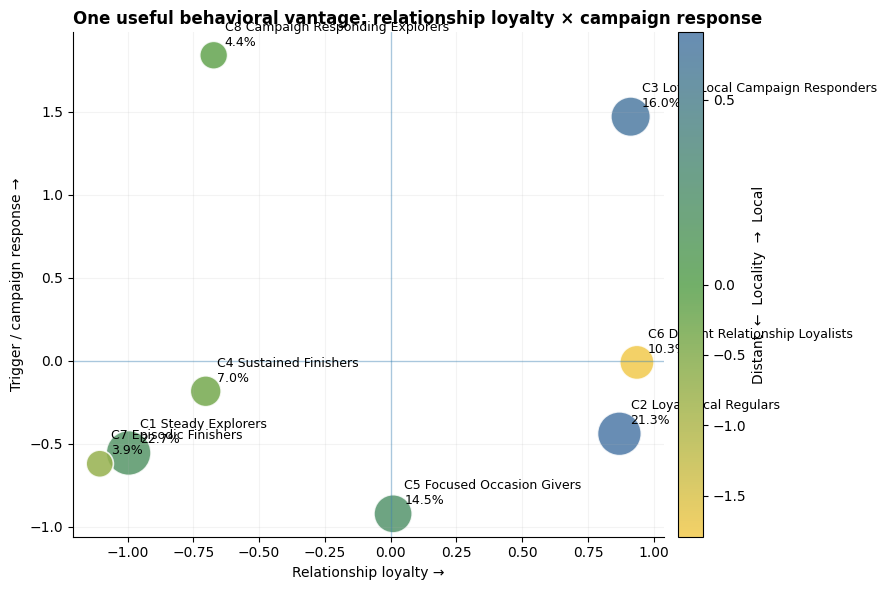

In [23]:
# =============================================================================
# STRATEGIC POSITIONING MAP
# Relationship loyalty x campaign response; color = locality; size = prevalence
# =============================================================================

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

# Assigned donors describe behavior; all repeat donors size the audience.
plot = (
    UNIT_PROFILE_LONG
    .pivot(index="cluster", columns="unit", values="score")
    [["relationship_loyalty", "trigger", "jtbd_local_stewardship"]]
    .join(
        BUSINESS_DONORS["cluster"]
        .value_counts(normalize=True)
        .rename("donor_share")
    )
    .sort_index()
)

# Yellow = distant, green = neutral, blue = local.
locality_cmap = LinearSegmentedColormap.from_list(
    "locality",
    ["#F2C94C", "#59A14F", "#4E79A7"],
)
locality_norm = TwoSlopeNorm(
    vmin=plot["jtbd_local_stewardship"].min(),
    vcenter=0,
    vmax=plot["jtbd_local_stewardship"].max(),
)

fig, ax = plt.subplots(figsize=(9, 6))

points = ax.scatter(
    plot["relationship_loyalty"],
    plot["trigger"],
    s=250 + plot["donor_share"] * 3500,
    c=plot["jtbd_local_stewardship"],
    cmap=locality_cmap,
    norm=locality_norm,
    alpha=0.85,
    edgecolor="white",
    linewidth=1.2,
)

for cluster, row in plot.iterrows():
    ax.annotate(
        f"C{cluster} {CLUSTER_LABELS[cluster]}\n{row['donor_share']:.1%}",
        (row["relationship_loyalty"], row["trigger"]),
        xytext=(8, 7),
        textcoords="offset points",
        fontsize=9,
    )

ax.axhline(0, linewidth=1, alpha=0.35)
ax.axvline(0, linewidth=1, alpha=0.35)
ax.grid(alpha=0.15)

ax.set_xlabel("Relationship loyalty →")
ax.set_ylabel("Trigger / campaign response →")
ax.set_title(
    "One useful behavioral vantage: relationship loyalty × campaign response",
    loc="left",
    fontweight="bold",
)

cbar = fig.colorbar(points, ax=ax, pad=0.02)
cbar.set_label("Distant  ←  Locality  →  Local")

ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [24]:
# 10. HTML helpers
# -----------------------------------------------------------------------------

def _fmt(v, fmt):
    if pd.isna(v):
        return "-"
    if fmt == "percent":
        return f"{v:.0%}"
    if fmt == "dollar":
        return f"${v:,.0f}"
    if fmt == "days":
        return f"{v:,.0f} days"
    if fmt == "miles":
        return f"{v:,.0f} mi"
    if fmt == "ratio":
        return f"{v:.2f}x"
    return f"{v:,.1f}"


def _idx_badge(v):
    if pd.isna(v):
        return "<span style='color:#888'>n/a</span>"
    if v >= EXEC_INDEX_OVER:
        bg, tag = "#dbeafe", "OVER"
    elif v <= EXEC_INDEX_UNDER:
        bg, tag = "#fef3c7", "UNDER"
    else:
        bg, tag = "#f3f4f6", ""
    return (
        f"<span style='display:inline-block;padding:2px 6px;border-radius:4px;background:{bg};font-weight:700'>"
        f"{v:.2f}x{' ' + tag if tag else ''}</span>"
    )


def _title(text, sub=None):
    html = f"<div style='font-size:22px;font-weight:750;margin:24px 0 4px 0'>{escape(text)}</div>"
    if sub:
        html += f"<div style='font-size:13px;color:#666;margin-bottom:10px'>{escape(sub)}</div>"
    display(HTML(html))


def _metric_matrix(layer):
    d = EXEC_PROFILE_LONG.loc[EXEC_PROFILE_LONG["layer"].eq(layer)].copy()
    if d.empty:
        return "<div style='color:#777'>No available metrics in this layer.</div>"

    metric_order = list(dict.fromkeys(d["metric"].tolist()))
    clusters = sorted(d["cluster"].unique())
    rows = []
    for metric in metric_order:
        m = d.loc[d["metric"].eq(metric)]
        r0 = m.iloc[0]
        cells = [
            f"<td style='padding:6px 8px;font-weight:650'>{escape(metric)}"
            + (f"<div style='font-size:10px;color:#777;font-weight:400'>{escape(r0['note'])}</div>" if r0["note"] else "")
            + "</td>",
            f"<td style='padding:6px 8px;text-align:right;color:#555'><div>{_fmt(r0['overall_value'], r0['format'])}</div>" + (f"<div style='font-size:9px;color:#888'>{r0['overall_coverage']:.0%} measured</div>" if r0['overall_coverage'] < .95 else "") + "</td>",
        ]
        for c in clusters:
            rr = m.loc[m["cluster"].eq(c)].iloc[0]
            cells.append(
                "<td style='padding:6px 8px;text-align:right;white-space:nowrap'>"
                f"<div style='font-weight:650'>{_fmt(rr['cluster_value'], rr['format'])}</div>"
                f"<div style='margin-top:2px'>{_idx_badge(rr['index_vs_overall'])}</div>"
                + (f"<div style='font-size:9px;color:#888'>{rr['cluster_coverage']:.0%} measured</div>" if rr['cluster_coverage'] < .95 else "")
                + "</td>"
            )
        rows.append("<tr style='border-bottom:1px solid #eee'>" + "".join(cells) + "</tr>")

    heads = "".join(
        f"<th style='padding:6px 8px;text-align:right'>{c}<div style='font-size:10px;font-weight:400'>{escape(CLUSTER_LABELS.get(c, ''))}</div></th>"
        for c in clusters
    )
    return (
        "<div style='overflow-x:auto'><table style='border-collapse:collapse;width:100%;font-size:12px'>"
        "<thead><tr style='background:#f8fafc;border-bottom:1px solid #ccc'>"
        "<th style='padding:6px 8px;text-align:left'>Metric</th>"
        "<th style='padding:6px 8px;text-align:right'>Overall</th>"
        + heads + "</tr></thead><tbody>" + "".join(rows) + "</tbody></table></div>"
    )


def _job_matrix_html():
    if EXEC_JOB_INDEX_LONG.empty:
        return "<div style='color:#777'>Run the JTBD cell first.</div>"
    top_col = f"top_{globals().get('JTBD_TOP_N', 2)}_share"
    jobs = EXEC_JOB_INDEX_LONG.groupby("Job")["overall_top_n_share"].first().sort_values(ascending=False).index.tolist()
    clusters = sorted(EXEC_JOB_INDEX_LONG["cluster"].unique())
    rows = []
    for job in jobs:
        sub = EXEC_JOB_INDEX_LONG.loc[EXEC_JOB_INDEX_LONG["Job"].eq(job)]
        overall = sub["overall_top_n_share"].dropna().iloc[0]
        cells = [
            f"<td style='padding:6px 8px;font-weight:650'>{escape(job)}</td>",
            f"<td style='padding:6px 8px;text-align:right'>{overall:.0%}</td>",
        ]
        for c in clusters:
            r = sub.loc[sub["cluster"].eq(c)].iloc[0]
            cells.append(
                "<td style='padding:6px 8px;text-align:right;white-space:nowrap'>"
                f"<div style='font-weight:650'>{r[top_col]:.0%}</div>"
                f"<div>{_idx_badge(r['index_vs_overall'])}</div>"
                "</td>"
            )
        rows.append("<tr style='border-bottom:1px solid #eee'>" + "".join(cells) + "</tr>")

    heads = "".join(
        f"<th style='padding:6px 8px;text-align:right'>C{c}<div style='font-size:10px;font-weight:400'>{escape(CLUSTER_LABELS.get(c, ''))}</div></th>"
        for c in clusters
    )
    return (
        "<div style='overflow-x:auto'><table style='border-collapse:collapse;width:100%;font-size:12px'>"
        "<thead><tr style='background:#f8fafc;border-bottom:1px solid #ccc'>"
        "<th style='padding:6px 8px;text-align:left'>Behavioral Job signal</th>"
        "<th style='padding:6px 8px;text-align:right'>Overall Top-2</th>"
        + heads + "</tr></thead><tbody>" + "".join(rows) + "</tbody></table></div>"
    )


def _revenue_html():
    if EXEC_REVENUE_CONCENTRATION.empty:
        return "<div style='color:#777'>No revenue fields available.</div>"
    rows = []
    for measure, sub in EXEC_REVENUE_CONCENTRATION.groupby("revenue_measure", sort=False):
        for r in sub.itertuples(index=False):
            rows.append(
                "<tr style='border-bottom:1px solid #eee'>"
                f"<td style='padding:6px 8px;font-weight:650'>{escape(measure)}</td>"
                f"<td style='padding:6px 8px'>C{r.cluster} {escape(r.cluster_label)}</td>"
                f"<td style='padding:6px 8px;text-align:right'>{r.donor_share:.1%}</td>"
                f"<td style='padding:6px 8px;text-align:right'>${r.revenue_dollars:,.0f}</td>"
                f"<td style='padding:6px 8px;text-align:right'>{r.revenue_share:.1%}</td>"
                f"<td style='padding:6px 8px;text-align:right'>{_idx_badge(r.revenue_index_vs_donor_share)}</td>"
                "</tr>"
            )
    return (
        "<div style='overflow-x:auto'><table style='border-collapse:collapse;width:100%;font-size:12px'>"
        "<thead><tr style='background:#f8fafc;border-bottom:1px solid #ccc'>"
        "<th style='padding:6px 8px;text-align:left'>Revenue measure</th>"
        "<th style='padding:6px 8px;text-align:left'>Cluster</th>"
        "<th style='padding:6px 8px;text-align:right'>Donor share</th>"
        "<th style='padding:6px 8px;text-align:right'>Dollars</th>"
        "<th style='padding:6px 8px;text-align:right'>Revenue share</th>"
        "<th style='padding:6px 8px;text-align:right'>Revenue index</th>"
        "</tr></thead><tbody>" + "".join(rows) + "</tbody></table></div>"
    )



def _distribution_html():
    if EXEC_DISTRIBUTIONS.empty:
        return "<div style='color:#777'>No robust distribution fields available.</div>"
    rows = []
    for metric, sub in EXEC_DISTRIBUTIONS.groupby("metric", sort=False):
        for _, r in sub.sort_values("cluster").iterrows():
            fmt = r["format"]
            rows.append(
                "<tr style='border-bottom:1px solid #eee'>"
                f"<td style='padding:5px 7px;font-weight:650'>{escape(metric)}</td>"
                f"<td style='padding:5px 7px'>C{int(r['cluster'])} {escape(r['cluster_label'])}</td>"
                f"<td style='padding:5px 7px;text-align:right'>{_fmt(r['p25'], fmt)}</td>"
                f"<td style='padding:5px 7px;text-align:right;font-weight:650'>{_fmt(r['p50'], fmt)}</td>"
                f"<td style='padding:5px 7px;text-align:right'>{_fmt(r['p75'], fmt)}</td>"
                "</tr>"
            )
    return (
        "<div style='margin-top:12px;font-weight:700'>Distribution context (P25 / median / P75)</div>"
        "<div style='overflow-x:auto'><table style='border-collapse:collapse;width:100%;font-size:11px;margin-top:5px'>"
        "<tr style='background:#f8fafc'><th style='text-align:left;padding:5px 7px'>Metric</th>"
        "<th style='text-align:left;padding:5px 7px'>Cluster</th><th style='text-align:right;padding:5px 7px'>P25</th>"
        "<th style='text-align:right;padding:5px 7px'>Median</th><th style='text-align:right;padding:5px 7px'>P75</th></tr>"
        + "".join(rows) + "</table></div></div>"
    )

def _category_cards_html():
    if EXEC_CATEGORY_INDEX_LONG.empty:
        return "<div style='color:#777'>No category-level fields met the display thresholds.</div>"
    cards = []
    for c in sorted(EXEC_CATEGORY_INDEX_LONG["cluster"].unique()):
        sub = EXEC_CATEGORY_INDEX_LONG.loc[EXEC_CATEGORY_INDEX_LONG["cluster"].eq(c)].copy()
        over = sub.sort_values("index_vs_overall", ascending=False).head(EXEC_TOP_CATEGORY_N)
        under = sub.sort_values("index_vs_overall", ascending=True).head(EXEC_BOTTOM_CATEGORY_N)
        show = pd.concat([over, under]).drop_duplicates("category")
        rows = []
        for r in show.itertuples(index=False):
            rows.append(
                "<tr>"
                f"<td style='padding:4px 6px'>{escape(r.category)}</td>"
                f"<td style='padding:4px 6px;text-align:right'>{r.cluster_share:.0%}</td>"
                f"<td style='padding:4px 6px;text-align:right'>{r.overall_share:.0%}</td>"
                f"<td style='padding:4px 6px;text-align:right'>{_idx_badge(r.index_vs_overall)}</td>"
                "</tr>"
            )
        cards.append(
            "<div style='border:1px solid #ddd;border-radius:7px;padding:10px 12px;margin:6px;min-width:320px;flex:1'>"
            f"<div style='font-size:15px;font-weight:700'>C{c} {escape(CLUSTER_LABELS.get(c, ''))}</div>"
            "<table style='width:100%;font-size:11px;border-collapse:collapse;margin-top:5px'>"
            "<tr style='background:#f8fafc'><th style='text-align:left;padding:4px 6px'>Category</th>"
            "<th style='text-align:right;padding:4px 6px'>Cluster</th><th style='text-align:right;padding:4px 6px'>Overall</th>"
            "<th style='text-align:right;padding:4px 6px'>Index</th></tr>"
            + "".join(rows) + "</table></div>"
        )
    return "<div style='display:flex;flex-wrap:wrap'>" + "".join(cards) + "</div>"


def _job_pair_cards_html():
    if EXEC_JOB_PAIR_INDEX_LONG.empty:
        return "<div style='color:#777'>Job-pair output unavailable; run the JTBD ranking cell first.</div>"
    cards = []
    for c in sorted(EXEC_JOB_PAIR_INDEX_LONG["cluster"].unique()):
        sub = EXEC_JOB_PAIR_INDEX_LONG.loc[EXEC_JOB_PAIR_INDEX_LONG["cluster"].eq(c)].copy()
        sub = sub.sort_values(["index_vs_overall", "cluster_share"], ascending=[False, False]).head(EXEC_TOP_JOB_PAIR_N)
        rows = []
        for _, r in sub.iterrows():
            rows.append(
                "<tr>"
                f"<td style='padding:4px 6px'>{escape(str(r['Job pair']))}</td>"
                f"<td style='padding:4px 6px;text-align:right'>{r['cluster_share']:.0%}</td>"
                f"<td style='padding:4px 6px;text-align:right'>{r['overall_share']:.0%}</td>"
                f"<td style='padding:4px 6px;text-align:right'>{_idx_badge(r['index_vs_overall'])}</td>"
                "</tr>"
            )
        cards.append(
            "<div style='border:1px solid #ddd;border-radius:7px;padding:10px 12px;margin:6px;min-width:360px;flex:1'>"
            f"<div style='font-size:15px;font-weight:700'>C{c} {escape(CLUSTER_LABELS.get(c, ''))}</div>"
            "<table style='width:100%;font-size:11px;border-collapse:collapse;margin-top:5px'>"
            "<tr style='background:#f8fafc'><th style='text-align:left;padding:4px 6px'>Over-indexed Job pair</th>"
            "<th style='text-align:right;padding:4px 6px'>Cluster</th><th style='text-align:right;padding:4px 6px'>Overall</th>"
            "<th style='text-align:right;padding:4px 6px'>Index</th></tr>"
            + "".join(rows) + "</table></div>"
        )
    return "<div style='display:flex;flex-wrap:wrap'>" + "".join(cards) + "</div>"

def _availability_html():
    rows = []
    for r in EXEC_AVAILABILITY_AUDIT.itertuples(index=False):
        status_bg = "#dcfce7" if r.status == "AVAILABLE" else "#fef3c7"
        cov = "-" if pd.isna(r.coverage) else f"{r.coverage:.0%}"
        rows.append(
            "<tr style='border-bottom:1px solid #eee'>"
            f"<td style='padding:5px 7px'>{escape(r.layer)}</td>"
            f"<td style='padding:5px 7px;font-weight:650'>{escape(r.needed)}</td>"
            f"<td style='padding:5px 7px'><span style='background:{status_bg};padding:2px 5px;border-radius:4px;font-weight:700'>{escape(r.status)}</span></td>"
            f"<td style='padding:5px 7px;font-family:ui-monospace,monospace;font-size:10px'>{escape(str(r.field_or_object))}</td>"
            f"<td style='padding:5px 7px;text-align:right'>{cov}</td>"
            f"<td style='padding:5px 7px;color:#555'>{escape(r.note)}</td>"
            "</tr>"
        )
    return (
        "<div style='overflow-x:auto'><table style='border-collapse:collapse;width:100%;font-size:11px'>"
        "<thead><tr style='background:#f8fafc'><th style='text-align:left;padding:5px 7px'>Layer</th>"
        "<th style='text-align:left;padding:5px 7px'>Need</th><th style='text-align:left;padding:5px 7px'>Status</th>"
        "<th style='text-align:left;padding:5px 7px'>Field / object</th><th style='text-align:right;padding:5px 7px'>Coverage</th>"
        "<th style='text-align:left;padding:5px 7px'>Interpretation</th></tr></thead><tbody>"
        + "".join(rows) + "</tbody></table></div>"
    )

# -----------------------------------------------------------------------------
# 11. Render the executive analysis in a readable sequence
# -----------------------------------------------------------------------------

_display_weight = globals().get("UNIT_WEIGHTS", {}).get("jtbd_local_stewardship", 1.0)
_title(
    "Executive-readout analytical layers",
    f"Selected K={SELECTED_K} | profile base={len(EXEC_BASE):,} assigned donors | prevalence/business base={len(EXEC_BUSINESS_BASE):,} repeat donors. Profile cells use assigned donors; revenue concentration uses all scored repeat donors."
)

_title("A. What the current data can answer", "Missing items are surfaced rather than inferred.")
display(HTML(_availability_html()))

_title("B. Economic value", "Revenue concentration answers whether a cluster carries more or less revenue than its population size would suggest.")
display(HTML(_metric_matrix("Economic value")))
display(HTML("<div style='height:10px'></div>" + _revenue_html()))
display(HTML(_distribution_html()))

_title("C. Lifecycle + monthly relationship", "These are current/lifetime descriptors; true future retention still requires a later observation window.")
display(HTML(_metric_matrix("Lifecycle + retention")))

_title("D. Digital product intensity", "Site coverage and journey observability matter; read the raw values together with coverage, not as pure motivation.")
display(HTML(_metric_matrix("Digital product intensity")))

_title("E. Optional tip economics", "Platform support is profiled after clustering so it can be economically important without defining persona identity.")
display(HTML(_metric_matrix("Optional tip economics")))

_title("F. Choice + need affinity", "Broad merchandising/recommendation signals first; detailed categories follow below.")
display(HTML(_metric_matrix("Choice + need affinity")))

_title("G. Category affinities", f"Shows categories with >= {EXEC_CATEGORY_MIN_OVERALL_SHARE:.0%} overall average gift-share baseline; rare other/unknown buckets excluded.")
display(HTML(_category_cards_html()))

_title("H. Jobs across the portfolio", "Each cell is cluster Top-2 prevalence plus its index vs the overall donor population. This is behavioral evidence consistent with a Job, not stated motivation.")
display(HTML(_job_matrix_html()))

if not EXEC_JOB_COVERAGE.empty:
    _rows = []
    for _, r in EXEC_JOB_COVERAGE.iterrows():
        _rows.append(
            "<tr style='border-bottom:1px solid #eee'>"
            f"<td style='padding:4px 6px'>C{int(r['cluster'])} {escape(r['cluster_label'])}</td>"
            f"<td style='padding:4px 6px;text-align:right'>{int(r['ranking_eligible_n']):,}</td>"
            f"<td style='padding:4px 6px;text-align:right;font-weight:650'>{r['ranking_eligible_share']:.0%}</td>"
            "</tr>"
        )
    display(HTML(
        "<div style='margin-top:10px;font-weight:700'>Job-ranking coverage</div>"
        "<div style='font-size:11px;color:#666;margin-bottom:4px'>Top-2 comparisons use donors with all rankable Jobs measured; large coverage differences by cluster would weaken direct comparisons.</div>"
        "<table style='border-collapse:collapse;font-size:11px;min-width:520px'>"
        "<tr style='background:#f8fafc'><th style='text-align:left;padding:4px 6px'>Cluster</th>"
        "<th style='text-align:right;padding:4px 6px'>Eligible donors</th><th style='text-align:right;padding:4px 6px'>Eligible share</th></tr>"
        + "".join(_rows) + "</table>"
    ))

if not EXEC_JOB_PORTFOLIO.empty:
    _jp = EXEC_JOB_PORTFOLIO.copy()
    _rows = []
    for r in _jp.itertuples(index=False):
        _rows.append(
            "<tr style='border-bottom:1px solid #eee'>"
            f"<td style='padding:5px 7px;font-weight:650'>{escape(r.Job)}</td>"
            f"<td style='padding:5px 7px;text-align:right'>{r.overall_top2_share:.0%}</td>"
            f"<td style='padding:5px 7px'>{escape(r.highest_cluster)}</td>"
            f"<td style='padding:5px 7px;text-align:right'>{_idx_badge(r.highest_index)}</td>"
            f"<td style='padding:5px 7px'>{escape(r.lowest_cluster)}</td>"
            f"<td style='padding:5px 7px;text-align:right'>{_idx_badge(r.lowest_index)}</td>"
            "</tr>"
        )
    display(HTML(
        "<div style='margin-top:12px;font-weight:700'>Which Jobs actually separate the portfolio?</div>"
        "<table style='border-collapse:collapse;width:100%;font-size:11px;margin-top:5px'>"
        "<tr style='background:#f8fafc'><th style='text-align:left;padding:5px 7px'>Job</th>"
        "<th style='text-align:right;padding:5px 7px'>Overall Top-2</th><th style='text-align:left;padding:5px 7px'>Highest cluster</th>"
        "<th style='text-align:right;padding:5px 7px'>High index</th><th style='text-align:left;padding:5px 7px'>Lowest cluster</th>"
        "<th style='text-align:right;padding:5px 7px'>Low index</th></tr>" + "".join(_rows) + "</table>"
    ))

if not EXEC_EVIDENCE_ONLY_JOB_INDEX.empty:
    _rows = []
    for r in EXEC_EVIDENCE_ONLY_JOB_INDEX.sort_values(["Job", "cluster"]).itertuples(index=False):
        _rows.append(
            "<tr style='border-bottom:1px solid #eee'>"
            f"<td style='padding:5px 7px;font-weight:650'>{escape(r.Job)}</td>"
            f"<td style='padding:5px 7px'>C{r.cluster} {escape(r.cluster_label)}</td>"
            f"<td style='padding:5px 7px;text-align:right'>{_idx_badge(r.index_vs_overall)}</td>"
            f"<td style='padding:5px 7px;text-align:right'>{r.measured_share:.0%}</td>"
            "</tr>"
        )
    display(HTML(
        "<div style='margin-top:14px;font-weight:700'>Evidence-only Jobs</div>"
        "<div style='font-size:11px;color:#666;margin-bottom:5px'>These do not receive Top-2 slots; the index compares mean raw behavioral evidence with overall.</div>"
        "<table style='border-collapse:collapse;width:100%;font-size:11px'>"
        "<tr style='background:#f8fafc'><th style='text-align:left;padding:5px 7px'>Job</th><th style='text-align:left;padding:5px 7px'>Cluster</th>"
        "<th style='text-align:right;padding:5px 7px'>Evidence index</th><th style='text-align:right;padding:5px 7px'>Measured</th></tr>"
        + "".join(_rows) + "</table>"
    ))

_title("I. Job combinations", "Top over-indexed Top-2 Job pairs by cluster; useful for deciding which Jobs might be sequenced or combined rather than treated independently.")
display(HTML(_job_pair_cards_html()))

_title("J. Core behavioral fingerprint in raw terms", "Same clustering ingredients, but reported as raw values and indexes instead of +/- SD unit scores.")
display(HTML(_metric_matrix("Core behavior")))

_title("K. Audience context", "Useful context for activation and treatment design; these variables did not define the cluster geometry.")
display(HTML(_metric_matrix("Audience context")))

# -----------------------------------------------------------------------------
# 12. One compact cluster-by-cluster readout for later DOCX synthesis
# -----------------------------------------------------------------------------

_title("L. Extended cluster cards", "Top over/under-indexes from each analytical layer, plus strongest Job tendencies.")

_layers_for_cards = [
    "Economic value", "Lifecycle + retention", "Digital product intensity",
    "Optional tip economics", "Choice + need affinity"
]

for cluster in sorted(EXEC_BASE["cluster"].unique()):
    profile_n = int(EXEC_BASE["cluster"].eq(cluster).sum())
    prevalence_n = int(CLUSTER_PREVALENCE.loc[int(cluster), "donors"])
    prevalence_share = float(CLUSTER_PREVALENCE.loc[int(cluster), "share"])
    card_parts = [
        f"<div style='border:1px solid #d1d5db;border-radius:9px;padding:14px 16px;margin:12px 0 20px;background:white'>",
        f"<div style='font-size:20px;font-weight:750'>C{cluster} {escape(CLUSTER_LABELS.get(int(cluster), ''))}</div>",
        f"<div style='font-size:12px;color:#666;margin-bottom:9px'>{prevalence_n:,} repeat donors | {prevalence_share:.1%} prevalence | {profile_n:,} assigned donors profiled</div>",
    ]

    for layer in _layers_for_cards:
        d = EXEC_PROFILE_LONG.loc[
            EXEC_PROFILE_LONG["cluster"].eq(cluster) & EXEC_PROFILE_LONG["layer"].eq(layer)
        ].copy()
        d = d.dropna(subset=["index_vs_overall"])
        if d.empty:
            continue
        d["distance_from_1"] = (d["index_vs_overall"] - 1).abs()
        d = d.sort_values("distance_from_1", ascending=False).head(4)
        card_parts.append(f"<div style='font-size:13px;font-weight:700;margin-top:9px'>{escape(layer)}</div>")
        card_parts.append("<table style='width:100%;font-size:11px;border-collapse:collapse'>")
        for _, r in d.iterrows():
            card_parts.append(
                "<tr style='border-bottom:1px solid #f0f0f0'>"
                f"<td style='padding:4px 6px'>{escape(r['metric'])}</td>"
                f"<td style='padding:4px 6px;text-align:right;font-weight:650'>{_fmt(r['cluster_value'], r['format'])}</td>"
                f"<td style='padding:4px 6px;text-align:right;color:#666'>overall {_fmt(r['overall_value'], r['format'])}</td>"
                f"<td style='padding:4px 6px;text-align:right'>{_idx_badge(r['index_vs_overall'])}</td>"
                "</tr>"
            )
        card_parts.append("</table>")

    if not EXEC_JOB_INDEX_LONG.empty:
        top_col = f"top_{globals().get('JTBD_TOP_N', 2)}_share"
        jd = EXEC_JOB_INDEX_LONG.loc[EXEC_JOB_INDEX_LONG["cluster"].eq(cluster)].copy()
        jd = jd.sort_values(["index_vs_overall", top_col], ascending=[False, False]).head(4)
        card_parts.append("<div style='font-size:13px;font-weight:700;margin-top:9px'>Strongest Job tendencies</div>")
        card_parts.append("<table style='width:100%;font-size:11px;border-collapse:collapse'>")
        for _, r in jd.iterrows():
            card_parts.append(
                "<tr style='border-bottom:1px solid #f0f0f0'>"
                f"<td style='padding:4px 6px'>{escape(r['Job'])}</td>"
                f"<td style='padding:4px 6px;text-align:right'>{r[top_col]:.0%} Top-2</td>"
                f"<td style='padding:4px 6px;text-align:right'>{_idx_badge(r['index_vs_overall'])}</td>"
                "</tr>"
            )
        card_parts.append("</table>")

    card_parts.append("</div>")
    display(HTML("".join(card_parts)))

# -----------------------------------------------------------------------------
# 13. Objects preserved for the follow-up report
# -----------------------------------------------------------------------------

EXEC_MODEL_SPEC = pd.DataFrame([
    {
        "unit": unit,
        "unit_weight": float(globals().get("UNIT_WEIGHTS", {}).get(unit, 1.0)),
        "feature": feature,
        "direction": "+" if direction > 0 else "-",
    }
    for unit, spec in UNITS_NOW.items()
    for feature, direction in spec.items()
])

EXEC_ALL_OBJECTS = {
    "profile_base": EXEC_BASE,
    "business_base": EXEC_BUSINESS_BASE,
    "model_spec": EXEC_MODEL_SPEC,
    "availability_audit": EXEC_AVAILABILITY_AUDIT,
    "profile_long": EXEC_PROFILE_LONG,
    "revenue_concentration": EXEC_REVENUE_CONCENTRATION,
    "distributions": EXEC_DISTRIBUTIONS,
    "category_index_long": EXEC_CATEGORY_INDEX_LONG,
    "job_index_long": EXEC_JOB_INDEX_LONG,
    "job_portfolio": EXEC_JOB_PORTFOLIO,
    "job_coverage": EXEC_JOB_COVERAGE,
    "evidence_only_job_index": EXEC_EVIDENCE_ONLY_JOB_INDEX,
    "job_pair_index_long": EXEC_JOB_PAIR_INDEX_LONG,
}

print(
    "Created: EXEC_BASE, EXEC_MODEL_SPEC, EXEC_AVAILABILITY_AUDIT, "
    "EXEC_PROFILE_LONG, EXEC_REVENUE_CONCENTRATION, EXEC_DISTRIBUTIONS, "
    "EXEC_CATEGORY_INDEX_LONG, EXEC_JOB_INDEX_LONG, EXEC_JOB_PORTFOLIO, EXEC_JOB_COVERAGE, "
    "EXEC_EVIDENCE_ONLY_JOB_INDEX, EXEC_JOB_PAIR_INDEX_LONG, EXEC_ALL_OBJECTS"
)


Layer,Need,Status,Field / object,Coverage,Interpretation
Economic value,Observed lifetime revenue,AVAILABLE,lifetime_amount,100%,Available lifetime project-gift revenue; this is not predictive LTV.
Economic value,Predictive LTV,MISSING / FOLLOW-ON,-,-,Requires a true LTV/predicted future-value field or separate model.
Economic value,Current-window project revenue,AVAILABLE,gift_amount_24m,100%,Current notebook window is 24 months.
Economic value,Current-window all-giving revenue,AVAILABLE,grand_amount_24m,100%,Preferred if project + monthly dollars are available.
Lifecycle + retention,Current lifecycle state,AVAILABLE,is_continuing_donor_24m,100%,New/reactivated/continuing are current-window state descriptors.
Lifecycle + retention,Future retention / next-gift outcome,MISSING / FOLLOW-ON,-,-,Needs a subsequent observation window; should remain post-fit.
Digital product intensity,Site-active days,AVAILABLE,days_with_site_activity_24m,95%,Available if site source is observed.
Digital product intensity,True-session grain,AVAILABLE,site_unit_is_session,100%,"If 0, visit counts are donor-day rather than true sessions."
Digital product intensity,Project-page activity,AVAILABLE,project_page_visits_day_total_24m,95%,Available in current site feature family if loaded.
Digital product intensity,Unique projects viewed per session,MISSING / FOLLOW-ON,-,-,Not present in the current dictionary unless a newer feature build added it.


Metric,Overall,1Steady Explorers,2Loyal Local Regulars,3Loyal Local Campaign Responders,4Sustained Finishers,5Focused Occasion Givers,6Distant Relationship Loyalists,7Episodic Finishers,8Campaign Responding Explorers
24m project revenue per donor,$203,$1650.81x,$1900.94x,$1920.95x,"$1,1245.54x OVER",$1550.76x UNDER,$2000.99x,$5792.85x OVER,$1930.95x
Previous equal-length-window project revenue per donorPrior window matches the configured current-window length,$24549% measured,$2000.82x46% measured,$1700.69x UNDER50% measured,$2200.90x56% measured,"$1,1004.49x OVER69% measured",$1790.73x UNDER31% measured,$1750.71x UNDER54% measured,$8833.60x OVER51% measured,$3121.27x OVER48% measured
24m all-giving revenue per donorProject + monthly if available,$204,$1660.81x,$1920.94x,$1920.94x,"$1,1605.69x OVER",$1560.76x UNDER,$2000.98x,$5812.85x OVER,$1930.95x
"Lifetime project revenue per donorObserved lifetime revenue, not predictive LTV",$380,$2850.75x UNDER,$3200.84x,$3690.97x,"$2,8517.50x OVER",$2410.63x UNDER,$3851.01x,"$1,4213.74x OVER",$3700.97x
Lifetime project gifts,8.0,7.00.88x,7.00.88x,7.00.88x,27.03.38x OVER,7.00.88x,7.00.88x,16.02.00x OVER,7.00.88x
Median project gift,$35,$250.71x UNDER,$351.00x,$381.07x,$922.64x OVER,$200.57x UNDER,$501.43x OVER,$411.18x,$381.07x
Major-gift donor share,0%,0%0.00x UNDER,0%0.00x UNDER,0%0.00x UNDER,0%8.26x OVER,0%0.00x UNDER,0%0.00x UNDER,0%6.66x OVER,0%0.00x UNDER


Revenue measure,Cluster,Donor share,Dollars,Revenue share,Revenue index
24m project revenue,C1 Steady Explorers,22.7%,"$11,365,281",8.9%,0.39x UNDER
24m project revenue,C2 Loyal Local Regulars,21.3%,"$12,234,680",9.6%,0.45x UNDER
24m project revenue,C3 Loyal Local Campaign Responders,16.0%,"$10,552,154",8.2%,0.51x UNDER
24m project revenue,C4 Sustained Finishers,7.0%,"$27,907,661",21.8%,3.13x OVER
24m project revenue,C5 Focused Occasion Givers,14.5%,"$11,028,124",8.6%,0.59x UNDER
24m project revenue,C6 Distant Relationship Loyalists,10.3%,"$6,234,250",4.9%,0.47x UNDER
24m project revenue,C7 Episodic Finishers,3.9%,"$37,784,179",29.5%,7.64x OVER
24m project revenue,C8 Campaign Responding Explorers,4.4%,"$10,891,645",8.5%,1.94x OVER
24m all-giving revenue,C1 Steady Explorers,22.7%,"$11,993,543",9.2%,0.41x UNDER
24m all-giving revenue,C2 Loyal Local Regulars,21.3%,"$12,481,677",9.6%,0.45x UNDER


Metric,Cluster,P25,Median,P75
24m project revenue per donor,C1 Steady Explorers,$83,$165,$370
24m project revenue per donor,C2 Loyal Local Regulars,$100,$190,$400
24m project revenue per donor,C3 Loyal Local Campaign Responders,$94,$192,$423
24m project revenue per donor,C4 Sustained Finishers,$506,"$1,124","$2,605"
24m project revenue per donor,C5 Focused Occasion Givers,$75,$155,$375
24m project revenue per donor,C6 Distant Relationship Loyalists,$108,$200,$402
24m project revenue per donor,C7 Episodic Finishers,$190,$579,"$2,072"
24m project revenue per donor,C8 Campaign Responding Explorers,$75,$193,$520
Lifetime project revenue per donor,C1 Steady Explorers,$120,$285,$894
Lifetime project revenue per donor,C2 Loyal Local Regulars,$140,$320,$880


Metric,Overall,1Steady Explorers,2Loyal Local Regulars,3Loyal Local Campaign Responders,4Sustained Finishers,5Focused Occasion Givers,6Distant Relationship Loyalists,7Episodic Finishers,8Campaign Responding Explorers
Giving tenure,"1,245 days","1,092 days0.88x","1,078 days0.87x","1,367 days1.10x","2,327 days1.87x OVER",720 days0.58x UNDER,"1,551 days1.25x OVER","1,805 days1.45x OVER","1,452 days1.17x"
Days since last project giftLower = more recent,224 days,192 days0.86x,189 days0.84x,245 days1.09x,110 days0.49x UNDER,296 days1.32x OVER,208 days0.93x,237 days1.06x,310 days1.38x OVER
Active giving months,3.0,3.01.00x,3.01.00x,3.01.00x,5.01.67x OVER,2.00.67x UNDER,3.01.00x,2.00.67x UNDER,2.00.67x UNDER
New-donor share,39%,43%1.09x,41%1.04x,35%0.89x,23%0.59x UNDER,53%1.35x OVER,32%0.80x UNDER,34%0.86x,36%0.92x
Reactivated-donor share,12%,11%0.96x,9%0.80x UNDER,9%0.79x UNDER,8%0.67x UNDER,16%1.35x OVER,14%1.21x OVER,15%1.32x OVER,16%1.35x OVER
Continuing-donor share,49%,46%0.94x,50%1.02x,56%1.14x,69%1.41x OVER,31%0.64x UNDER,54%1.11x,51%1.04x,48%0.98x
Current monthly-donor share,2%,3%1.85x OVER,1%0.62x UNDER,0%0.06x UNDER,5%2.82x OVER,1%0.56x UNDER,2%0.94x,2%1.10x,1%0.30x UNDER
Monthly active months,0.0,0.0n/a,0.0n/a,0.0n/a,0.0n/a,0.0n/a,0.0n/a,0.0n/a,0.0n/a
Longest monthly streak,17.04% measured,20.01.18x6% measured,11.00.65x UNDER3% measured,8.50.50x UNDER1% measured,45.02.65x OVER8% measured,9.00.53x UNDER3% measured,13.00.76x UNDER4% measured,23.01.35x OVER5% measured,12.00.71x UNDER2% measured
Share of giving from monthly,1%,1%1.83x OVER,1%0.81x,0%0.07x UNDER,2%2.27x OVER,0%0.62x UNDER,1%1.12x,1%0.75x UNDER,0%0.29x UNDER


...

Major-gift donor share,0%,overall 0%,0.00x UNDER
Median project gift,$20,overall $35,0.57x UNDER
Lifetime project revenue per donor,$241,overall $380,0.63x UNDER
Previous equal-length-window project revenue per donor,$179,overall $245,0.73x UNDER
Longest monthly streak,9.0,overall 17.0,0.53x UNDER
Current monthly-donor share,1%,overall 2%,0.56x UNDER
Giving tenure,720 days,"overall 1,245 days",0.58x UNDER
Share of giving from monthly,0%,overall 1%,0.62x UNDER
Project-page visits,3.0,overall 7.0,0.43x UNDER
Search visits,1.4,overall 3.2,0.44x UNDER
Site-active days,4.0,overall 8.0,0.50x UNDER


Major-gift donor share,0%,overall 0%,0.00x UNDER
Median project gift,$50,overall $35,1.43x OVER
Previous equal-length-window project revenue per donor,$175,overall $245,0.71x UNDER
Lifetime project gifts,7.0,overall 8.0,0.88x
Giving tenure,"1,551 days","overall 1,245 days",1.25x OVER
Longest monthly streak,13.0,overall 17.0,0.76x UNDER
Reactivated-donor share,14%,overall 12%,1.21x OVER
New-donor share,32%,overall 39%,0.80x UNDER
Gifts preceded by search,9%,overall 13%,0.67x UNDER
Search visit share,7%,overall 10%,0.67x UNDER
Search visits,2.4,overall 3.2,0.75x UNDER


Major-gift donor share,0%,overall 0%,6.66x OVER
Lifetime project revenue per donor,"$1,421",overall $380,3.74x OVER
Previous equal-length-window project revenue per donor,$883,overall $245,3.60x OVER
24m project revenue per donor,$579,overall $203,2.85x OVER
Giving tenure,"1,805 days","overall 1,245 days",1.45x OVER
Median monthly payment,$35,overall $25,1.40x OVER
Longest monthly streak,23.0,overall 17.0,1.35x OVER
Active giving months,2.0,overall 3.0,0.67x UNDER
Search visits,7.2,overall 3.2,2.24x OVER
Search visit share,21%,overall 10%,2.05x OVER
Gifts preceded by search,24%,overall 13%,1.84x OVER


Major-gift donor share,0%,overall 0%,0.00x UNDER
Previous equal-length-window project revenue per donor,$312,overall $245,1.27x OVER
Lifetime project gifts,7.0,overall 8.0,0.88x
Median project gift,$38,overall $35,1.07x
Share of giving from monthly,0%,overall 1%,0.29x UNDER
Current monthly-donor share,1%,overall 2%,0.30x UNDER
Median monthly payment,$40,overall $25,1.60x OVER
Days since last project gift,310 days,overall 224 days,1.38x OVER
Project-page visits,4.0,overall 7.0,0.57x UNDER
Search visits,4.3,overall 3.2,1.33x OVER
Gifts preceded by search,18%,overall 13%,1.32x OVER


Created: EXEC_BASE, EXEC_MODEL_SPEC, EXEC_AVAILABILITY_AUDIT, EXEC_PROFILE_LONG, EXEC_REVENUE_CONCENTRATION, EXEC_DISTRIBUTIONS, EXEC_CATEGORY_INDEX_LONG, EXEC_JOB_INDEX_LONG, EXEC_JOB_PORTFOLIO, EXEC_JOB_COVERAGE, EXEC_EVIDENCE_ONLY_JOB_INDEX, EXEC_JOB_PAIR_INDEX_LONG, EXEC_ALL_OBJECTS


## 16 — Business opportunity cuts

These are **aggregate sizing/context** analyses, so they use all scored 2+ repeat donors and their nearest cluster. They do not change persona definitions and they do not imply tentative donors are safe for persona-level targeting.


In [25]:
# $10K+ donors + DAF activity by cluster
x = BUSINESS_DONORS.copy()
revenue_field = first_available(x, "grand_amount_24m", "grand_amount_12m", "gift_amount_24m", "gift_amount_12m")
daf_field = first_available(x, "share_gifts_daf_24m", "share_gifts_daf_12m")
if revenue_field is None or daf_field is None:
    raise KeyError("High-value/DAF analysis requires a current-window revenue field and DAF share field.")

revenue = pd.to_numeric(x[revenue_field], errors="coerce")
daf_share = pd.to_numeric(x[daf_field], errors="coerce")
x["gave_10k_plus_24m"] = revenue >= LARGE_DONOR_THRESHOLD
x["any_daf_24m"] = daf_share > 0
x["gave_10k_plus_and_daf_24m"] = x["gave_10k_plus_24m"] & x["any_daf_24m"]

overall_rates = {
    "10k": x["gave_10k_plus_24m"].mean(),
    "daf": x["any_daf_24m"].mean(),
    "both": x["gave_10k_plus_and_daf_24m"].mean(),
}
rows = []
for cluster, group in x.groupby("cluster"):
    n = len(group)
    p10 = group["gave_10k_plus_24m"].mean()
    pdaf = group["any_daf_24m"].mean()
    pboth = group["gave_10k_plus_and_daf_24m"].mean()
    rows.append({
        "Cluster": int(cluster), "Cluster name": CLUSTER_LABELS[int(cluster)], "Donors": n,
        "$10K+ donors": int(group["gave_10k_plus_24m"].sum()), "$10K+ share": p10,
        "$10K+ index": p10 / overall_rates["10k"] if overall_rates["10k"] > 0 else np.nan,
        "Any DAF donors": int(group["any_daf_24m"].sum()), "Any DAF share": pdaf,
        "DAF index": pdaf / overall_rates["daf"] if overall_rates["daf"] > 0 else np.nan,
        "$10K+ & DAF": int(group["gave_10k_plus_and_daf_24m"].sum()), "Both share": pboth,
        "Both index": pboth / overall_rates["both"] if overall_rates["both"] > 0 else np.nan,
    })
HIGH_VALUE_DAF_BY_CLUSTER = pd.DataFrame(rows).sort_values("Cluster")
HIGH_VALUE_DAF_OVERALL = pd.DataFrame([{
    "Cluster": "OVERALL", "Cluster name": "Overall", "Donors": len(x),
    "$10K+ donors": int(x["gave_10k_plus_24m"].sum()), "$10K+ share": overall_rates["10k"], "$10K+ index": 1.0,
    "Any DAF donors": int(x["any_daf_24m"].sum()), "Any DAF share": overall_rates["daf"], "DAF index": 1.0,
    "$10K+ & DAF": int(x["gave_10k_plus_and_daf_24m"].sum()), "Both share": overall_rates["both"], "Both index": 1.0,
}])
HIGH_VALUE_DAF_DISPLAY = pd.concat([HIGH_VALUE_DAF_BY_CLUSTER, HIGH_VALUE_DAF_OVERALL], ignore_index=True)

display(HTML(
    f"<div style='border:1px solid #d1d5db;border-radius:8px;padding:10px 12px;margin:8px 0;background:#f8fafc'>"
    f"<b>Fields used:</b> $10K threshold = <code>{revenue_field}</code>; DAF activity = <code>{daf_field}</code>. "
    "DAF means any observed DAF project gift in the current window.</div>"
))
display(
    HIGH_VALUE_DAF_DISPLAY.style.format({
        "Donors": "{:,.0f}", "$10K+ donors": "{:,.0f}", "$10K+ share": "{:.1%}", "$10K+ index": "{:.2f}x",
        "Any DAF donors": "{:,.0f}", "Any DAF share": "{:.1%}", "DAF index": "{:.2f}x",
        "$10K+ & DAF": "{:,.0f}", "Both share": "{:.1%}", "Both index": "{:.2f}x",
    }).hide(axis="index").set_caption("$10K+ giving and DAF activity — all scored repeat donors")
)


Cluster,Cluster name,Donors,$10K+ donors,$10K+ share,$10K+ index,Any DAF donors,Any DAF share,DAF index,$10K+ & DAF,Both share,Both index
1,Steady Explorers,"39,099",28,0.1%,0.09x,144,0.4%,0.61x,12,0.0%,0.16x
2,Loyal Local Regulars,"36,733",44,0.1%,0.15x,47,0.1%,0.21x,6,0.0%,0.08x
3,Loyal Local Campaign Responders,"27,616",70,0.3%,0.31x,14,0.1%,0.08x,2,0.0%,0.04x
4,Sustained Finishers,"12,025",507,4.2%,5.14x,334,2.8%,4.61x,131,1.1%,5.54x
5,Focused Occasion Givers,"25,014",90,0.4%,0.44x,163,0.7%,1.08x,23,0.1%,0.47x
6,Distant Relationship Loyalists,"17,732",22,0.1%,0.15x,38,0.2%,0.36x,1,0.0%,0.03x
7,Episodic Finishers,"6,661",504,7.6%,9.22x,230,3.5%,5.73x,125,1.9%,9.55x
8,Campaign Responding Explorers,"7,560",150,2.0%,2.42x,70,0.9%,1.54x,39,0.5%,2.62x
OVERALL,Overall,"172,440","1,415",0.8%,1.00x,"1,040",0.6%,1.00x,339,0.2%,1.00x


In [26]:
# =============================================================================
# OPTIONAL-DONATION ECONOMICS
#
# IMPORTANT:
# avg_optional_donation_rate_* is a gift-count-weighted mean of gift-level
# rates. It must NOT be multiplied by donor-level revenue to estimate dollars.
#
# Dollar economics are produced only when the feature build contains an actual
# donor-level total of optional-donation dollars for the same window.
#
# If no vetted dollar field exists:
#   - behavioral optional-rate profiling remains valid elsewhere;
#   - dollar opportunity / gap outputs are intentionally unavailable;
#   - the notebook continues running without inventing a dollar estimate.
# =============================================================================

x = BUSINESS_DONORS.copy()

# -----------------------------------------------------------------------------
# 1. Resolve fields
# -----------------------------------------------------------------------------

optional_rate_field = first_available(
    x,
    "avg_optional_donation_rate_24m",
    "avg_optional_donation_rate_12m",
)

large_donor_revenue_field = first_available(
    x,
    "grand_amount_24m",
    "grand_amount_12m",
    "gift_amount_24m",
    "gift_amount_12m",
)

direct_green_field = first_available(
    x,
    "green_revenue_24m",
    "green_revenue_12m",
    "gift_amount_green_24m",
    "gift_amount_green_12m",
    "green_amount_24m",
    "green_amount_12m",
)

if large_donor_revenue_field is None:
    raise KeyError(
        "Optional-donation economics needs a current-window revenue field "
        "for the $10K+ donor flag."
    )


# -----------------------------------------------------------------------------
# 2. Resolve / derive Green project-gift dollars
# -----------------------------------------------------------------------------

if direct_green_field is not None:
    x["_green_revenue"] = pd.to_numeric(
        x[direct_green_field],
        errors="coerce",
    )
    green_revenue_source = direct_green_field

else:
    project_revenue_field = first_available(
        x,
        "gift_amount_24m",
        "gift_amount_12m",
    )

    green_share_field = first_available(
        x,
        "share_amount_green_optin_24m",
        "share_amount_green_optin_12m",
        "share_amount_green_24m",
        "share_amount_green_12m",
    )

    if project_revenue_field is None or green_share_field is None:
        raise KeyError(
            "Need either direct Green revenue or "
            "project revenue × Green-dollar share."
        )

    x["_green_revenue"] = (
        pd.to_numeric(x[project_revenue_field], errors="coerce")
        * pd.to_numeric(x[green_share_field], errors="coerce")
    )

    green_revenue_source = (
        f"{project_revenue_field} × {green_share_field}"
    )


# -----------------------------------------------------------------------------
# 3. Keep the donor-average rate only as a behavioral diagnostic
#
# This rate is NOT used to calculate dollars.
# -----------------------------------------------------------------------------

if optional_rate_field is not None:
    rate = pd.to_numeric(
        x[optional_rate_field],
        errors="coerce",
    )

    if not rate.dropna().empty:
        x["_avg_optional_rate"] = (
            rate / 100.0
            if rate.dropna().quantile(0.95) > 1
            else rate
        )

        bad_rate = (
            x["_avg_optional_rate"].dropna().lt(0)
            | x["_avg_optional_rate"].dropna().gt(1)
        )

        if bad_rate.any():
            raise ValueError(
                "Optional-donation rates fall outside 0–100% "
                "after normalization."
            )
    else:
        x["_avg_optional_rate"] = np.nan
else:
    x["_avg_optional_rate"] = np.nan


# -----------------------------------------------------------------------------
# 4. Resolve ACTUAL optional-donation dollars
#
# Only explicitly trusted total-dollar fields go here.
# Do not automatically use an average/median/share field merely because its
# name contains "optional" and "amount".
#
# Add the exact upstream field name here when known.
# -----------------------------------------------------------------------------

OPTIONAL_DOLLAR_FIELD_CANDIDATES = [
    "optional_donation_amount_24m",
    "optional_donation_dollars_24m",
    "optional_dollars_24m",
    "total_optional_donation_amount_24m",
    "sum_optional_donation_amount_24m",

    # Legacy-window fallbacks only if that is the actual source schema.
    "optional_donation_amount_12m",
    "optional_donation_dollars_12m",
    "optional_dollars_12m",
    "total_optional_donation_amount_12m",
    "sum_optional_donation_amount_12m",
]

optional_dollar_field = first_available(
    x,
    *OPTIONAL_DOLLAR_FIELD_CANDIDATES,
)

# Diagnostic only: surface fields worth inspecting rather than silently
# assuming that an unfamiliar field has total-dollar semantics.
optional_dollar_like_fields = sorted(
    c
    for c in x.columns
    if (
        "optional" in c.lower()
        and (
            "amount" in c.lower()
            or "dollar" in c.lower()
        )
        and c != optional_dollar_field
    )
)


# -----------------------------------------------------------------------------
# 5. Large-donor context
# -----------------------------------------------------------------------------

x["_large_donor_10k"] = (
    pd.to_numeric(
        x[large_donor_revenue_field],
        errors="coerce",
    )
    >= LARGE_DONOR_THRESHOLD
)

x["_donor_group"] = np.where(
    x["_large_donor_10k"],
    "$10K+ donors",
    "All other donors",
)


# -----------------------------------------------------------------------------
# 6. No actual optional-dollar field -> do NOT estimate dollar economics
# -----------------------------------------------------------------------------

if optional_dollar_field is None:

    OPTIONAL_PROFIT_GAP_AVAILABLE = False

    # Keep these objects defined so downstream notebook execution does not
    # fail merely because the upstream build lacks the required dollar field.
    OPTIONAL_PROFIT_GAP_DONOR_LEVEL = pd.DataFrame()
    OPTIONAL_PROFIT_GAP_BY_CLUSTER = pd.DataFrame()
    OPTIONAL_PROFIT_GAP_DEEP_DIVE = pd.DataFrame()
    OPTIONAL_PROFIT_GAP_EXEC = pd.DataFrame()

    display(
        HTML(
            f"""
            <div style="
                border:1px solid #d1d5db;
                border-radius:8px;
                padding:12px 14px;
                margin:8px 0 16px;
                background:#f8fafc;
            ">
                <div style="font-size:16px;font-weight:750;margin-bottom:5px">
                    Optional-donation dollar analysis unavailable
                </div>

                The current donor-level data do not contain a vetted total
                optional-donation-dollar field. The average optional-donation
                rate is gift-count weighted, so multiplying it by total Green
                revenue would be arithmetically invalid.<br><br>

                <b>Green-revenue source:</b>
                <code>{green_revenue_source}</code><br>

                <b>Behavioral rate field:</b>
                <code>{optional_rate_field or "not available"}</code><br>

                <b>Dollar-like fields found for review:</b>
                <code>{
                    ", ".join(optional_dollar_like_fields)
                    if optional_dollar_like_fields
                    else "none"
                }</code><br><br>

                Add a donor-level sum of actual optional-donation dollars
                upstream before putting dollar opportunity or gap figures
                into an executive readout.
            </div>
            """
        )
    )

else:

    OPTIONAL_PROFIT_GAP_AVAILABLE = True

    # -------------------------------------------------------------------------
    # 7. Exact donor-level dollar economics
    # -------------------------------------------------------------------------

    x["_actual_optional_dollars"] = pd.to_numeric(
        x[optional_dollar_field],
        errors="coerce",
    )

    if (x["_actual_optional_dollars"].dropna() < 0).any():
        raise ValueError(
            f"{optional_dollar_field} contains negative values. "
            "Confirm upstream semantics before using optional-dollar economics."
        )

    x["_optional_dollars_at_target"] = (
        x["_green_revenue"] * TARGET_OPTIONAL_RATE
    )

    # Donor-level effective-rate gap:
    # actual observed optional dollars compared with the dollars that would
    # correspond to the configured target on that donor's Green revenue.
    #
    # This is NOT a gift-by-gift shortfall calculation. If the business wants
    # max(target - actual, 0) evaluated separately on each gift, aggregate that
    # gift-level shortfall upstream instead.
    x["_optional_dollar_gap_to_target"] = np.maximum(
        x["_optional_dollars_at_target"]
        - x["_actual_optional_dollars"],
        0.0,
    )

    x["_profit_calc_usable"] = (
        x["_green_revenue"].notna()
        & x["_actual_optional_dollars"].notna()
    )

    # Effective dollar-weighted rate is now legitimate because its numerator
    # is actual dollars, not total revenue × an unweighted average rate.
    x["_effective_optional_rate"] = np.divide(
        x["_actual_optional_dollars"],
        x["_green_revenue"],
        out=np.full(len(x), np.nan, dtype=float),
        where=x["_green_revenue"].gt(0),
    )


    # -------------------------------------------------------------------------
    # 8. Aggregate helper
    # -------------------------------------------------------------------------

    def summarize_optional_gap(group):
        usable = group.loc[group["_profit_calc_usable"]]

        green_revenue = usable["_green_revenue"].sum()
        actual_optional = usable["_actual_optional_dollars"].sum()
        target_optional = usable["_optional_dollars_at_target"].sum()
        gap = usable["_optional_dollar_gap_to_target"].sum()

        return pd.Series({
            "Donors": len(group),
            "Usable donors": len(usable),
            "Coverage": (
                len(usable) / len(group)
                if len(group)
                else np.nan
            ),
            "Green revenue": green_revenue,
            "Actual optional $": actual_optional,
            f"Optional $ at {TARGET_OPTIONAL_RATE:.0%}": target_optional,
            "Optional $ / Green revenue": (
                actual_optional / green_revenue
                if green_revenue > 0
                else np.nan
            ),
            "Gap $ to target": gap,
            "Gap / Green revenue": (
                gap / green_revenue
                if green_revenue > 0
                else np.nan
            ),
        })


    # -------------------------------------------------------------------------
    # 9. Cluster summary
    # -------------------------------------------------------------------------

    cluster_summary = (
        x.groupby("cluster", observed=True)
        .apply(
            summarize_optional_gap,
            include_groups=False,
        )
        .reset_index()
    )

    cluster_summary["Cluster name"] = (
        cluster_summary["cluster"].map(CLUSTER_LABELS)
    )

    total_gap = cluster_summary["Gap $ to target"].sum()

    cluster_summary["Share of total gap $"] = np.where(
        total_gap > 0,
        cluster_summary["Gap $ to target"] / total_gap,
        np.nan,
    )


    # -------------------------------------------------------------------------
    # 10. $10K+ donor deep dive
    # -------------------------------------------------------------------------

    deep_dive = (
        x.groupby(
            ["cluster", "_donor_group"],
            observed=True,
        )
        .apply(
            summarize_optional_gap,
            include_groups=False,
        )
        .reset_index()
        .rename(
            columns={"_donor_group": "Donor group"}
        )
    )

    deep_dive["Cluster name"] = (
        deep_dive["cluster"].map(CLUSTER_LABELS)
    )

    cluster_gap = (
        deep_dive.groupby("cluster")["Gap $ to target"]
        .sum()
    )

    deep_dive["Share of cluster gap $"] = deep_dive.apply(
        lambda row: (
            row["Gap $ to target"]
            / cluster_gap.loc[row["cluster"]]
            if cluster_gap.loc[row["cluster"]] > 0
            else np.nan
        ),
        axis=1,
    )


    # -------------------------------------------------------------------------
    # 11. Executive wide table
    # -------------------------------------------------------------------------

    gap_wide = (
        deep_dive
        .pivot(
            index=["cluster", "Cluster name"],
            columns="Donor group",
            values="Gap $ to target",
        )
        .reset_index()
    )

    for group in [
        "$10K+ donors",
        "All other donors",
    ]:
        if group not in gap_wide:
            gap_wide[group] = 0.0

    gap_wide = gap_wide.rename(
        columns={
            "$10K+ donors":
                "Gap $ — $10K+ donors",

            "All other donors":
                "Gap $ — all others",
        }
    )

    gap_wide["Total gap $"] = (
        gap_wide["Gap $ — $10K+ donors"]
        + gap_wide["Gap $ — all others"]
    )

    gap_wide["% of gap from $10K+ donors"] = np.where(
        gap_wide["Total gap $"] > 0,
        gap_wide["Gap $ — $10K+ donors"]
        / gap_wide["Total gap $"],
        np.nan,
    )

    gap_wide = gap_wide.merge(
        cluster_summary[
            [
                "cluster",
                "Green revenue",
                "Actual optional $",
                "Optional $ / Green revenue",
                "Share of total gap $",
            ]
        ],
        on="cluster",
        how="left",
    )


    # -------------------------------------------------------------------------
    # 12. Save analytical objects
    # -------------------------------------------------------------------------

    OPTIONAL_PROFIT_GAP_DONOR_LEVEL = x[
        [
            "cluster",
            "_green_revenue",
            "_avg_optional_rate",
            "_actual_optional_dollars",
            "_optional_dollars_at_target",
            "_optional_dollar_gap_to_target",
            "_effective_optional_rate",
            "_large_donor_10k",
            "_profit_calc_usable",
        ]
    ].copy()

    OPTIONAL_PROFIT_GAP_BY_CLUSTER = (
        cluster_summary.copy()
    )

    OPTIONAL_PROFIT_GAP_DEEP_DIVE = (
        deep_dive.copy()
    )

    OPTIONAL_PROFIT_GAP_EXEC = (
        gap_wide.copy()
    )


    # -------------------------------------------------------------------------
    # 13. Display
    # -------------------------------------------------------------------------

    display(
        gap_wide[
            [
                "cluster",
                "Cluster name",
                "Green revenue",
                "Actual optional $",
                "Optional $ / Green revenue",
                "Total gap $",
                "Share of total gap $",
                "Gap $ — $10K+ donors",
                "Gap $ — all others",
                "% of gap from $10K+ donors",
            ]
        ]
        .style
        .format({
            "Green revenue": "${:,.0f}",
            "Actual optional $": "${:,.0f}",
            "Optional $ / Green revenue": "{:.1%}",
            "Total gap $": "${:,.0f}",
            "Share of total gap $": "{:.1%}",
            "Gap $ — $10K+ donors": "${:,.0f}",
            "Gap $ — all others": "${:,.0f}",
            "% of gap from $10K+ donors": "{:.1%}",
        })
        .hide(axis="index")
        .set_caption(
            f"Observed optional-donation dollars and gap to "
            f"{TARGET_OPTIONAL_RATE:.0%} — all scored repeat donors"
        )
    )

    overall_green = float(
        x.loc[
            x["_profit_calc_usable"],
            "_green_revenue",
        ].sum()
    )

    overall_actual_optional = float(
        x.loc[
            x["_profit_calc_usable"],
            "_actual_optional_dollars",
        ].sum()
    )

    overall_target_optional = float(
        x.loc[
            x["_profit_calc_usable"],
            "_optional_dollars_at_target",
        ].sum()
    )

    overall_total_gap = float(
        x.loc[
            x["_profit_calc_usable"],
            "_optional_dollar_gap_to_target",
        ].sum()
    )

    overall_large_gap = float(
        x.loc[
            x["_large_donor_10k"]
            & x["_profit_calc_usable"],
            "_optional_dollar_gap_to_target",
        ].sum()
    )

    display(
        HTML(
            f"""
            <div style="display:flex;gap:12px;flex-wrap:wrap;margin:8px 0 16px">

                <div style="border:1px solid #ddd;border-radius:8px;padding:10px 14px">
                    <div style="font-size:11px;color:#666">
                        ACTUAL OPTIONAL $
                    </div>
                    <div style="font-size:22px;font-weight:750">
                        ${overall_actual_optional:,.0f}
                    </div>
                </div>

                <div style="border:1px solid #ddd;border-radius:8px;padding:10px 14px">
                    <div style="font-size:11px;color:#666">
                        OPTIONAL $ AT {TARGET_OPTIONAL_RATE:.0%}
                    </div>
                    <div style="font-size:22px;font-weight:750">
                        ${overall_target_optional:,.0f}
                    </div>
                </div>

                <div style="border:1px solid #ddd;border-radius:8px;padding:10px 14px">
                    <div style="font-size:11px;color:#666">
                        GAP TO TARGET
                    </div>
                    <div style="font-size:22px;font-weight:750">
                        ${overall_total_gap:,.0f}
                    </div>
                </div>

                <div style="border:1px solid #ddd;border-radius:8px;padding:10px 14px">
                    <div style="font-size:11px;color:#666">
                        GAP FROM $10K+ DONORS
                    </div>
                    <div style="font-size:22px;font-weight:750">
                        ${overall_large_gap:,.0f}
                    </div>
                </div>

            </div>
            """
        )
    )

    display(
        deep_dive[
            [
                "cluster",
                "Cluster name",
                "Donor group",
                "Donors",
                "Usable donors",
                "Coverage",
                "Green revenue",
                "Actual optional $",
                "Optional $ / Green revenue",
                "Gap $ to target",
                "Share of cluster gap $",
            ]
        ]
        .style
        .format({
            "Donors": "{:,.0f}",
            "Usable donors": "{:,.0f}",
            "Coverage": "{:.1%}",
            "Green revenue": "${:,.0f}",
            "Actual optional $": "${:,.0f}",
            "Optional $ / Green revenue": "{:.1%}",
            "Gap $ to target": "${:,.0f}",
            "Share of cluster gap $": "{:.1%}",
        })
        .hide(axis="index")
        .set_caption(
            "$10K+ donor optional-dollar gap within each cluster"
        )
    )

    print(
        f"Green revenue source: {green_revenue_source} | "
        f"actual optional-dollar field: {optional_dollar_field} | "
        f"behavioral average-rate field: {optional_rate_field}"
    )

## 17 — Full cross-base validation

The earlier QA cell checks cluster shares and behavioral fingerprints before any downstream analysis. This final validation adds the strongest JTBD differences and revenue concentration so the profile-base decision remains auditable.


In [27]:
# Re-score JTBD Top-N prevalence within each base using the already-defined Job specs.
# This is diagnostic only; the canonical JTBD outputs above remain assigned-profile based.
def jtbd_index_for_base(base):
    raw, z, audit = score_jtbd_jobs(base, JTBD_JOB_SPECS)
    rankable = [
        job for job, spec in JTBD_JOB_SPECS.items()
        if spec.get("rankable", True) and z[job].notna().mean() >= JTBD_MIN_JOB_COVERAGE and z[job].notna().sum() > 1
    ]
    if len(rankable) < JTBD_TOP_N:
        return pd.DataFrame()
    eligible = z[rankable].notna().all(axis=1)
    ranks = z[rankable].rank(axis=1, method="first", ascending=False)
    flags = ranks.le(JTBD_TOP_N).where(eligible, False).astype(bool)
    overall = flags.loc[eligible].mean(axis=0)
    rows = []
    for cluster in sorted(base["cluster"].unique()):
        ids = base.index[base["cluster"].eq(cluster)]
        eligible_ids = ids.intersection(eligible.index[eligible])
        if not len(eligible_ids):
            continue
        cluster_share = flags.loc[eligible_ids].mean(axis=0)
        for job in rankable:
            rows.append({
                "cluster": int(cluster), "cluster_label": CLUSTER_LABELS[int(cluster)], "Job": job,
                "top_n_share": float(cluster_share[job]), "overall_top_n_share": float(overall[job]),
                "index_vs_overall": float(cluster_share[job] / overall[job]) if overall[job] > 0 else np.nan,
            })
    return pd.DataFrame(rows)

job_frames = []
for base_name, base in PROFILE_BASES.items():
    tmp = jtbd_index_for_base(base)
    if len(tmp):
        tmp["profile_base"] = base_name
        job_frames.append(tmp)
PROFILE_BASE_JOB_INDEX_COMPARISON = pd.concat(job_frames, ignore_index=True) if job_frames else pd.DataFrame()
KEY_JOB_INDEX_COMPARISON = pd.DataFrame()
if len(PROFILE_BASE_JOB_INDEX_COMPARISON):
    fit_jobs = PROFILE_BASE_JOB_INDEX_COMPARISON.loc[
        PROFILE_BASE_JOB_INDEX_COMPARISON["profile_base"].eq("fit_only_4plus")
    ].copy()
    strength = fit_jobs.assign(distance_from_1=(fit_jobs["index_vs_overall"] - 1).abs()).groupby("Job")["distance_from_1"].max().sort_values(ascending=False)
    key_jobs = strength.head(8).index.tolist()
    KEY_JOB_INDEX_COMPARISON = PROFILE_BASE_JOB_INDEX_COMPARISON.loc[
        PROFILE_BASE_JOB_INDEX_COMPARISON["Job"].isin(key_jobs)
    ].pivot(index=["cluster", "cluster_label", "Job"], columns="profile_base", values="index_vs_overall").reset_index()
    KEY_JOB_INDEX_COMPARISON["proposed_minus_fit"] = KEY_JOB_INDEX_COMPARISON["proposed_assigned"] - KEY_JOB_INDEX_COMPARISON["fit_only_4plus"]
    KEY_JOB_INDEX_COMPARISON["all2plus_minus_fit"] = KEY_JOB_INDEX_COMPARISON["all_2plus"] - KEY_JOB_INDEX_COMPARISON["fit_only_4plus"]

# Revenue comparison is diagnostic only; canonical business sizing remains all-repeat.
PROFILE_BASE_REVENUE_COMPARISON = pd.DataFrame()
revenue_field = F.get("recent_project_revenue") if "F" in globals() else first_available(BUSINESS_DONORS, "gift_amount_24m", "gift_amount_12m")
if revenue_field:
    rows = []
    for base_name, base in PROFILE_BASES.items():
        revenue = pd.to_numeric(base[revenue_field], errors="coerce").fillna(0)
        total = float(revenue.sum())
        for cluster, group in base.groupby("cluster"):
            donor_share = len(group) / len(base)
            cluster_revenue = float(revenue.loc[group.index].sum())
            revenue_share = cluster_revenue / total if total > 0 else np.nan
            rows.append({
                "profile_base": base_name, "cluster": int(cluster), "cluster_label": CLUSTER_LABELS[int(cluster)],
                "donor_share": donor_share, "revenue_dollars": cluster_revenue, "revenue_share": revenue_share,
                "revenue_index_vs_donor_share": revenue_share / donor_share if donor_share > 0 and pd.notna(revenue_share) else np.nan,
            })
    PROFILE_BASE_REVENUE_COMPARISON = pd.DataFrame(rows)

if len(KEY_JOB_INDEX_COMPARISON):
    display(KEY_JOB_INDEX_COMPARISON.style.format({
        "fit_only_4plus": "{:.2f}x", "proposed_assigned": "{:.2f}x", "all_2plus": "{:.2f}x",
        "proposed_minus_fit": "{:+.2f}", "all2plus_minus_fit": "{:+.2f}",
    }).hide(axis="index").set_caption("Key JTBD indexes across population bases"))
if len(PROFILE_BASE_REVENUE_COMPARISON):
    display(PROFILE_BASE_REVENUE_COMPARISON.style.format({
        "donor_share": "{:.1%}", "revenue_dollars": "${:,.0f}", "revenue_share": "{:.1%}",
        "revenue_index_vs_donor_share": "{:.2f}x",
    }).hide(axis="index").set_caption("24m project-revenue concentration across population bases — diagnostic only"))


cluster,cluster_label,Job,all_2plus,fit_only_4plus,proposed_assigned,proposed_minus_fit,all2plus_minus_fit
1,Steady Explorers,Concrete impact,0.65x,0.45x,0.64x,+0.18,+0.20
1,Steady Explorers,Confidence and risk reduction,0.44x,0.38x,0.41x,+0.03,+0.07
1,Steady Explorers,Giving leverage,0.76x,0.72x,0.72x,-0.00,+0.04
1,Steady Explorers,Local stewardship,1.42x,1.41x,1.36x,-0.05,+0.00
1,Steady Explorers,Relational support,0.12x,0.16x,0.11x,-0.05,-0.04
1,Steady Explorers,Sustained giving,1.73x,1.90x,1.87x,-0.04,-0.17
1,Steady Explorers,Urgent action,1.84x,1.96x,1.95x,-0.01,-0.12
1,Steady Explorers,Values obligation,1.17x,1.11x,1.09x,-0.02,+0.05
2,Loyal Local Regulars,Concrete impact,0.36x,0.15x,0.25x,+0.10,+0.21
2,Loyal Local Regulars,Confidence and risk reduction,1.67x,1.87x,1.73x,-0.13,-0.20


profile_base,cluster,cluster_label,donor_share,revenue_dollars,revenue_share,revenue_index_vs_donor_share
fit_only_4plus,1,Steady Explorers,20.1%,"$7,137,784",7.3%,0.36x
fit_only_4plus,2,Loyal Local Regulars,18.6%,"$6,824,677",7.0%,0.38x
fit_only_4plus,3,Loyal Local Campaign Responders,14.2%,"$6,781,600",6.9%,0.49x
fit_only_4plus,4,Sustained Finishers,13.6%,"$24,374,751",25.0%,1.84x
fit_only_4plus,5,Focused Occasion Givers,12.8%,"$6,802,756",7.0%,0.55x
fit_only_4plus,6,Distant Relationship Loyalists,8.2%,"$3,321,962",3.4%,0.42x
fit_only_4plus,7,Episodic Finishers,7.4%,"$33,052,497",33.9%,4.55x
fit_only_4plus,8,Campaign Responding Explorers,5.1%,"$9,312,864",9.5%,1.88x
proposed_assigned,1,Steady Explorers,20.6%,"$9,349,494",8.1%,0.39x
proposed_assigned,2,Loyal Local Regulars,20.9%,"$10,004,967",8.7%,0.41x


## 18 — Optional model experiments

Experiments now apply the **same unit-weighting function as the production fit**. The prior helper accidentally compared weighted production geometry with unweighted experiment geometry once unit weights were introduced.


In [28]:
def run_experiment(optional_units, k=SELECTED_K):
    units = active_units(optional_units)
    required = flatten_unit_features(units)
    missing = [f for f in required if f not in DONORS.columns]
    if missing:
        raise ValueError(f"Experiment requires unavailable fields: {missing}")

    unweighted, prep = fit_unit_preprocessor(DONORS, units)
    weighted = apply_unit_weights(unweighted)
    model = KMeans(n_clusters=k, n_init=N_INIT, random_state=RANDOM_STATE)
    labels = canonicalize_labels(model.fit_predict(weighted.to_numpy()))
    assignments = pd.DataFrame({"cluster": labels}, index=weighted.index)
    return {
        "optional_units": list(optional_units), "units": units, "Z": weighted,
        "Z_unweighted": unweighted, "prep": prep, "model": model, "assignments": assignments,
    }


def compare_to_selected(optional_units, k=SELECTED_K):
    alt = run_experiment(optional_units, k=k)
    common = ASSIGNMENTS.index.intersection(alt["assignments"].index)
    return pd.DataFrame([{
        "experiment": "core + " + " + ".join(optional_units),
        "K": k, "units": len(alt["units"]),
        "ARI_vs_selected": adjusted_rand_score(
            ASSIGNMENTS.loc[common, "cluster"], alt["assignments"].loc[common, "cluster"]
        ),
        "same_donors_n": len(common),
    }])

# Backwards-compatible name from the earlier notebook.
compare_to_core = compare_to_selected

print("Optional experiment helpers ready. Available optional units:")
print(sorted(OPTIONAL_UNIT_LIBRARY))


Optional experiment helpers ready. Available optional units:
['campaign_responsiveness', 'choice_breadth', 'funding_depth', 'jtbd_active_participation', 'jtbd_decision_deliberation', 'jtbd_giving_leverage', 'jtbd_local_stewardship', 'jtbd_recognition_avoidance', 'jtbd_sustained_monthly', 'jtbd_tax_efficiency', 'jtbd_values_equity', 'platform_support', 'seasonality', 'site_engagement', 'trigger']


## 19 — Export contract

`PERSONA_DB_ASSIGNMENTS` is the clean database-facing table. PERSONA_DB_ASSIGNMENTS is the clean database-facing table. Persona-eligible donors retain their cluster and transparent status arithmetic; insufficient-repeat-evidence donors are retained with no persona assignment.


In [29]:
# Uncomment and choose an export directory when needed.
# EXPORT_DIR = DATA_DIR.parent / "Clustering Runs - Refactored"
# EXPORT_DIR.mkdir(parents=True, exist_ok=True)
# PERSONA_DB_ASSIGNMENTS.reset_index().to_csv(EXPORT_DIR / "persona_assignments.csv", index=False)
# CLUSTER_PREVALENCE.reset_index().to_csv(EXPORT_DIR / "cluster_prevalence_persona_eligible.csv", index=False)
# INSUFFICIENT_REPEAT_EVIDENCE_DONORS.reset_index().to_csv(EXPORT_DIR / "insufficient_repeat_evidence.csv", index=False)
# FEATURE_PROFILE_LONG.to_csv(EXPORT_DIR / "persona_feature_profiles_assigned.csv", index=False)
# UNIT_PROFILE_LONG.to_csv(EXPORT_DIR / "persona_unit_profiles_assigned.csv", index=False)
# JTBD_CLUSTER_SUMMARY.to_csv(EXPORT_DIR / "persona_jtbd_profiles_assigned.csv", index=False)
# K_DIAGNOSTICS.to_csv(EXPORT_DIR / "k_diagnostics.csv", index=False)

print("Database-ready assignment columns:")
print(PERSONA_DB_ASSIGNMENTS.columns.tolist())


Database-ready assignment columns:
['cluster', 'cluster_name', 'gift_count', 'assignment_source', 'assignment_distance', 'second_distance', 'assignment_margin', 'assignment_margin_ratio', 'required_margin_ratio', 'max_assignment_distance', 'passes_margin_rule', 'passes_distance_rule', 'persona_status', 'persona_rule', 'score_fit_feature_coverage']


## 20 — End-of-run invariants

These checks are intentionally redundant with earlier guards. They make a full **Run All** fail loudly if population semantics or core artifacts drift during future edits.


In [30]:
assert ASSIGNMENTS.index.equals(DONORS.index)
assert Z.index.equals(DONORS.index)

# ---------------------------------------------------------------------------
# Population contract
# ---------------------------------------------------------------------------

assert set(
    BUSINESS_DONORS.index
).isdisjoint(
    INSUFFICIENT_REPEAT_EVIDENCE_DONORS.index
)

assert len(PERSONA_DB_ASSIGNMENTS) == (
    len(BUSINESS_DONORS)
    + len(INSUFFICIENT_REPEAT_EVIDENCE_DONORS)
)

assert set(PERSONA_DB_ASSIGNMENTS.index) == (
    set(BUSINESS_DONORS.index)
    | set(INSUFFICIENT_REPEAT_EVIDENCE_DONORS.index)
)


# ---------------------------------------------------------------------------
# Persona-status contract
# ---------------------------------------------------------------------------

assert PERSONA_DB_ASSIGNMENTS[
    "persona_status"
].isin({
    "assigned",
    "tentative",
    "insufficient_repeat_evidence",
}).all()

persona_eligible_db = (
    PERSONA_DB_ASSIGNMENTS[
        "persona_status"
    ].isin({
        "assigned",
        "tentative",
    })
)

insufficient_db_mask = (
    PERSONA_DB_ASSIGNMENTS[
        "persona_status"
    ].eq(
        "insufficient_repeat_evidence"
    )
)

# Every persona-eligible donor must have a valid cluster.
assert PERSONA_DB_ASSIGNMENTS.loc[
    persona_eligible_db,
    "cluster",
].between(
    1,
    SELECTED_K,
).all()

# Donors held outside persona scoring must have no cluster.
assert PERSONA_DB_ASSIGNMENTS.loc[
    insufficient_db_mask,
    "cluster",
].isna().all()

assert PERSONA_DB_ASSIGNMENTS.loc[
    insufficient_db_mask,
    "assignment_distance",
].isna().all()


# ---------------------------------------------------------------------------
# Downstream analytical bases
# ---------------------------------------------------------------------------

assert PERSONA_PROFILE_BASE.index.equals(
    PERSONA_PROFILE_BASE.index.unique()
)

assert set(
    PERSONA_PROFILE_BASE.index
).issubset(
    set(BUSINESS_DONORS.index)
)

assert set(JTBD_BASE.index) == set(
    PERSONA_PROFILE_BASE.index
)

assert set(EXEC_BASE.index) == set(
    PERSONA_PROFILE_BASE.index
)

assert set(EXEC_BUSINESS_BASE.index) == set(
    BUSINESS_DONORS.index
)

print(
    "Run complete: fit, repeat-evidence gate, scoring, persona status, "
    "profiling, JTBD, executive layers, and business sizing passed invariants."
)

Run complete: fit, repeat-evidence gate, scoring, persona status, profiling, JTBD, executive layers, and business sizing passed invariants.
